In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, mean_squared_error
from sklearn.preprocessing import MultiLabelBinarizer
import ast, joblib

df = pd.read_csv("leads_training_dataset_20k_generated.csv")
df_prod = pd.read_csv("product_e.csv")


In [ ]:
def clean_tags(x):
    if not x or x == "[]":
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except:
            return [i.strip() for i in x.split(",") if i.strip()]
    return []

df["tags_list"] = df["tags"].apply(clean_tags)

mlb = MultiLabelBinarizer()
tag_matrix = mlb.fit_transform(df["tags_list"])
tag_cols = [f"tag_{t}" for t in mlb.classes_]

df_tags = pd.DataFrame(tag_matrix, columns=tag_cols, index=df.index)
df = pd.concat([df, df_tags], axis=1)


In [ ]:
prod = df_prod.rename(columns={
    "Tên sản phẩm": "product_interest",
    "Thương hiệu": "product_brand",
    "Danh mục": "product_category",
    "Giá hiện tại": "product_price",
    "Giảm giá (%)": "product_discount",
    "Đánh giá": "product_rating",
    "Số lượt đánh giá": "product_n_ratings",
    "Tồn kho": "product_stock"
})

prod["product_discount"] = prod["product_discount"].fillna(0)
prod["product_rating"] = prod["product_rating"].fillna(prod["product_rating"].median())
prod["product_n_ratings"] = prod["product_n_ratings"].fillna(0)
prod["product_stock"] = prod["product_stock"].fillna(0)

def price_bucket(p):
    if p < 100000: return "low"
    if p < 300000: return "medium"
    return "high"

prod["price_bucket"] = prod["product_price"].apply(price_bucket)
prod["is_discounted"] = (prod["product_discount"] > 30).astype(int)

dfm = df.merge(prod, on="product_interest", how="left")

dfm["product_brand"] = dfm["product_brand"].fillna("UnknownBrand")
dfm["product_category"] = dfm["product_category"].fillna("UnknownCategory")
dfm["price_bucket"] = dfm["price_bucket"].fillna("medium")
dfm["is_discounted"] = dfm["is_discounted"].fillna(0)


In [ ]:
# Cột gốc từ lead
base_feature_cols = [
    "source",
    "status_at_snapshot",
    "lead_score",
    "priority",
    "campaign_id",
    "product_interest",
    "assigned_to",
    "days_since_created",
    "total_interactions",
    "last_interaction_type",
]

# Cột product
product_feature_cols = [
    "product_brand",
    "product_category",
    "product_price",
    "product_discount",
    "product_rating",
    "product_n_ratings",
    "product_stock",
    "price_bucket",
    "is_discounted",
]

all_features = base_feature_cols + product_feature_cols + tag_cols

df_feat = dfm[all_features].copy()

# Cột categorical để one-hot
categorical_cols = [
    "source",
    "status_at_snapshot",
    "priority",
    "campaign_id",
    "product_interest",
    "assigned_to",
    "last_interaction_type",
    "product_brand",
    "product_category",
    "price_bucket",
]

obj_cols = df_feat.select_dtypes(include="object").columns
for c in obj_cols:
    df_feat[c] = df_feat[c].astype(str)

# One-hot
import re

df_feat_dum = pd.get_dummies(df_feat, columns=categorical_cols)

def sanitize_col(col: str) -> str:
    col = str(col)
    col = re.sub(r'[^0-9a-zA-Z_]+', '_', col)
    return col

df_feat_dum.columns = [sanitize_col(c) for c in df_feat_dum.columns]

feature_columns = df_feat_dum.columns.tolist()

X = df_feat_dum
y_cls = dfm["converted_final"].astype(int)
y_reg = dfm["revenue_30d"].astype(float)

X.shape, y_cls.shape, y_reg.shape


In [ ]:
import pandas as pd

weird_cols = []
for c in df_feat.columns:
    if df_feat[c].apply(lambda v: isinstance(v, pd.Series)).any():
        weird_cols.append(c)

print("Các cột có phần tử là Series:", weird_cols)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("===== PREVIEW dfm.head() =====")
display(dfm.head())

print("\n===== SHAPE =====")
print("Số dòng, số cột:", dfm.shape)

print("\n===== CHECK NA (top 20 cột) =====")
display(dfm.isna().sum().sort_values(ascending=False).head(20))

# ------------------------
# 1. PHÂN PHỐI CÁC CỘT CATEGORY QUAN TRỌNG
# ------------------------
print("\n===== PHÂN PHỐI SOURCE =====")
display(dfm["source"].value_counts())

print("\n===== PHÂN PHỐI STATUS =====")
display(dfm["status_at_snapshot"].value_counts())

print("\n===== PHÂN PHỐI PRIORITY =====")
display(dfm["priority"].value_counts())

print("\n===== PHÂN PHỐI PRICE_BUCKET =====")
display(dfm["price_bucket"].value_counts())

print("\n===== PHÂN PHỐI PRODUCT BRAND (TOP 15) =====")
display(dfm["product_brand"].value_counts().head(15))

print("\n===== PHÂN PHỐI PRODUCT CATEGORY (TOP 15) =====")
display(dfm["product_category"].value_counts().head(15))

print("\n===== TOP 20 SẢN PHẨM ĐƯỢC QUAN TÂM =====")
display(dfm["product_interest"].value_counts().head(20))

# ------------------------
# 2. MỘT VÀI BIỂU ĐỒ NHANH
# ------------------------

# Biểu đồ nguồn lead
plt.figure(figsize=(6, 4))
dfm["source"].value_counts().plot(kind="bar")
plt.title("Phân bố nguồn lead (source)")
plt.xlabel("Source")
plt.ylabel("Số lượng")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Biểu đồ priority
plt.figure(figsize=(6, 4))
dfm["priority"].value_counts().plot(kind="bar")
plt.title("Phân bố priority")
plt.xlabel("Priority")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Biểu đồ price bucket
plt.figure(figsize=(6, 4))
dfm["price_bucket"].value_counts().plot(kind="bar")
plt.title("Phân bố phân khúc giá (price_bucket)")
plt.xlabel("Price bucket")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ------------------------
# 3. THỐNG KÊ NUMERIC CƠ BẢN
# ------------------------
numeric_cols_viz = [
    "lead_score",
    "days_since_created",
    "total_interactions",
    "product_price",
    "product_discount",
    "product_rating",
    "product_n_ratings",
    "product_stock",
    "revenue_30d",
]

numeric_cols_viz = [c for c in numeric_cols_viz if c in dfm.columns]

print("\n===== THỐNG KÊ NUMERIC =====")
display(dfm[numeric_cols_viz].describe().T)

# Histogram một vài cột numeric
for col in ["lead_score", "product_price", "revenue_30d"]:
    if col in dfm.columns:
        plt.figure(figsize=(6, 4))
        dfm[col].hist(bins=30)
        plt.title(f"Phân phối {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)


In [ ]:
train_ds = lgb.Dataset(X_train, y_train)
val_ds = lgb.Dataset(X_test, y_test)

params_cls = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.02,
    "num_leaves": 31,
    "max_depth": 7,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "min_data_in_leaf": 60,
    "lambda_l1": 0.5,
    "lambda_l2": 1.0,
    "min_gain_to_split": 0.01,
    "verbosity": -1,
    "seed": 42,
}

model_cls = lgb.train(
    params_cls,
    train_ds,
    num_boost_round=3000,
    valid_sets=[train_ds, val_ds],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)]
)

y_prob = model_cls.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_cls), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_cls.iloc[train_idx], y_cls.iloc[val_idx]

    train_ds = lgb.Dataset(X_tr, y_tr)
    val_ds = lgb.Dataset(X_val, y_val)

    model = lgb.train(
        params_cls,
        train_ds,
        num_boost_round=3000,
        valid_sets=[train_ds, val_ds],
        valid_names=["train", "valid"],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )

    y_val_prob = model.predict(X_val)
    fold_auc = roc_auc_score(y_val, y_val_prob)
    auc_scores.append(fold_auc)
    print(f"Fold {fold} AUC:", fold_auc)

print("Mean AUC:", np.mean(auc_scores), "Std:", np.std(auc_scores))

In [ ]:
train_ds_reg = lgb.Dataset(X_train_r, y_train_r)
val_ds_reg = lgb.Dataset(X_test_r, y_test_r)

params_reg = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.02,
    "num_leaves": 64,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "verbosity": -1,
    "seed": 42,
}

model_reg = lgb.train(
    params_reg,
    train_ds_reg,
    num_boost_round=3000,
    valid_sets=[train_ds_reg, val_ds_reg],
    valid_names=["train", "valid"],
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)]
)

y_pred_val = model_reg.predict(X_test_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_val))
print("RMSE:", rmse)


In [ ]:
joblib.dump(model_cls, "model_cls_onehot.pkl")
joblib.dump(model_reg, "model_reg_onehot.pkl")
joblib.dump(feature_columns, "feature_columns_onehot.pkl")

print(" Saved models + feature_columns")


In [ ]:
model_cls = joblib.load("model_cls_onehot.pkl")
model_reg = joblib.load("model_reg_onehot.pkl")
feature_columns = joblib.load("feature_columns_onehot.pkl")

prod_map = prod.set_index("product_interest")


In [ ]:
def build_features_from_payload(payload: dict) -> pd.DataFrame:
    # 1) Chuẩn bị row đầy đủ all_features
    all_features = base_feature_cols + product_feature_cols + tag_cols
    row = {col: 0 for col in all_features}  # default 0 cho numeric / tag

    # Lead base fields
    row["source"]              = payload.get("source", "Unknown")
    row["status_at_snapshot"]  = payload.get("status", "new")
    row["lead_score"]          = payload.get("lead_score", 50)
    row["priority"]            = payload.get("priority", "medium")
    row["campaign_id"]         = payload.get("campaign_id", "none")
    row["product_interest"]    = payload.get("product_interest", "UnknownProduct")
    row["assigned_to"]         = payload.get("assigned_to", "none")
    row["days_since_created"]  = payload.get("days_since_created", 0)
    row["total_interactions"]  = payload.get("total_interactions", 0)
    row["last_interaction_type"] = payload.get("last_interaction_type", "form")

    # Tags
    tags = payload.get("tags", [])
    if not isinstance(tags, list):
        tags = [tags]

    tags = set(tags)
    for c in tag_cols:
        tag_name = c.replace("tag_", "")
        row[c] = 1 if tag_name in tags else 0

    # Product enrich
    prod_name = row["product_interest"]
    if prod_name in prod_map.index:
        prod_row = prod_map.loc[prod_name]
        if isinstance(prod_row, pd.DataFrame):
            prod_row = prod_row.iloc[0]

        row["product_brand"]      = prod_row["product_brand"]
        row["product_category"]   = prod_row["product_category"]
        row["product_price"]      = prod_row["product_price"]
        row["product_discount"]   = prod_row["product_discount"]
        row["product_rating"]     = prod_row["product_rating"]
        row["product_n_ratings"]  = prod_row["product_n_ratings"]
        row["product_stock"]      = prod_row["product_stock"]
        row["price_bucket"]       = prod_row["price_bucket"]
        row["is_discounted"]      = prod_row["is_discounted"]
    else:
        row["product_brand"]      = "UnknownBrand"
        row["product_category"]   = "UnknownCategory"
        row["product_price"]      = 150000
        row["product_discount"]   = 0
        row["product_rating"]     = 4.5
        row["product_n_ratings"]  = 0
        row["product_stock"]      = 0
        row["price_bucket"]       = "medium"
        row["is_discounted"]      = 0

    # 2) Thành DataFrame
    df_row = pd.DataFrame([row])

    # 3) Ép object -> str (giống training)
    obj_cols = df_row.select_dtypes(include="object").columns
    for c in obj_cols:
        df_row[c] = df_row[c].astype(str)

    # 4) One-hot đúng cột categorical như lúc train
    df_row_dum = pd.get_dummies(df_row, columns=categorical_cols)

    # 5) sanitize tên cột cho khớp
    df_row_dum.columns = [sanitize_col(c) for c in df_row_dum.columns]

    # 6) Align với feature_columns (cột thiếu -> 0)
    df_row_dum = df_row_dum.reindex(columns=feature_columns, fill_value=0)

    return df_row_dum


In [ ]:
def predict_realtime(payload: dict):
    X_row = build_features_from_payload(payload)

    prob = float(model_cls.predict(X_row)[0])
    converted = int(prob >= 0.5)
    value = float(model_reg.predict(X_row)[0])

    # Reasoning đơn giản cho vui
    reasons = []
    tags = payload.get("tags", [])

    if "vip" in tags:
        reasons.append("Lead có tag VIP.")
    if payload.get("source") in ["InBound", "Referral", "Partner"]:
        reasons.append(f"Nguồn chất lượng cao: {payload.get('source')}.")
    if payload.get("priority") in ["high", "urgent"]:
        reasons.append("Lead có độ ưu tiên cao.")
    if payload.get("total_interactions", 0) >= 3:
        reasons.append("Lead đã có nhiều tương tác.")
    if not reasons:
        reasons.append("Lead chưa có nhiều tín hiệu rõ ràng.")

    return {
        "probability": prob,
        "converted": converted,
        "predicted_value": value,
        "ai_reason": " ".join(reasons)
    }


In [ ]:
case1 = predict_realtime({
    "source": "InBound",
    "status": "new",
    "lead_score": 20,
    "priority": "urgent",
    "campaign_id": "CAMP_FB_001",
    "product_interest": "Sáp Tẩy Trang Banila Co Original Cho Mọi Loại Da 100ml",
    "assigned_to": "A1",
    "days_since_created": 0,
    "total_interactions": 0,
    "last_interaction_type": "form",
    "tags": ["vip"]
})

case2 = predict_realtime({
    "source": "FacebookAds",
    "status": "contacted",
    "lead_score": 40,
    "priority": "low",
    "campaign_id": "FB_COLD_2025",
    "product_interest": "Kem dưỡng phục hồi B5",
    "assigned_to": "A2",
    "days_since_created": 5,
    "total_interactions": 0,
    "last_interaction_type": "none",
    "tags": []
})

case3 = predict_realtime({
    "source": "TiktokAds",
    "status": "nurturing",
    "lead_score": 55,
    "priority": "high",
    "campaign_id": "TT_RET_008",
    "product_interest": "Son DHC Lip Cream",
    "assigned_to": "A3",
    "days_since_created": 2,
    "total_interactions": 5,
    "last_interaction_type": "chat",
    "tags": ["quan-tam-son"]
})
case4 = predict_realtime({
    "source": "Referral",
    "status": "new",
    "lead_score": 90,
    "priority": "high",
    "campaign_id": "REF2025",
    "product_interest": "Tinh chất phục hồi Skin1004 Madagascar",
    "assigned_to": "A1",
    "days_since_created": 1,
    "total_interactions": 1,
    "last_interaction_type": "form",
    "tags": ["vip", "hot"]
})
case5 = predict_realtime({
    "source": "Website",
    "status": "nurturing",
    "lead_score": 20,
    "priority": "low",
    "campaign_id": "WEB2024",
    "product_interest": "Serum Vitamin C Balance",
    "assigned_to": "none",
    "days_since_created": 30,
    "total_interactions": 0,
    "last_interaction_type": "none",
    "tags": []
})
case6 = predict_realtime({
    "source": "InBound",
    "status": "contacted",
    "lead_score": 70,
    "priority": "medium",
    "campaign_id": "INB_HIGH_2025",
    "product_interest": "Gel trị mụn Some By Mi AHA-BHA-PHA",
    "assigned_to": "A4",
    "days_since_created": 3,
    "total_interactions": 7,
    "last_interaction_type": "call",
    "tags": ["quan-tam-mun"]
})
cases = [case1, case2, case3, case4, case5, case6]
cases

In [ ]:
import os
import zipfile

# Tên file zip
zip_filename = "lead_models_onehot.zip"

# Tạo file zip
with zipfile.ZipFile(zip_filename, 'w') as z:
    z.write("model_cls_onehot.pkl")
    z.write("model_reg_onehot.pkl")
    z.write("feature_columns_onehot.pkl")

# Tải xuống
from google.colab import files
files.download(zip_filename)

Sản phẩm

In [ ]:
# Làm sạch cột product_interest nếu có NaN
df["product_interest"] = df["product_interest"].fillna("Unknown")

# Đếm số lần mỗi sản phẩm xuất hiện
product_counts = df["product_interest"].value_counts()

print("\n📌 TOP sản phẩm được quan tâm:")
print(product_counts.head(10))

print("\n📌 Sản phẩm ít được quan tâm:")
print(product_counts.tail(10))


In [ ]:
unique_products = df["product_interest"].nunique()
unique_list = df["product_interest"].unique()

print("🔢 Tổng số loại sản phẩm unique:", unique_products)
print("\n📌 Danh sách sản phẩm unique:")
for p in unique_list:
    print("-", p)


In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x=product_counts.head(15).values,
            y=product_counts.head(15).index)

plt.title("TOP 15 sản phẩm được quan tâm nhiều nhất", fontsize=16)
plt.xlabel("Số lượt xuất hiện", fontsize=14)
plt.ylabel("Tên sản phẩm", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
top10 = product_counts.head(10)

plt.figure(figsize=(8,8))
plt.pie(top10.values, labels=top10.index, autopct="%1.1f%%", startangle=140)
plt.title("Tỷ lệ TOP 10 sản phẩm được quan tâm", fontsize=16)
plt.show()


CUSTOMMER

In [ ]:
!pip -q install lazypredict xgboost joblib scikit-learn pandas numpy

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded.keys()

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded.keys()

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.cluster import KMeans
from sklearn.multioutput import MultiOutputRegressor

from lazypredict.Supervised import LazyClassifier, LazyRegressor
from xgboost import XGBClassifier, XGBRegressor

# ---- Load JSON ----
df = pd.read_json("customer_intelligence_training_dataset_5k.json")
df_seg = pd.read_json("customer_segmentation_features_5k.json")

print("Rows (customer intelligence):", len(df))
print("Rows (seg features):", len(df_seg))

# ---- Helpers ----
def build_preprocessor(df: pd.DataFrame, drop_cols=None, scale_numeric=False):
    drop_cols = drop_cols or []
    X = df.drop(columns=drop_cols, errors="ignore")

    cat_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))
    numeric = Pipeline(numeric_steps)

    categorical = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    pre = ColumnTransformer(
        transformers=[
            ("num", numeric, num_cols),
            ("cat", categorical, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    return pre

# =========================================================
# 1) CHURN MODEL (XGBoost) + LazyPredict benchmark
# =========================================================
churn_label = "churn_label_30d"
df_churn = df.dropna(subset=[churn_label]).copy()
df_churn[churn_label] = df_churn[churn_label].astype(int)

churn_drop = ["customer_id","snapshot_date","future_revenue_6m","future_revenue_12m", churn_label]
X = df_churn.drop(columns=churn_drop, errors="ignore")
y = df_churn[churn_label].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# LazyPredict (raw features)
lazy_clf = LazyClassifier(verbose=0, ignore_warnings=True)
lazy_models, _ = lazy_clf.fit(X_train, X_test, y_train, y_test)
print("\n[LazyPredict] CHURN top 10:")
display(lazy_models.head(10))

# Train XGB with preprocessing
pre_churn = build_preprocessor(df_churn, drop_cols=churn_drop)
churn_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

churn_pipe = Pipeline([("pre", pre_churn), ("clf", churn_model)])
churn_pipe.fit(X_train, y_train)

proba = churn_pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
ap = average_precision_score(y_test, proba)
f1 = f1_score(y_test, pred)

print(f"\n[CHURN] ROC-AUC={auc:.4f} | PR-AUC={ap:.4f} | F1={f1:.4f}")

joblib.dump(churn_pipe, "customer_churn_xgb.joblib")
print("[CHURN] Saved -> customer_churn_xgb.joblib")

# =========================================================
# 2) SEGMENTATION MODEL (KMeans)
# =========================================================
# KMeans cần scaling => scale_numeric=True
seg_drop = ["customer_id","snapshot_date"]
pre_seg = build_preprocessor(df_seg, drop_cols=seg_drop, scale_numeric=True)

kmeans = KMeans(n_clusters=5, n_init="auto", random_state=42)
seg_pipe = Pipeline([("pre", pre_seg), ("kmeans", kmeans)])

seg_pipe.fit(df_seg)

joblib.dump(seg_pipe, "customer_segmentation_kmeans.joblib")
print("\n[SEGMENT] Saved -> customer_segmentation_kmeans.joblib")

# =========================================================
# 3) CLV MODEL (XGBoost Regression, MultiOutput) + LazyPredict
# =========================================================
target_cols = ["future_revenue_6m", "future_revenue_12m"]
df_clv = df.dropna(subset=target_cols).copy()

# log1p để ổn định phân phối doanh thu
y_clv = np.log1p(df_clv[target_cols].astype(float).values)

clv_drop = ["customer_id","snapshot_date", churn_label, *target_cols]
X_clv = df_clv.drop(columns=clv_drop, errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(X_clv, y_clv, test_size=0.2, random_state=42)

# LazyPredict on 6m target only (quick sanity)
lazy_reg = LazyRegressor(verbose=0, ignore_warnings=True)
lazy_reg_models, _ = lazy_reg.fit(X_train, X_test, y_train[:,0], y_test[:,0])
print("\n[LazyPredict] CLV-6m top 10:")
display(lazy_reg_models.head(10))

pre_clv = build_preprocessor(df_clv, drop_cols=clv_drop)

base_reg = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)
clv_model = MultiOutputRegressor(base_reg, n_jobs=-1)
clv_pipe = Pipeline([("pre", pre_clv), ("reg", clv_model)])

clv_pipe.fit(X_train, y_train)

y_pred = clv_pipe.predict(X_test)

# đánh giá ở money-space
y_test_money = np.expm1(y_test)
y_pred_money = np.expm1(y_pred)

rmse_6 = np.sqrt(mean_squared_error(y_test_money[:,0], y_pred_money[:,0]))
rmse_12 = np.sqrt(mean_squared_error(y_test_money[:,1], y_pred_money[:,1]))
mae_6 = mean_absolute_error(y_test_money[:,0], y_pred_money[:,0])
mae_12 = mean_absolute_error(y_test_money[:,1], y_pred_money[:,1])
r2_6 = r2_score(y_test_money[:,0], y_pred_money[:,0])
r2_12 = r2_score(y_test_money[:,1], y_pred_money[:,1])

print(f"\n[CLV] 6m  RMSE={rmse_6:,.0f} | MAE={mae_6:,.0f} | R2={r2_6:.4f}")
print(f"[CLV] 12m RMSE={rmse_12:,.0f} | MAE={mae_12:,.0f} | R2={r2_12:.4f}")

joblib.dump(clv_pipe, "customer_clv_regressor.joblib")
print("[CLV] Saved -> customer_clv_regressor.joblib")


Trực quan hóa cus

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Colab: upload file nếu cần
from google.colab import files
# files.upload()

path = "customer_intelligence_from_converted_leads.csv"
df = pd.read_csv(path)

print("Rows, Cols:", df.shape)
display(df.head())


In [ ]:
display(df.describe(include="all").T)

missing = (df.isna().mean()*100).sort_values(ascending=False)
plt.figure()
plt.bar(missing.index[:20], missing.values[:20])
plt.xticks(rotation=75, ha="right")
plt.title("Top 20 columns missing-rate (%)")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure()
counts = df["churn_label_30d"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Churn label distribution")
plt.xlabel("churn_label_30d")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("Churn rate:", df["churn_label_30d"].mean())


In [ ]:
cols = ["recency_days","orders_30d","orders_90d","orders_365d","revenue_30d","revenue_90d","revenue_365d","aov_90d"]
for c in cols:
    plt.figure()
    x = pd.to_numeric(df[c], errors="coerce")
    plt.hist(x.dropna(), bins=40)
    plt.title(f"Distribution: {c}")
    plt.tight_layout()
    plt.show()

# Revenue log-scale (vì skew mạnh)
for c in ["revenue_90d","revenue_365d","future_revenue_6m","future_revenue_12m"]:
    plt.figure()
    x = pd.to_numeric(df[c], errors="coerce").clip(lower=0)
    plt.hist(np.log1p(x.dropna()), bins=40)
    plt.title(f"log1p Distribution: {c}")
    plt.tight_layout()
    plt.show()


In [ ]:
num_df = df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap (numeric)")
plt.tight_layout()
plt.show()


In [ ]:
features = ["recency_days","orders_90d","revenue_90d","revenue_365d","tickets_30d","open_tickets","csat_avg_90d"]
for c in features:
    plt.figure()
    a = pd.to_numeric(df.loc[df["churn_label_30d"]==0, c], errors="coerce").dropna()
    b = pd.to_numeric(df.loc[df["churn_label_30d"]==1, c], errors="coerce").dropna()
    plt.boxplot([a, b], labels=["not churn","churn"], showfliers=False)
    plt.title(f"{c} vs churn")
    plt.tight_layout()
    plt.show()


In [ ]:
# Primary channel
plt.figure()
vc = df["primary_channel"].astype(str).value_counts()
plt.bar(vc.index, vc.values)
plt.title("Primary channel distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Top interest category
plt.figure(figsize=(10,4))
top = df["interest_top_category_90d"].astype(str).value_counts().head(15)
plt.bar(top.index, top.values)
plt.title("Top 15 interest categories (90d)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
x = pd.to_numeric(df["future_revenue_6m"], errors="coerce")
y = pd.to_numeric(df["future_revenue_12m"], errors="coerce")

plt.figure()
plt.scatter(x, y, s=8, alpha=0.4)
plt.title("CLV scatter: future_revenue_6m vs future_revenue_12m")
plt.xlabel("future_revenue_6m")
plt.ylabel("future_revenue_12m")
plt.tight_layout()
plt.show()

# log space scatter
plt.figure()
plt.scatter(np.log1p(x.clip(lower=0)), np.log1p(y.clip(lower=0)), s=8, alpha=0.4)
plt.title("CLV scatter (log1p)")
plt.xlabel("log1p(future_revenue_6m)")
plt.ylabel("log1p(future_revenue_12m)")
plt.tight_layout()
plt.show()


In [ ]:
num = df.select_dtypes(include=[np.number]).copy()
corr_to_churn = num.corr(numeric_only=True)["churn_label_30d"].sort_values()
display(corr_to_churn)


In [ ]:
!pip -q install xgboost lazypredict joblib scikit-learn pandas numpy

In [ ]:
import pandas as pd
import numpy as np

path = "customer_intelligence_from_converted_leads.csv"  # upload vào Colab trước
df = pd.read_csv(path)

print(df.shape)
display(df.head(3))

# Convert types
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"], errors="coerce")

# Targets
y_churn = df["churn_label_30d"].astype(int)
y_clv = df[["future_revenue_6m","future_revenue_12m"]].astype(float)

# Drop columns that should NOT be used as features
DROP_ALWAYS = [
    "customer_id", "snapshot_date",
    "churn_label_30d",
    "future_revenue_6m", "future_revenue_12m",
    "segment_hint"  # chỉ là hint, không nên feed vào model
]

X = df.drop(columns=DROP_ALWAYS, errors="ignore").copy()

print("X cols:", X.shape[1])


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

cat_cols = X.select_dtypes(include=["object","bool"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_cols),
    ],
    remainder="drop"
)


In [ ]:
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

lazy = LazyClassifier(verbose=0, ignore_warnings=True)
models, _ = lazy.fit(X_train, X_test, y_train, y_test)

print("LazyPredict top 10 (churn):")
display(models.head(10))


In [ ]:
from xgboost import XGBClassifier
import joblib

churn_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

churn_pipe = Pipeline([
    ("pre", preprocess),
    ("clf", churn_model)
])

churn_pipe.fit(X_train, y_train)

proba = churn_pipe.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, proba)
ap  = average_precision_score(y_test, proba)
f1  = f1_score(y_test, pred)

print(f"CHURN => ROC-AUC={auc:.4f} | PR-AUC={ap:.4f} | F1={f1:.4f}")

joblib.dump(churn_pipe, "customer_churn_xgb.joblib")
print("Saved: customer_churn_xgb.joblib")


In [ ]:
from sklearn.cluster import KMeans

# Preprocess riêng cho KMeans: numeric impute + scaler; categorical onehot
preprocess_kmeans = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ("scaler", StandardScaler(with_mean=False))
        ]), cat_cols),
    ],
    remainder="drop"
)

kmeans = KMeans(n_clusters=5, n_init="auto", random_state=42)

seg_pipe = Pipeline([
    ("pre", preprocess_kmeans),
    ("kmeans", kmeans)
])

seg_pipe.fit(X)

joblib.dump(seg_pipe, "customer_segmentation_kmeans.joblib")
print("Saved: customer_segmentation_kmeans.joblib")

# (optional) xem distribution cluster
clusters = seg_pipe.predict(X)
pd.Series(clusters).value_counts().sort_index()


In [ ]:
from lazypredict.Supervised import LazyRegressor

# log1p targets
y_clv_log = np.log1p(y_clv.values)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_clv_log, test_size=0.2, random_state=42
)

lazy_reg = LazyRegressor(verbose=0, ignore_warnings=True)
models_reg, _ = lazy_reg.fit(Xr_train, Xr_test, yr_train[:,0], yr_test[:,0])

print("LazyPredict top 10 (CLV 6m):")
display(models_reg.head(10))


In [ ]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

base_reg = XGBRegressor(
    n_estimators=900,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

clv_pipe = Pipeline([
    ("pre", preprocess),
    ("reg", MultiOutputRegressor(base_reg, n_jobs=-1))
])

clv_pipe.fit(Xr_train, yr_train)
pred_log = clv_pipe.predict(Xr_test)

# invert log1p for metrics
y_true = np.expm1(yr_test)
y_pred = np.expm1(pred_log)

rmse6  = np.sqrt(mean_squared_error(y_true[:,0], y_pred[:,0]))
rmse12 = np.sqrt(mean_squared_error(y_true[:,1], y_pred[:,1]))
mae6   = mean_absolute_error(y_true[:,0], y_pred[:,0])
mae12  = mean_absolute_error(y_true[:,1], y_pred[:,1])
r26    = r2_score(y_true[:,0], y_pred[:,0])
r212   = r2_score(y_true[:,1], y_pred[:,1])

print(f"CLV 6m  => RMSE={rmse6:,.0f} | MAE={mae6:,.0f} | R2={r26:.4f}")
print(f"CLV 12m => RMSE={rmse12:,.0f} | MAE={mae12:,.0f} | R2={r212:.4f}")

joblib.dump(clv_pipe, "customer_clv_regressor.joblib")
print("Saved: customer_clv_regressor.joblib")


In [ ]:
from google.colab import files
files.download("customer_churn_xgb.joblib")
files.download("customer_segmentation_kmeans.joblib")
files.download("customer_clv_regressor.joblib")


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score

# Train performance
train_proba = churn_pipe.predict_proba(X_train)[:,1]
train_pred = (train_proba >= 0.5).astype(int)

train_auc = roc_auc_score(y_train, train_proba)
train_f1  = f1_score(y_train, train_pred)

# Test performance (đã có)
test_auc = roc_auc_score(y_test, proba)
test_f1  = f1_score(y_test, pred)

print("CHURN PERFORMANCE")
print(f"Train ROC-AUC: {train_auc:.4f} | Test ROC-AUC: {test_auc:.4f}")
print(f"Train F1     : {train_f1:.4f} | Test F1     : {test_f1:.4f}")


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(
    churn_pipe,
    X, y_churn,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

print("CV ROC-AUC scores:", np.round(cv_auc,4))
print(f"CV mean={cv_auc.mean():.4f} | std={cv_auc.std():.4f}")


In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    churn_pipe,
    X, y_churn,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=3,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, "o-", label="Train ROC-AUC")
plt.plot(train_sizes, test_mean, "o-", label="CV ROC-AUC")
plt.xlabel("Training size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve – Churn Model")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# Train
train_pred_log = clv_pipe.predict(Xr_train)
train_true = np.expm1(yr_train)
train_pred = np.expm1(train_pred_log)

# Test (đã có)
test_true = y_true
test_pred = y_pred

def rmse(a,b): return np.sqrt(mean_squared_error(a,b))

print("CLV 6m")
print(f"Train RMSE={rmse(train_true[:,0], train_pred[:,0]):,.0f} | Test RMSE={rmse(test_true[:,0], test_pred[:,0]):,.0f}")
print(f"Train R2  ={r2_score(train_true[:,0], train_pred[:,0]):.4f} | Test R2 ={r2_score(test_true[:,0], test_pred[:,0]):.4f}")

print("\nCLV 12m")
print(f"Train RMSE={rmse(train_true[:,1], train_pred[:,1]):,.0f} | Test RMSE={rmse(test_true[:,1], test_pred[:,1]):,.0f}")
print(f"Train R2  ={r2_score(train_true[:,1], train_pred[:,1]):.4f} | Test R2 ={r2_score(test_true[:,1], test_pred[:,1]):.4f}")


In [ ]:
from sklearn.metrics import silhouette_score

X_k = preprocess_kmeans.fit_transform(X)
labels = kmeans.fit_predict(X_k)

sil = silhouette_score(X_k, labels)
print("Silhouette score:", round(sil,3))


In [ ]:
import json
import math
import joblib
import numpy as np
import pandas as pd

# =====================================================
# Utils
# =====================================================
def to_df(one_case: dict) -> pd.DataFrame:
    return pd.DataFrame([one_case])


def assert_between(x, lo, hi, name):
    if x is None or (isinstance(x, float) and math.isnan(x)):
        raise AssertionError(f"{name} is NaN/None")
    if not (lo <= float(x) <= hi):
        raise AssertionError(f"{name} out of range [{lo},{hi}]: {x}")


def assert_ge(a, b, name):
    if float(a) < float(b):
        raise AssertionError(f"{name} violated: {a} < {b}")


def assert_gt(a, b, name):
    if float(a) <= float(b):
        raise AssertionError(f"{name} violated: {a} <= {b}")


# =====================================================
# Load models
# =====================================================
churn_model = joblib.load("customer_churn_xgb.joblib")
seg_model   = joblib.load("customer_segmentation_kmeans.joblib")
clv_model   = joblib.load("customer_clv_regressor.joblib")

print("Loaded models OK ✅")


# =====================================================
# Predict wrappers
# =====================================================
def predict_churn(df1: pd.DataFrame) -> float:
    if hasattr(churn_model, "predict_proba"):
        return float(churn_model.predict_proba(df1)[:, 1][0])
    return float(churn_model.predict(df1)[0])


def predict_segment(df1: pd.DataFrame) -> int:
    return int(seg_model.predict(df1)[0])


def predict_clv(df1: pd.DataFrame):
    # CLV model trained on log1p(target)
    pred_log = clv_model.predict(df1)[0]
    clv6  = float(np.expm1(pred_log[0]))
    clv12 = float(np.expm1(pred_log[1]))
    return clv6, clv12


# =====================================================
# Test cases (ABSOLUTE tests only where safe)
# =====================================================
ABSOLUTE_CASES = [
    {
        "name": "VIP active",
        "input": {
            "customer_type": "vip",
            "gender": "female",
            "primary_channel": "web",
            "total_views_7d": 90,
            "add_to_cart_7d": 15,
            "purchase_7d": 2,
            "recency_days": 3,
            "orders_30d": 4,
            "orders_90d": 10,
            "orders_365d": 25,
            "revenue_30d": 8000000,
            "revenue_90d": 22000000,
            "revenue_365d": 90000000,
            "aov_90d": 2200000,
            "channel_web_orders_90d": 9,
            "channel_store_orders_90d": 1,
            "channel_marketplace_orders_90d": 0,
            "avg_discount_rate_90d": 0.08,
            "discounted_line_ratio_90d": 0.25,
            "interest_top_category_90d": "Skincare",
            "top_category_share_90d": 0.35,
            "unique_categories_90d": 6,
            "unique_products_90d": 30,
            "category_mix_entropy_90d": 1.2,
            "tickets_30d": 0,
            "open_tickets": 0,
            "avg_resolution_time_hours_90d": 8,
            "csat_avg_90d": 4.8
        }
    },
    {
        "name": "Dormant",
        "input": {
            "customer_type": "retail",
            "gender": "male",
            "primary_channel": "store",
            "total_views_7d": 3,
            "add_to_cart_7d": 0,
            "purchase_7d": 0,
            "recency_days": 140,
            "orders_30d": 0,
            "orders_90d": 0,
            "orders_365d": 2,
            "revenue_30d": 0,
            "revenue_90d": 0,
            "revenue_365d": 1200000,
            "aov_90d": 0,
            "channel_web_orders_90d": 0,
            "channel_store_orders_90d": 0,
            "channel_marketplace_orders_90d": 0,
            "avg_discount_rate_90d": 0.0,
            "discounted_line_ratio_90d": 0.0,
            "interest_top_category_90d": "Unknown",
            "top_category_share_90d": 0.9,
            "unique_categories_90d": 1,
            "unique_products_90d": 1,
            "category_mix_entropy_90d": 0.0,
            "tickets_30d": 0,
            "open_tickets": 0,
            "avg_resolution_time_hours_90d": 12,
            "csat_avg_90d": 4.0
        }
    }
]


# =====================================================
# Pairwise sanity tests (IMPORTANT)
# =====================================================
PAIRWISE_TESTS = [
    {
        "name": "Complaints increase churn",
        "base": {
            "customer_type":"retail","gender":"female","primary_channel":"marketplace",
            "total_views_7d":25,"add_to_cart_7d":3,"purchase_7d":1,
            "recency_days":20,"orders_30d":1,"orders_90d":3,"orders_365d":8,
            "revenue_30d":900000,"revenue_90d":3500000,"revenue_365d":12000000,
            "aov_90d":1200000,
            "channel_web_orders_90d":0,"channel_store_orders_90d":0,"channel_marketplace_orders_90d":3,
            "avg_discount_rate_90d":0.25,"discounted_line_ratio_90d":0.8,
            "interest_top_category_90d":"Makeup","top_category_share_90d":0.75,
            "unique_categories_90d":2,"unique_products_90d":6,"category_mix_entropy_90d":0.2
        },
        "good": {
            "tickets_30d":0,"open_tickets":0,
            "avg_resolution_time_hours_90d":10,"csat_avg_90d":4.6
        },
        "bad": {
            "tickets_30d":7,"open_tickets":3,
            "avg_resolution_time_hours_90d":80,"csat_avg_90d":2.1
        },
        "expect": "bad_gt_good_churn"
    },
    {
        "name": "Recency increases churn and reduces CLV",
        "good": {
            "recency_days":10
        },
        "bad": {
            "recency_days":120
        },
        "template": ABSOLUTE_CASES[0]["input"],
        "expect": "bad_gt_good_churn_and_bad_lt_good_clv"
    }
]


# =====================================================
# Run tests
# =====================================================
def run():
    rows = []

    print("\n=== ABSOLUTE TESTS ===")
    for t in ABSOLUTE_CASES:
        df1 = to_df(t["input"])
        churn = predict_churn(df1)
        seg   = predict_segment(df1)
        clv6, clv12 = predict_clv(df1)

        assert_between(churn, 0, 1, "churn_prob")
        assert_ge(clv6, 0, "clv6")
        assert_ge(clv12, clv6, "clv12>=clv6")

        print(f"✅ {t['name']}: churn={churn:.4f} seg={seg} clv12={clv12:,.0f}")
        rows.append({"case":t["name"],"type":"absolute","churn":churn,"segment":seg,"clv12":clv12})

    print("\n=== PAIRWISE SANITY TESTS ===")
    for t in PAIRWISE_TESTS:
        name = t["name"]

        if "template" in t:
            good = {**t["template"], **t["good"]}
            bad  = {**t["template"], **t["bad"]}
        else:
            good = {**t["base"], **t["good"]}
            bad  = {**t["base"], **t["bad"]}

        df_good = to_df(good)
        df_bad  = to_df(bad)

        churn_good = predict_churn(df_good)
        churn_bad  = predict_churn(df_bad)
        clv6_g, clv12_g = predict_clv(df_good)
        clv6_b, clv12_b = predict_clv(df_bad)

        if t["expect"] == "bad_gt_good_churn":
            assert_gt(churn_bad, churn_good, f"{name}: churn_bad > churn_good")

        if t["expect"] == "bad_gt_good_churn_and_bad_lt_good_clv":
            assert_gt(churn_bad, churn_good, f"{name}: churn monotonic")
            assert_gt(clv12_g, clv12_b, f"{name}: clv decreases")

        print(
            f"✅ {name}: "
            f"churn {churn_good:.3f}->{churn_bad:.3f} | "
            f"clv12 {clv12_g:,.0f}->{clv12_b:,.0f}"
        )

        rows.append({"case":name,"type":"pairwise","churn_good":churn_good,"churn_bad":churn_bad})

    return pd.DataFrame(rows)


if __name__ == "__main__":
    report = run()
    print("\n=== SUMMARY TABLE ===")
    print(report)


In [ ]:
REQUEST_JSON = {
  "customer_id": "cust_test_001",
  "snapshot_date": "2025-07-20",

  "customer_type": "retail",
  "gender": "female",
  "primary_channel": "marketplace",

  "total_views_7d": 28,
  "add_to_cart_7d": 4,
  "purchase_7d": 1,

  "recency_days": 35,
  "orders_30d": 1,
  "orders_90d": 3,
  "orders_365d": 8,

  "revenue_30d": 900000,
  "revenue_90d": 3500000,
  "revenue_365d": 12000000,
  "aov_90d": 1200000,

  "channel_web_orders_90d": 0,
  "channel_store_orders_90d": 0,
  "channel_marketplace_orders_90d": 3,

  "avg_discount_rate_90d": 0.25,
  "discounted_line_ratio_90d": 0.8,

  "interest_top_category_90d": "Makeup",
  "top_category_share_90d": 0.75,
  "unique_categories_90d": 2,
  "unique_products_90d": 6,
  "category_mix_entropy_90d": 0.2,

  "tickets_30d": 4,
  "open_tickets": 2,
  "avg_resolution_time_hours_90d": 60,
  "csat_avg_90d": 2.8
}


In [ ]:
df1 = pd.DataFrame([REQUEST_JSON])

churn_prob = predict_churn(df1)
seg_id = predict_segment(df1)
clv6, clv12 = predict_clv(df1)

assert 0 <= churn_prob <= 1
assert clv6 >= 0
assert clv12 >= clv6

print({
    "churn_prob": round(churn_prob, 3),
    "segment_id": seg_id,
    "clv_6m": round(clv6),
    "clv_12m": round(clv12)
})


Product

In [ ]:
import pandas as pd
import numpy as np

orders = pd.read_csv("orders_10k_generated.csv")
details = pd.read_csv("order_details_10k_generated.csv")

print("orders:", orders.shape)
print("details:", details.shape)

display(orders.head(3))
display(details.head(3))


In [ ]:
order_id = orders.sample(1, random_state=42)["order_id"].iloc[0]
order_id


In [ ]:
order_id = "9c7e13ed-828b-421c-890d-cda58e1dc7ae"

In [ ]:
# 1) Order header
order_row = orders[orders["order_id"] == order_id]
display(order_row)

# 2) Order items
items = details[details["order_id"] == order_id].copy()

# tính line_total đúng theo model OrderDetail của bạn
items["price_unit"] = pd.to_numeric(items["price_unit"], errors="coerce")
items["quantity"] = pd.to_numeric(items["quantity"], errors="coerce")
items["discount"] = pd.to_numeric(items["discount"], errors="coerce")

items["line_total_calc"] = (items["price_unit"] * items["quantity"] * (1 - items["discount"])).round(2)

display(items)


In [ ]:
order_total = float(order_row["total_amount"].iloc[0])
sum_lines = float(items["line_total_calc"].sum())

print("order_id:", order_id)
print("total_amount (orders):", round(order_total, 2))
print("sum(line_total) (details):", round(sum_lines, 2))
print("diff:", round(order_total - sum_lines, 2))


In [ ]:
customer_id = orders.sample(1, random_state=42)["customer_id"].iloc[0]
print("Customer:", customer_id)

cust_orders = orders[orders["customer_id"] == customer_id].copy()
cust_order_ids = cust_orders["order_id"].unique()
cust_details = details[details["order_id"].isin(cust_order_ids)].copy()


In [ ]:
customer_id = orders.sample(1, random_state=42)["customer_id"].iloc[0]
print("Customer:", customer_id)

cust_orders = orders[orders["customer_id"] == customer_id].copy()
cust_order_ids = cust_orders["order_id"].unique()
cust_details = details[details["order_id"].isin(cust_order_ids)].copy()


In [ ]:
plt.figure()
plt.plot(
    cust_orders.sort_values("order_date")["order_date"],
    cust_orders.sort_values("order_date")["total_amount"],
    marker="o"
)
plt.xlabel("Order date")
plt.ylabel("Order value (VND)")
plt.title("Order value over time – 1 customer")
plt.grid(True)
plt.show()


In [ ]:
plt.figure()
plt.plot(
    cust_orders.sort_values("order_date")["order_date"],
    cust_orders.sort_values("order_date")["total_amount"],
    marker="o"
)
plt.xlabel("Order date")
plt.ylabel("Order value (VND)")
plt.title("Order value over time – 1 customer")
plt.grid(True)
plt.show()


In [ ]:
plt.figure()
plt.hist(cust_orders["total_amount"], bins=10)
plt.xlabel("Order value (VND)")
plt.ylabel("Number of orders")
plt.title("Order value distribution – 1 customer")
plt.grid(True)
plt.show()


In [ ]:
plt.figure()
cust_orders["status"].value_counts().plot(kind="bar")
plt.xlabel("Order status")
plt.ylabel("Count")
plt.title("Order status distribution – 1 customer")
plt.grid(True)
plt.show()


In [ ]:
top_products = (
    cust_details.groupby("product_id")
    .agg(total_qty=("quantity", "sum"))
    .sort_values("total_qty", ascending=False)
    .head(10)
)

plt.figure()
top_products["total_qty"].plot(kind="bar")
plt.xlabel("Product ID")
plt.ylabel("Total quantity")
plt.title("Top products by quantity – 1 customer")
plt.grid(True)
plt.show()


In [ ]:
plt.figure()
plt.hist(orders["total_amount"], bins=50)
plt.xlabel("Order value (VND)")
plt.ylabel("Frequency")
plt.title("Order value distribution – ALL customers")
plt.grid(True)
plt.show()


In [ ]:
df = details.merge(
    orders[["order_id", "customer_id", "order_date", "total_amount"]],
    on="order_id",
    how="left"
)

df.head()


In [ ]:
customer_product_stats = (
    df.groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        unique_products=("product_id", "nunique"),
        total_quantity=("quantity", "sum"),
        total_revenue=("total_amount", "sum"),
        first_order_date=("order_date", "min"),
        last_order_date=("order_date", "max")
    )
    .reset_index()
)

customer_product_stats.head()


In [ ]:
customer_product_stats["avg_qty_per_order"] = (
    customer_product_stats["total_quantity"]
    / customer_product_stats["total_orders"]
).round(2)

customer_product_stats["avg_order_value"] = (
    customer_product_stats["total_revenue"]
    / customer_product_stats["total_orders"]
).round(2)


In [ ]:
plt.figure()
plt.hist(customer_product_stats["unique_products"], bins=30)
plt.xlabel("Unique products per customer")
plt.ylabel("Number of customers")
plt.title("Distribution of unique products per customer")
plt.grid(True)
plt.show()


In [ ]:
plt.figure()
plt.hist(customer_product_stats["total_quantity"], bins=30)
plt.xlabel("Total quantity purchased")
plt.ylabel("Number of customers")
plt.title("Total quantity per customer")
plt.grid(True)
plt.show()


In [ ]:
plt.figure()
plt.scatter(
    customer_product_stats["unique_products"],
    customer_product_stats["total_revenue"],
    alpha=0.4
)
plt.xlabel("Unique products")
plt.ylabel("Total revenue (VND)")
plt.title("Product diversity vs revenue")
plt.grid(True)
plt.show()


In [ ]:
system_summary = {
    "total_customers": customer_product_stats.shape[0],
    "avg_unique_products": round(customer_product_stats["unique_products"].mean(), 2),
    "median_unique_products": int(customer_product_stats["unique_products"].median()),
    "avg_total_quantity": round(customer_product_stats["total_quantity"].mean(), 2),
    "max_unique_products": int(customer_product_stats["unique_products"].max()),
    "max_total_quantity": int(customer_product_stats["total_quantity"].max()),
}

system_summary


In [ ]:
import pandas as pd

details = pd.read_csv("order_details_10k_generated.csv")

num_products = details["product_id"].nunique()
num_products


Traning Product

In [ ]:
import pandas as pd

orders = pd.read_csv("orders_10k_generated.csv")
details = pd.read_csv("order_details_10k_generated.csv")

# Chỉ dùng order đã hoàn tất
valid_orders = orders[orders["status"] == "completed"]["order_id"]

basket_df = details[details["order_id"].isin(valid_orders)][
    ["order_id", "product_id"]
]

basket_df.head()


In [ ]:
basket = (
    basket_df
    .groupby(["order_id", "product_id"])
    .size()
    .unstack(fill_value=0)
)

# Chuyển sang boolean (mua hay không)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.shape


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2
)

rules = rules.sort_values("confidence", ascending=False)
rules.head()


In [ ]:
rules_clean = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].copy()

rules_clean["antecedents"] = rules_clean["antecedents"].apply(list)
rules_clean["consequents"] = rules_clean["consequents"].apply(list)

rules_clean.head()


In [ ]:
def recommend_by_rules(purchased_products, rules_df, top_k=5):
    recs = []

    for _, r in rules_df.iterrows():
        if set(r["antecedents"]).issubset(set(purchased_products)):
            for p in r["consequents"]:
                recs.append({
                    "product_id": p,
                    "reason": "Frequently bought together",
                    "confidence": r["confidence"],
                    "lift": r["lift"]
                })

    recs = sorted(recs, key=lambda x: x["confidence"], reverse=True)
    return recs[:top_k]


In [ ]:
sample_order = basket_df.groupby("order_id").first().index[0]
purchased = basket_df[basket_df["order_id"] == sample_order]["product_id"].tolist()

recommend_by_rules(purchased, rules_clean)


In [ ]:
interaction = (
    details.merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .groupby(["customer_id", "product_id"])
    .agg(quantity=("quantity", "sum"))
    .reset_index()
)

interaction.head()


In [ ]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
item_enc = LabelEncoder()

interaction["user_idx"] = user_enc.fit_transform(interaction["customer_id"])
interaction["item_idx"] = item_enc.fit_transform(interaction["product_id"])


In [ ]:
from scipy.sparse import coo_matrix

user_item_matrix = coo_matrix(
    (
        interaction["quantity"],
        (interaction["user_idx"], interaction["item_idx"])
    )
)


In [ ]:
!pip install implicit


In [ ]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=64,
    regularization=0.05,
    iterations=30
)

als_model.fit(user_item_matrix)


In [ ]:
def recommend_for_customer(customer_id, top_k=5):
    user_idx = user_enc.transform([customer_id])[0]

    user_items = user_item_matrix.tocsr()[user_idx]

    item_ids, scores = als_model.recommend(
        userid=user_idx,
        user_items=user_items,
        N=top_k,
        filter_already_liked_items=True
    )

    return [
        {
            "product_id": item_enc.inverse_transform([i])[0],
            "reason": "Similar customers also bought this",
            "score": float(s)
        }
        for i, s in zip(item_ids, scores)
    ]


In [ ]:
sample_customer = interaction["customer_id"].iloc[0]

recs = recommend_for_customer(sample_customer)
recs


In [ ]:
{
  "recommend": [
    {
      "product_id": "prod_123",
      "reason": "Frequently bought together"
    },
    {
      "product_id": "prod_456",
      "reason": "Similar customers also bought this"
    }
  ]
}


In [ ]:
import joblib

joblib.dump(rules_clean, "cross_sell_rules.joblib")
joblib.dump(als_model, "als_recommender.joblib")
joblib.dump(user_enc, "user_encoder.joblib")
joblib.dump(item_enc, "item_encoder.joblib")


In [ ]:
# lấy 1 order completed bất kỳ
sample_order_id = (
    orders[orders["status"] == "completed"]
    .sample(1, random_state=42)["order_id"]
    .iloc[0]
)

purchased_products = (
    details[details["order_id"] == sample_order_id]["product_id"]
    .tolist()
)

print("Order ID:", sample_order_id)
print("Purchased products:", purchased_products)


In [ ]:
rule_recs = recommend_by_rules(
    purchased_products=purchased_products,
    rules_df=rules_clean,
    top_k=5
)

rule_recs


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
len(rules_clean)


Product

In [ ]:
import pandas as pd
import numpy as np
import uuid
import hashlib

ORDERS_PATH = "orders_10k_generated.csv"
ORDER_DETAILS_PATH = "order_details_10k_generated.csv"
PRODUCT_PATH = "product_e.csv"

orders = pd.read_csv(ORDERS_PATH)
od = pd.read_csv(ORDER_DETAILS_PATH)
prod = pd.read_csv(PRODUCT_PATH)

print("orders:", orders.shape)
print("order_details:", od.shape)
print("products:", prod.shape)

# chuẩn hoá key columns
orders["order_id"] = orders["order_id"].astype(str)
od["order_id"] = od["order_id"].astype(str)
od["product_id"] = od["product_id"].astype(str)

# (nếu có)
if "customer_id" in orders.columns:
    orders["customer_id"] = orders["customer_id"].astype(str)


In [ ]:
prod.columns

In [ ]:
# rename cho tiện (tuỳ file bạn đang đặt tiếng Việt)
# bạn sửa đúng tên cột theo file của bạn
name_col = "Tên sản phẩm"
brand_col = "Thương hiệu"
cat_col = "Danh mục"
price_col = "Giá hiện tại"

def stable_uuid_from_text(s: str) -> str:
    s = (s or "").strip().lower()
    h = hashlib.md5(s.encode("utf-8")).hexdigest()
    return str(uuid.UUID(h))

prod["_key_text"] = (
    prod[name_col].fillna("") + "||" +
    prod[brand_col].fillna("") + "||" +
    prod[cat_col].fillna("")
)

prod["product_id"] = prod["_key_text"].apply(stable_uuid_from_text)
prod["product_name"] = prod[name_col].astype(str)
prod["brand"] = prod[brand_col].astype(str)
prod["category"] = prod[cat_col].astype(str)
prod["price_current"] = pd.to_numeric(prod[price_col], errors="coerce").fillna(0)

prod = prod.drop(columns=["_key_text"])
prod[["product_id","product_name","brand","category","price_current"]].head()


In [ ]:
prod_ids = set(prod["product_id"].astype(str))
od_ids = set(od["product_id"].astype(str))

missing_in_product = list(od_ids - prod_ids)
print("Unique product_id in order_details:", len(od_ids))
print("Unique product_id in product table:", len(prod_ids))
print("Missing product_id (od not found in product):", len(missing_in_product))

# show 10 cái missing
missing_in_product[:10]


Version 2

Custommer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === UPDATE PATHS ===
CUSTOMERS_PATH = "customers_recomputed_kpis_from_orders.csv"
ORDERS_PATH = "orders_generated_from_enriched_customers.csv"
ORDER_DETAILS_PATH = "order_details_generated_from_products.csv"
PRODUCTS_PATH = "data-1765694145208.csv"

# Load
customers = pd.read_csv(CUSTOMERS_PATH)
orders = pd.read_csv(ORDERS_PATH)
order_details = pd.read_csv(ORDER_DETAILS_PATH)
products = pd.read_csv(PRODUCTS_PATH, engine="python")  # engine python để tránh lỗi parsing

# Parse dates
customers["snapshot_date"] = pd.to_datetime(customers["snapshot_date"], errors="coerce")
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

# Basic info
print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_details:", order_details.shape)
print("products:", products.shape)


In [ ]:
# Compute line_amount
od = order_details.merge(orders[["order_id", "total_amount"]], on="order_id", how="left")

od["quantity"] = pd.to_numeric(od["quantity"], errors="coerce")
od["price_unit"] = pd.to_numeric(od["price_unit"], errors="coerce")
od["discount"] = pd.to_numeric(od["discount"], errors="coerce").fillna(0)

od["line_amount"] = od["quantity"] * od["price_unit"] * (1 - od["discount"])

check = od.groupby("order_id").agg(
    recomputed_total=("line_amount", "sum"),
    stored_total=("total_amount", "first")
)
check["abs_diff"] = (check["recomputed_total"] - check["stored_total"]).abs()

print("Diff stats:")
display(check["abs_diff"].describe())

# test with tolerance (do rounding float)
TOL = 1e-6
ok = np.isclose(check["recomputed_total"], check["stored_total"], atol=0.05).mean()  # 5 xu/đơn vị tuỳ bạn
print("Match rate (atol=0.05):", ok)

# Show worst cases
display(check.sort_values("abs_diff", ascending=False).head(10))


In [ ]:
# Prepare order_details joined orders for customer_id & order_date
od2 = order_details.merge(
    orders[["order_id", "customer_id", "order_date"]],
    on="order_id",
    how="left"
)

od2["quantity"] = pd.to_numeric(od2["quantity"], errors="coerce")
od2["price_unit"] = pd.to_numeric(od2["price_unit"], errors="coerce")
od2["discount"] = pd.to_numeric(od2["discount"], errors="coerce").fillna(0)

od2["line_amount"] = od2["quantity"] * od2["price_unit"] * (1 - od2["discount"])

# Helper to recompute per customer
def recompute_customer_kpis(customers_df, orders_df, od_df, windows=(30,90,365)):
    out = customers_df[["customer_id", "snapshot_date"]].copy()
    for w in windows:
        start = out["snapshot_date"] - pd.to_timedelta(w, unit="D")

        # orders count
        merged_o = orders_df.merge(out, on="customer_id", how="inner")
        m = (merged_o["order_date"] >= (merged_o["snapshot_date"] - pd.Timedelta(days=w))) & (merged_o["order_date"] <= merged_o["snapshot_date"])
        o_win = merged_o[m].groupby("customer_id")["order_id"].nunique().rename(f"orders_{w}d")

        # revenue sum
        merged_od = od_df.merge(out, on="customer_id", how="inner")
        m2 = (merged_od["order_date"] >= (merged_od["snapshot_date"] - pd.Timedelta(days=w))) & (merged_od["order_date"] <= merged_od["snapshot_date"])
        r_win = merged_od[m2].groupby("customer_id")["line_amount"].sum().rename(f"revenue_{w}d")

        out = out.merge(o_win, on="customer_id", how="left").merge(r_win, on="customer_id", how="left")
        out[f"orders_{w}d"] = out[f"orders_{w}d"].fillna(0).astype(int)
        out[f"revenue_{w}d"] = out[f"revenue_{w}d"].fillna(0.0)

    out["aov_90d_recomputed"] = np.where(out["orders_90d"]>0, out["revenue_90d"]/out["orders_90d"], 0.0)
    return out

re_kpi = recompute_customer_kpis(customers, orders, od2)

# Compare with existing KPI in customers
cmp = customers.merge(re_kpi, on=["customer_id","snapshot_date"], how="left", suffixes=("","_re"))

# tests
kpi_tests = {}
kpi_tests["KPI orders_30d match"] = lambda: ( (cmp["orders_30d"] == cmp["orders_30d_re"]).all(), f"mismatch={(cmp['orders_30d'] != cmp['orders_30d_re']).sum()}" )
kpi_tests["KPI orders_90d match"] = lambda: ( (cmp["orders_90d"] == cmp["orders_90d_re"]).all(), f"mismatch={(cmp['orders_90d'] != cmp['orders_90d_re']).sum()}" )
kpi_tests["KPI orders_365d match"] = lambda: ( (cmp["orders_365d"] == cmp["orders_365d_re"]).all(), f"mismatch={(cmp['orders_365d'] != cmp['orders_365d_re']).sum()}" )

kpi_tests["KPI revenue_30d match"] = lambda: ( np.isclose(cmp["revenue_30d"], cmp["revenue_30d_re"], atol=1e-6).all(), f"mismatch={(~np.isclose(cmp['revenue_30d'], cmp['revenue_30d_re'], atol=1e-6)).sum()}" )
kpi_tests["KPI revenue_90d match"] = lambda: ( np.isclose(cmp["revenue_90d"], cmp["revenue_90d_re"], atol=1e-6).all(), f"mismatch={(~np.isclose(cmp['revenue_90d'], cmp['revenue_90d_re'], atol=1e-6)).sum()}" )
kpi_tests["KPI revenue_365d match"] = lambda: ( np.isclose(cmp["revenue_365d"], cmp["revenue_365d_re"], atol=1e-6).all(), f"mismatch={(~np.isclose(cmp['revenue_365d'], cmp['revenue_365d_re'], atol=1e-6)).sum()}" )

kpi_tests["KPI aov_90d match"] = lambda: ( np.isclose(cmp["aov_90d"], cmp["aov_90d_recomputed"], atol=1e-6).all(), f"mismatch={(~np.isclose(cmp['aov_90d'], cmp['aov_90d_recomputed'], atol=1e-6)).sum()}" )

run_tests(kpi_tests);

# If mismatch exists, show sample
m = (cmp["orders_90d"] != cmp["orders_90d_re"]) | (~np.isclose(cmp["revenue_90d"], cmp["revenue_90d_re"], atol=1e-6))
display(cmp.loc[m, ["customer_id","snapshot_date","orders_90d","orders_90d_re","revenue_90d","revenue_90d_re","aov_90d","aov_90d_recomputed"]].head(20))


In [ ]:
plt.figure()
customers["orders_90d"].hist(bins=20)
plt.title("Distribution of orders_90d")
plt.xlabel("orders_90d")
plt.ylabel("count")
plt.show()

plt.figure()
customers["revenue_90d"].hist(bins=30)
plt.title("Distribution of revenue_90d")
plt.xlabel("revenue_90d")
plt.ylabel("count")
plt.show()


In [ ]:
plt.figure()
plt.scatter(customers["orders_90d"], customers["aov_90d"], alpha=0.4)
plt.title("AOV vs Orders (90d)")
plt.xlabel("orders_90d")
plt.ylabel("aov_90d")
plt.show()


In [ ]:
# Join category
od_cat = od2.merge(products[["product_id","category"]], on="product_id", how="left")
od_cat = od_cat.merge(customers[["customer_id","snapshot_date"]], on="customer_id", how="left")

mask90 = (od_cat["order_date"] >= (od_cat["snapshot_date"] - pd.Timedelta(days=90))) & (od_cat["order_date"] <= od_cat["snapshot_date"])
top_cat = od_cat.loc[mask90].groupby("category")["line_amount"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_cat.plot(kind="bar")
plt.title("Top 10 categories by revenue (90d)")
plt.xlabel("category")
plt.ylabel("revenue")
plt.show()


In [ ]:
extra_tests = {}

extra_tests["order_details.quantity > 0"] = lambda: (
    (pd.to_numeric(order_details["quantity"], errors="coerce") > 0).all(),
    "quantity must be positive"
)

disc = pd.to_numeric(order_details["discount"], errors="coerce").fillna(0)
extra_tests["order_details.discount in [0,1]"] = lambda: (
    ((disc >= 0) & (disc <= 1)).all(),
    f"min={disc.min()}, max={disc.max()}"
)

run_tests(extra_tests);


In [ ]:
!pip -q install scikit-learn xgboost lightgbm lifetimes joblib

In [ ]:
import pandas as pd
import numpy as np

CUSTOMERS_PATH = "customers_recomputed_kpis_from_orders.csv"
ORDERS_PATH = "orders_generated_from_enriched_customers.csv"
ORDER_DETAILS_PATH = "order_details_generated_from_products.csv"
PRODUCTS_PATH = "data-1765694145208.csv"  # optional

customers = pd.read_csv(CUSTOMERS_PATH)
orders = pd.read_csv(ORDERS_PATH)
order_details = pd.read_csv(ORDER_DETAILS_PATH)

# optional product for category features
try:
    products = pd.read_csv(PRODUCTS_PATH, engine="python")
except:
    products = None

customers["snapshot_date"] = pd.to_datetime(customers["snapshot_date"], errors="coerce")
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

print("customers:", customers.shape)
print("orders:", orders.shape)
print("order_details:", order_details.shape)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# --- target churn ---
if "churn_label_30d" not in customers.columns:
    raise ValueError("Không thấy cột churn_label_30d trong customers. Bạn cần target churn để train.")

y = customers["churn_label_30d"].astype(int)

# --- feature candidates ---
num_cols = [
    # RFM / hành vi mua
    "recency_days",
    "orders_30d","orders_90d","orders_365d",
    "revenue_30d","revenue_90d","revenue_365d",
    "aov_90d",
    # hành vi web 7d
    "total_views_7d","add_to_cart_7d","purchase_7d",
    # support
    "tickets_30d","open_tickets","avg_resolution_time_hours_90d","csat_avg_90d",
    # diversity
    "unique_products_90d","unique_categories_90d"
]

cat_cols = [
    "customer_type","gender","primary_channel",
    "interest_top_category_90d","segment_hint","lead_source"
]

# keep only columns existing
num_cols = [c for c in num_cols if c in customers.columns]
cat_cols = [c for c in cat_cols if c in customers.columns]

X = customers[num_cols + cat_cols].copy()

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features:", X.shape[1], " | Train:", X_train.shape, "Test:", X_test.shape)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

logreg = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

logreg.fit(X_train, y_train)
pred_prob = logreg.predict_proba(X_test)[:,1]
pred = (pred_prob >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, pred_prob))
print(classification_report(y_test, pred))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))


In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# XGBoost
xgb = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb.fit(X_train, y_train)
xgb_prob = xgb.predict_proba(X_test)[:,1]
print("XGBoost AUC:", roc_auc_score(y_test, xgb_prob))

# LightGBM
lgbm = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LGBMClassifier(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ))
])

lgbm.fit(X_train, y_train)
lgbm_prob = lgbm.predict_proba(X_test)[:,1]
print("LightGBM AUC:", roc_auc_score(y_test, lgbm_prob))


In [ ]:
sample = X_test.iloc[:5]
probs = lgbm.predict_proba(sample)[:,1]
out = [{"customer_id": customers.loc[sample.index[i], "customer_id"], "churn_prob": float(probs[i])} for i in range(len(sample))]
out

In [ ]:
# 2.2) CUSTOMER SEGMENTATION (CLUSTERING)
# Cell 7 — Feature cho clustering + KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

seg_num = [
    "orders_90d","orders_365d","revenue_90d","revenue_365d","aov_90d","recency_days",
    "unique_products_90d","unique_categories_90d"
]
seg_cat = ["primary_channel","interest_top_category_90d","customer_type","segment_hint"]

seg_num = [c for c in seg_num if c in customers.columns]
seg_cat = [c for c in seg_cat if c in customers.columns]

X_seg = customers[seg_num + seg_cat].copy()

seg_prep = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), seg_num),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), seg_cat),
    ]
)

X_seg_mat = seg_prep.fit_transform(X_seg)
print("Matrix shape:", X_seg_mat.shape)

# choose k by silhouette
scores = {}
for k in [3,4,5,6,7,8]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_seg_mat)
    scores[k] = silhouette_score(X_seg_mat, labels)
scores

In [ ]:
best_k = max(scores, key=scores.get)
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
customers["segment_id"] = kmeans.fit_predict(X_seg_mat)

# gán tên segment dựa trên revenue_365d + orders_365d (heuristic)
seg_stats = customers.groupby("segment_id").agg(
    n=("customer_id","count"),
    avg_rev=("revenue_365d","mean"),
    avg_orders=("orders_365d","mean"),
    avg_recency=("recency_days","mean")
).sort_values("avg_rev", ascending=False)

display(seg_stats)

# simple naming
names = {}
ranked = seg_stats.index.tolist()
for i,sid in enumerate(ranked):
    if i == 0:
        names[sid] = "VIP High Value"
    elif i == 1:
        names[sid] = "High Value"
    elif i == len(ranked)-1:
        names[sid] = "Low Value / At Risk"
    else:
        names[sid] = "Regular"

customers["segment"] = customers["segment_id"].map(names)
customers[["customer_id","segment_id","segment"]].head(10)


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import HistGradientBoostingRegressor

targets = []
if "future_revenue_6m" in customers.columns: targets.append("future_revenue_6m")
if "future_revenue_12m" in customers.columns: targets.append("future_revenue_12m")

if not targets:
    raise ValueError("Không thấy future_revenue_6m / future_revenue_12m trong customers để train CLV regression.")

# feature set: RFM + churn risk proxies + diversity + channel/category
clv_num = [
    "recency_days","orders_30d","orders_90d","orders_365d",
    "revenue_30d","revenue_90d","revenue_365d",
    "aov_90d","unique_products_90d","unique_categories_90d",
    "avg_discount_rate_90d","discounted_line_ratio_90d"
]
clv_cat = ["primary_channel","interest_top_category_90d","segment_hint","customer_type","lead_source"]

clv_num = [c for c in clv_num if c in customers.columns]
clv_cat = [c for c in clv_cat if c in customers.columns]

X_clv = customers[clv_num + clv_cat].copy()

clv_prep = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), clv_num),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), clv_cat)
    ]
)

Xtr, Xte = train_test_split(X_clv, test_size=0.2, random_state=42)

Xtr_mat = clv_prep.fit_transform(Xtr)
Xte_mat = clv_prep.transform(Xte)

models = {}
for t in targets:
    ytr = customers.loc[Xtr.index, t].astype(float).fillna(0.0)
    yte = customers.loc[Xte.index, t].astype(float).fillna(0.0)

    reg = HistGradientBoostingRegressor(random_state=42)
    reg.fit(Xtr_mat, ytr)

    pred = reg.predict(Xte_mat)

    mse = mean_squared_error(yte, pred)
    rmse = np.sqrt(mse)

    models[t] = reg
    print(f"{t} MSE:", mse)
    print(f"{t} RMSE:", rmse)

In [ ]:
sample = Xte.iloc[:5]
sample_mat = clv_prep.transform(sample)

out = []

pred_6m = models["future_revenue_6m"].predict(sample_mat) if "future_revenue_6m" in models else None
pred_12m = models["future_revenue_12m"].predict(sample_mat) if "future_revenue_12m" in models else None

for i in range(len(sample)):
    obj = {"customer_id": customers.loc[sample.index[i], "customer_id"]}
    if pred_6m is not None:
        obj["clv_6m"] = float(max(pred_6m[i], 0))   # clamp >= 0
    if pred_12m is not None:
        obj["clv_12m"] = float(max(pred_12m[i], 0))
    out.append(obj)

out


In [ ]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter

# transaction data: order_id level amount
tx = orders[["customer_id","order_date","order_id","total_amount"]].copy()
tx = tx.dropna(subset=["customer_id","order_date","total_amount"])

# lifetimes expects positive monetary_value
tx["total_amount"] = pd.to_numeric(tx["total_amount"], errors="coerce")
tx = tx[tx["total_amount"] > 0]

# build RFM summary at a reference date (use max snapshot_date or max order_date)
ref_date = max(customers["snapshot_date"].max(), orders["order_date"].max())
ref_date = pd.to_datetime(ref_date)

rfm = summary_data_from_transaction_data(
    tx,
    customer_id_col="customer_id",
    datetime_col="order_date",
    monetary_value_col="total_amount",
    observation_period_end=ref_date
)

display(rfm.head())

# Fit BG/NBD
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm["frequency"], rfm["recency"], rfm["T"])
print("BG/NBD fitted.")

# Fit Gamma-Gamma for monetary (requires frequency > 0)
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(rfm.loc[rfm["frequency"] > 0, "frequency"],
        rfm.loc[rfm["frequency"] > 0, "monetary_value"])
print("Gamma-Gamma fitted.")


In [ ]:
# lifetimes uses time in "days" depending on your calibration; summary_data uses time units in days by default for pandas datetime
# We'll forecast for 180 days (~6m) and 365 days (~12m)

t_6m = 180
t_12m = 365

# expected transactions
rfm["pred_purchases_6m"] = bgf.conditional_expected_number_of_purchases_up_to_time(t_6m, rfm["frequency"], rfm["recency"], rfm["T"])
rfm["pred_purchases_12m"] = bgf.conditional_expected_number_of_purchases_up_to_time(t_12m, rfm["frequency"], rfm["recency"], rfm["T"])

# expected average profit/value
rfm["exp_avg_order_value"] = np.nan
mask = rfm["frequency"] > 0
rfm.loc[mask, "exp_avg_order_value"] = ggf.conditional_expected_average_profit(
    rfm.loc[mask, "frequency"], rfm.loc[mask, "monetary_value"]
)
rfm["exp_avg_order_value"] = rfm["exp_avg_order_value"].fillna(rfm["monetary_value"].median())

# CLV = expected purchases * expected AOV
rfm["clv_6m"] = rfm["pred_purchases_6m"] * rfm["exp_avg_order_value"]
rfm["clv_12m"] = rfm["pred_purchases_12m"] * rfm["exp_avg_order_value"]

rfm[["pred_purchases_6m","pred_purchases_12m","exp_avg_order_value","clv_6m","clv_12m"]].head(10)


In [ ]:
# ===============================
# SAVE ALL MODELS - SAFE VERSION
# ===============================

import joblib
import json
import pandas as pd

print("=== Saving ML models (joblib) ===")

# ---- Churn models ----
joblib.dump(logreg, "churn_logreg.pkl")
joblib.dump(lgbm, "churn_lgbm.pkl")

# ---- Segmentation ----
joblib.dump(seg_prep, "seg_preprocess.pkl")
joblib.dump(kmeans, "kmeans.pkl")

# ---- CLV (ML Regression) ----
joblib.dump(clv_prep, "clv_preprocess.pkl")
for t, m in models.items():
    joblib.dump(m, f"clv_{t}_hgb.pkl")

print("✔ Saved sklearn / LightGBM / KMeans / CLV-ML models")

# ---- BG/NBD & Gamma-Gamma (SAVE PARAMS ONLY) ----
print("=== Saving BG/NBD & Gamma-Gamma params ===")

bgnbd_params = {k: float(v) for k, v in bgf.params_.items()}
gg_params    = {k: float(v) for k, v in ggf.params_.items()}

with open("bgnbd_params.json", "w") as f:
    json.dump(bgnbd_params, f)

with open("gammagamma_params.json", "w") as f:
    json.dump(gg_params, f)

print("✔ Saved BG/NBD & Gamma-Gamma params as JSON")

print("=== ALL MODELS SAVED SUCCESSFULLY ===")


In [ ]:
# ===============================
# LOAD ALL MODELS
# ===============================

import joblib
import json
import pandas as pd
from lifetimes import BetaGeoFitter, GammaGammaFitter

# ---- Churn ----
logreg = joblib.load("churn_logreg.pkl")
lgbm   = joblib.load("churn_lgbm.pkl")

# ---- Segmentation ----
seg_prep = joblib.load("seg_preprocess.pkl")
kmeans   = joblib.load("kmeans.pkl")

# ---- CLV ML ----
clv_prep = joblib.load("clv_preprocess.pkl")
models = {}
for t in ["future_revenue_6m", "future_revenue_12m"]:
    try:
        models[t] = joblib.load(f"clv_{t}_hgb.pkl")
    except:
        pass

# ---- BG/NBD & Gamma-Gamma ----
with open("bgnbd_params.json") as f:
    bgnbd_params = json.load(f)

with open("gammagamma_params.json") as f:
    gg_params = json.load(f)

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.params_ = pd.Series(bgnbd_params)

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.params_ = pd.Series(gg_params)

print("=== ALL MODELS LOADED SUCCESSFULLY ===")


In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.metrics import silhouette_score
from scipy.stats import spearmanr

# ---------------------------
# Helpers
# ---------------------------
def print_header(title):
    print("\n" + "="*80)
    print(title)
    print("="*80)

def clf_report(y_true, prob, name="model", threshold=0.5):
    # clip để tránh log(0)
    prob = np.clip(prob, 1e-15, 1 - 1e-15)

    pred = (prob >= threshold).astype(int)
    out = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "auc": roc_auc_score(y_true, prob),
        "logloss": log_loss(y_true, prob),   # 👈 KHÔNG eps
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
        "prob_min": float(np.min(prob)),
        "prob_max": float(np.max(prob)),
    }
    return out

def reg_report(y_true, y_pred, name="reg"):
    mse = mean_squared_error(y_true, y_pred)   # luôn tương thích sklearn version
    rmse = float(np.sqrt(mse))
    out = {
        "model": name,
        "rmse": rmse,
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
        "pred_min": float(np.min(y_pred)),
        "pred_max": float(np.max(y_pred)),
        "pred_nan": int(np.isnan(y_pred).sum()),
        "pred_inf": int(np.isinf(y_pred).sum()),
    }
    return out

def assert_range(name, arr, lo, hi):
    arr = np.asarray(arr)
    ok = np.all((arr >= lo) & (arr <= hi)) and np.all(np.isfinite(arr))
    print(f"{name}: {'PASS' if ok else 'FAIL'} | min={arr.min()} max={arr.max()} finite={np.isfinite(arr).all()}")
    return ok

def baseline_logloss(y_true):
    p = np.clip(np.mean(y_true), 1e-6, 1-1e-6)
    base_prob = np.full_like(y_true, p, dtype=float)
    return log_loss(y_true, base_prob)

# ---------------------------
# 1) CHURN TESTS
# ---------------------------
print_header("1) CHURN MODEL TESTS")

# y_test / X_test must exist from your split
# If your X_test is a DataFrame, pipeline predict_proba should work directly
logreg_prob = logreg.predict_proba(X_test)[:, 1]
lgbm_prob   = lgbm.predict_proba(X_test)[:, 1]

base_ll = baseline_logloss(y_test)
print("Baseline LogLoss:", base_ll)

rep_logreg = clf_report(y_test, logreg_prob, name="LogReg", threshold=0.5)
rep_lgbm   = clf_report(y_test, lgbm_prob,   name="LightGBM", threshold=0.5)

churn_metrics = pd.DataFrame([rep_logreg, rep_lgbm])
display(churn_metrics[["model","accuracy","precision","recall","f1","auc","logloss","prob_min","prob_max","confusion_matrix"]])

# Sanity: proba range
assert_range("LightGBM churn_prob", lgbm_prob, 0.0, 1.0)

# Gate examples (you can change thresholds)
print("GATE AUC>=0.75:", rep_lgbm["auc"] >= 0.75)
print("GATE LogLoss < baseline:", rep_lgbm["logloss"] < base_ll)
print("GATE Accuracy >= max(majority,0.6):", rep_lgbm["accuracy"] >= max(np.mean(y_test==0), np.mean(y_test==1), 0.60))


# ---------------------------
# 2) SEGMENTATION TESTS
# ---------------------------
print_header("2) SEGMENTATION (KMEANS) TESTS")

# Build seg feature matrix if you don't have one
# Expect you already created X_seg and X_seg_mat when training segmentation
X_seg_mat = seg_prep.transform(X_seg)

seg_labels = kmeans.predict(X_seg_mat)

sil = silhouette_score(X_seg_mat, seg_labels)
inertia = float(kmeans.inertia_)
print("Silhouette:", sil)
print("Inertia:", inertia)

# Cluster size check
counts = pd.Series(seg_labels).value_counts(normalize=True).sort_index()
display(pd.DataFrame({"cluster": counts.index, "share": counts.values}))

min_cluster_share = counts.min()
print("Min cluster share:", min_cluster_share)
print("GATE silhouette >= 0.25:", sil >= 0.25)
print("GATE no cluster < 2%:", min_cluster_share >= 0.02)


# ---------------------------
# 3) CLV ML REGRESSION TESTS
# ---------------------------
print_header("3) CLV ML REGRESSION TESTS")

# Expect: clv_prep, models dict (keys: 'future_revenue_6m', 'future_revenue_12m')
# Expect you still have X_train/X_test indices or recreate split for CLV evaluation
# We'll evaluate on same Xte/Xte_mat if they exist, else you can adapt.

try:
    Xte_mat  # if exists
    Xte  # test dataframe
except NameError:
    raise ValueError("Bạn cần giữ Xte và Xte_mat từ cell train CLV regression để test. (Xte_mat = clv_prep.transform(Xte))")

clv_reports = []
for t, reg in models.items():
    yte = customers.loc[Xte.index, t].astype(float).fillna(0.0).values
    pred = reg.predict(Xte_mat)

    rep = reg_report(yte, pred, name=f"CLV-ML {t}")
    clv_reports.append(rep)

    # sanity gate: non-negative (optional clamp)
    nonneg_rate = float(np.mean(pred >= 0))
    print(f"{t} non-negative rate:", nonneg_rate)

clv_metrics = pd.DataFrame(clv_reports)
display(clv_metrics[["model","rmse","mae","r2","pred_min","pred_max","pred_nan","pred_inf"]])


# ---------------------------
# 4) CLV STATISTICAL TESTS (BG/NBD + Gamma-Gamma)
# ---------------------------
print_header("4) CLV STATISTICAL (BG/NBD + Gamma-Gamma) TESTS")

# check fitted
ok_bgf = hasattr(bgf, "params_") and bgf.params_ is not None
ok_ggf = hasattr(ggf, "params_") and ggf.params_ is not None
print("BGF fitted params_:", ok_bgf)
print("GGF fitted params_:", ok_ggf)

# log-likelihood sanity (if available)
ll_bgf = getattr(bgf, "log_likelihood_", None)
ll_ggf = getattr(ggf, "log_likelihood_", None)
print("BGF log_likelihood_:", ll_bgf)
print("GGF log_likelihood_:", ll_ggf)

# (Optional) quick sanity on predictions if you have rfm table
try:
    rfm  # created in your BG/NBD cell
    t_6m, t_12m = 180, 365
    pred_p6 = bgf.conditional_expected_number_of_purchases_up_to_time(t_6m, rfm["frequency"], rfm["recency"], rfm["T"])
    pred_p12 = bgf.conditional_expected_number_of_purchases_up_to_time(t_12m, rfm["frequency"], rfm["recency"], rfm["T"])

    print("pred_purchases_6m >=0 rate:", float(np.mean(pred_p6 >= 0)))
    print("pred_purchases_12m >=0 rate:", float(np.mean(pred_p12 >= 0)))
except NameError:
    print("NOTE: Không thấy biến rfm — bỏ qua test prediction BG/NBD. (Bạn tạo rfm trong cell lifetimes).")


# ---------------------------
# 5) CROSS-MODEL CONSISTENCY TESTS
# ---------------------------
print_header("5) CROSS-MODEL CONSISTENCY TESTS")

# Build a small inference table on all customers (or subset)
# churn probability on full dataset
X_all = customers[[c for c in X_test.columns]]  # use same feature columns as churn model
churn_all = lgbm.predict_proba(X_all)[:,1]

# segments for all customers
X_seg_all_mat = seg_prep.transform(X_seg)
seg_all = kmeans.predict(X_seg_all_mat)

# CLV prediction (use 12m if exists)
clv_all = None
if "future_revenue_12m" in models:
    X_clv_all = customers[[c for c in Xte.columns]]  # same columns used in CLV model
    X_clv_all_mat = clv_prep.transform(X_clv_all)
    clv_all = models["future_revenue_12m"].predict(X_clv_all_mat)

# Correlation churn vs CLV
if clv_all is not None:
    corr = np.corrcoef(churn_all, clv_all)[0,1]
    print("Corr(churn_prob, clv_12m_pred):", corr)
    print("GATE corr < 0:", corr < 0)
else:
    print("NOTE: Không có model future_revenue_12m trong models -> skip churn-vs-clv test.")

# Segment profile check: high segment should have higher CLV (if clv exists)
if clv_all is not None:
    df_check = pd.DataFrame({"segment_id": seg_all, "clv_12m_pred": clv_all})
    seg_mean = df_check.groupby("segment_id")["clv_12m_pred"].mean().sort_values(ascending=False)
    display(seg_mean)
else:
    print("NOTE: skip segment-vs-clv test (no clv_12m).")

print("\n✅ DONE: Model tests + metrics printed.")


In [ ]:
!pip -q install scikit-learn xgboost lightgbm lifetimes joblib


In [ ]:
# ===== SAMPLE CUSTOMER REQUEST (JSON) =====
customer_request = {
    "customer_id": "cust_test_001",
    "recency_days": 45,
    "orders_30d": 0,
    "orders_90d": 2,
    "orders_365d": 6,
    "revenue_30d": 0,
    "revenue_90d": 1250000,
    "revenue_365d": 5400000,
    "aov_90d": 625000,
    "unique_products_90d": 3,
    "unique_categories_90d": 2,
    "total_views_7d": 12,
    "add_to_cart_7d": 3,
    "purchase_7d": 0,
    "tickets_30d": 1,
    "open_tickets": 0,
    "avg_resolution_time_hours_90d": 18,
    "csat_avg_90d": 3.8,
    "avg_discount_rate_90d": 0.12,
    "discounted_line_ratio_90d": 0.4,
    "primary_channel": "online",
    "interest_top_category_90d": "electronics",
    "customer_type": "individual",
    "lead_source": "facebook_ads"
}


In [ ]:
import pandas as pd
import numpy as np

def json_to_df(req: dict, feature_cols: list):
    """
    Map request JSON → DataFrame with đúng columns model cần
    Missing field → NaN (sẽ được impute trong pipeline)
    """
    row = {}
    for c in feature_cols:
        row[c] = req.get(c, np.nan)
    return pd.DataFrame([row])


In [ ]:
# ===== CHURN PREDICTION =====

# Feature columns đúng như lúc train churn
churn_features = X_test.columns.tolist()   # reuse từ training

X_churn = json_to_df(customer_request, churn_features)

churn_prob = float(lgbm.predict_proba(X_churn)[:,1][0])

churn_output = {
    "churn_prob": churn_prob,
    "risk_level": (
        "HIGH" if churn_prob >= 0.7 else
        "MEDIUM" if churn_prob >= 0.4 else
        "LOW"
    )
}

churn_output


In [ ]:
# ===== CUSTOMER SEGMENTATION =====

# Feature columns cho segmentation
seg_features = X_seg.columns.tolist()

X_seg_req = json_to_df(customer_request, seg_features)
X_seg_mat = seg_prep.transform(X_seg_req)

segment_id = int(kmeans.predict(X_seg_mat)[0])

# Optional: map segment_id → name
segment_name_map = {
    0: "VIP High Value",
    1: "High Value",
    2: "Regular",
    3: "Low Value / At Risk"
}

segment_output = {
    "segment_id": segment_id,
    "segment_name": segment_name_map.get(segment_id, f"Segment_{segment_id}")
}

segment_output


In [ ]:
# ===== CLV PREDICTION (ML) =====

clv_features = Xte.columns.tolist()
X_clv_req = json_to_df(customer_request, clv_features)
X_clv_mat = clv_prep.transform(X_clv_req)

clv_output = {}

if "future_revenue_6m" in models:
    clv_6m = float(models["future_revenue_6m"].predict(X_clv_mat)[0])
    clv_output["clv_6m"] = max(clv_6m, 0)

if "future_revenue_12m" in models:
    clv_12m = float(models["future_revenue_12m"].predict(X_clv_mat)[0])
    clv_output["clv_12m"] = max(clv_12m, 0)

clv_output


In [ ]:
# ===== FINAL RESPONSE =====

response = {
    "customer_id": customer_request["customer_id"],
    "churn": churn_output,
    "segmentation": segment_output,
    "clv": clv_output
}

response


In [ ]:
import pandas as pd
import numpy as np

def predict_customer(req: dict,
                     churn_model,
                     seg_prep,
                     kmeans,
                     clv_prep,
                     clv_models: dict,
                     churn_feature_cols: list,
                     seg_feature_cols: list,
                     clv_feature_cols: list,
                     segment_name_map: dict | None = None,
                     churn_thresholds=(0.4, 0.7),
                     clamp_clv_non_negative=True) -> dict:
    """
    Predict churn + segment + CLV from a single customer request JSON.

    Parameters
    ----------
    req : dict
        Customer request JSON (flat dict of features).
    churn_model : sklearn Pipeline (or any object with predict_proba on DataFrame)
        Trained churn model pipeline.
    seg_prep : transformer
        Preprocessor used for segmentation.
    kmeans : clustering model
        Trained KMeans (or clustering model with predict()).
    clv_prep : transformer
        Preprocessor used for CLV regression.
    clv_models : dict
        Regression models keyed by target name, e.g. {"future_revenue_6m": model, "future_revenue_12m": model}
    churn_feature_cols, seg_feature_cols, clv_feature_cols : list[str]
        Exact feature columns used during training for each model.
    segment_name_map : dict | None
        Optional mapping segment_id -> segment_name.
    churn_thresholds : tuple(float,float)
        (medium_threshold, high_threshold)
    clamp_clv_non_negative : bool
        If True, clamp CLV outputs to >= 0.

    Returns
    -------
    dict
        API-style response JSON.
    """
    def to_df(feature_cols):
        row = {c: req.get(c, np.nan) for c in feature_cols}
        return pd.DataFrame([row])

    customer_id = req.get("customer_id", "unknown_customer")

    # -------- Churn --------
    X_churn = to_df(churn_feature_cols)
    churn_prob = float(churn_model.predict_proba(X_churn)[:, 1][0])

    med_th, high_th = churn_thresholds
    if churn_prob >= high_th:
        risk_level = "HIGH"
    elif churn_prob >= med_th:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    churn_out = {"churn_prob": churn_prob, "risk_level": risk_level}

    # -------- Segmentation --------
    X_seg = to_df(seg_feature_cols)
    X_seg_mat = seg_prep.transform(X_seg)
    segment_id = int(kmeans.predict(X_seg_mat)[0])

    if segment_name_map is None:
        segment_name = f"Segment_{segment_id}"
    else:
        segment_name = segment_name_map.get(segment_id, f"Segment_{segment_id}")

    seg_out = {"segment_id": segment_id, "segment_name": segment_name}

    # -------- CLV (ML Regression) --------
    X_clv = to_df(clv_feature_cols)
    X_clv_mat = clv_prep.transform(X_clv)

    clv_out = {}
    if "future_revenue_6m" in clv_models:
        v = float(clv_models["future_revenue_6m"].predict(X_clv_mat)[0])
        clv_out["clv_6m"] = max(v, 0.0) if clamp_clv_non_negative else v

    if "future_revenue_12m" in clv_models:
        v = float(clv_models["future_revenue_12m"].predict(X_clv_mat)[0])
        clv_out["clv_12m"] = max(v, 0.0) if clamp_clv_non_negative else v

    return {
        "customer_id": customer_id,
        "churn": churn_out,
        "segmentation": seg_out,
        "clv": clv_out
    }


In [ ]:
segment_name_map = {
    0: "VIP High Value",
    1: "High Value",
    2: "Regular",
    3: "Low Value / At Risk"
}

result = predict_customer(
    req=customer_request,
    churn_model=lgbm,
    seg_prep=seg_prep,
    kmeans=kmeans,
    clv_prep=clv_prep,
    clv_models=models,
    churn_feature_cols=X_test.columns.tolist(),
    seg_feature_cols=X_seg.columns.tolist(),
    clv_feature_cols=Xte.columns.tolist(),
    segment_name_map=segment_name_map
)

result


In [ ]:
test_customers = [
    # 1) Inactive / At risk: recency cao, không mua gần đây
    {
        "name": "inactive_at_risk",
        "req": {
            "customer_id": "cust_test_inactive",
            "recency_days": 420,
            "orders_30d": 0, "orders_90d": 0, "orders_365d": 0,
            "revenue_30d": 0, "revenue_90d": 0, "revenue_365d": 0,
            "aov_90d": 0,
            "unique_products_90d": 0, "unique_categories_90d": 0,
            "total_views_7d": 0, "add_to_cart_7d": 0, "purchase_7d": 0,
            "tickets_30d": 0, "open_tickets": 0,
            "avg_resolution_time_hours_90d": 0, "csat_avg_90d": 0,
            "avg_discount_rate_90d": 0.0, "discounted_line_ratio_90d": 0.0,
            "primary_channel": "offline",
            "interest_top_category_90d": "unknown",
            "customer_type": "individual",
            "lead_source": "unknown"
        },
        "expected": {
            "churn_risk": "HIGH",
            "clv_should_be_low": True
        }
    },

    # 2) VIP High Value: mua nhiều, doanh thu cao, recency thấp
    {
        "name": "vip_high_value",
        "req": {
            "customer_id": "cust_test_vip",
            "recency_days": 5,
            "orders_30d": 4, "orders_90d": 10, "orders_365d": 28,
            "revenue_30d": 8500000, "revenue_90d": 24000000, "revenue_365d": 98000000,
            "aov_90d": 2400000,
            "unique_products_90d": 12, "unique_categories_90d": 5,
            "total_views_7d": 40, "add_to_cart_7d": 10, "purchase_7d": 1,
            "tickets_30d": 0, "open_tickets": 0,
            "avg_resolution_time_hours_90d": 0, "csat_avg_90d": 4.8,
            "avg_discount_rate_90d": 0.08, "discounted_line_ratio_90d": 0.25,
            "primary_channel": "online",
            "interest_top_category_90d": "electronics",
            "customer_type": "individual",
            "lead_source": "google_ads"
        },
        "expected": {
            "churn_risk": "LOW",
            "clv_should_be_high": True
        }
    },

    # 3) Frequent browser nhưng không mua: views cao, purchase thấp
    {
        "name": "high_intent_no_purchase",
        "req": {
            "customer_id": "cust_test_browser",
            "recency_days": 180,
            "orders_30d": 0, "orders_90d": 0, "orders_365d": 1,
            "revenue_30d": 0, "revenue_90d": 0, "revenue_365d": 350000,
            "aov_90d": 0,
            "unique_products_90d": 0, "unique_categories_90d": 0,
            "total_views_7d": 120, "add_to_cart_7d": 12, "purchase_7d": 0,
            "tickets_30d": 0, "open_tickets": 0,
            "avg_resolution_time_hours_90d": 0, "csat_avg_90d": 0,
            "avg_discount_rate_90d": 0.2, "discounted_line_ratio_90d": 0.6,
            "primary_channel": "online",
            "interest_top_category_90d": "fashion",
            "customer_type": "individual",
            "lead_source": "facebook_ads"
        },
        "expected": {
            "churn_risk": "MEDIUM_OR_HIGH",
            "segment_not_vip": True
        }
    },

    # 4) Many complaints: tickets nhiều + csat thấp
    {
        "name": "complaint_heavy",
        "req": {
            "customer_id": "cust_test_complaints",
            "recency_days": 35,
            "orders_30d": 1, "orders_90d": 2, "orders_365d": 5,
            "revenue_30d": 450000, "revenue_90d": 900000, "revenue_365d": 2600000,
            "aov_90d": 450000,
            "unique_products_90d": 2, "unique_categories_90d": 1,
            "total_views_7d": 8, "add_to_cart_7d": 1, "purchase_7d": 0,
            "tickets_30d": 5, "open_tickets": 2,
            "avg_resolution_time_hours_90d": 72, "csat_avg_90d": 2.1,
            "avg_discount_rate_90d": 0.05, "discounted_line_ratio_90d": 0.1,
            "primary_channel": "store",
            "interest_top_category_90d": "home",
            "customer_type": "individual",
            "lead_source": "referral"
        },
        "expected": {
            "churn_risk": "HIGH",
            "clv_should_be_lower_than_regular": True
        }
    },

    # 5) Deal seeker: mua nhiều nhưng discount rất cao
    {
        "name": "discount_seeker",
        "req": {
            "customer_id": "cust_test_discount",
            "recency_days": 12,
            "orders_30d": 2, "orders_90d": 5, "orders_365d": 12,
            "revenue_30d": 900000, "revenue_90d": 2500000, "revenue_365d": 8200000,
            "aov_90d": 500000,
            "unique_products_90d": 6, "unique_categories_90d": 3,
            "total_views_7d": 25, "add_to_cart_7d": 6, "purchase_7d": 1,
            "tickets_30d": 0, "open_tickets": 0,
            "avg_resolution_time_hours_90d": 0, "csat_avg_90d": 4.2,
            "avg_discount_rate_90d": 0.45, "discounted_line_ratio_90d": 0.9,
            "primary_channel": "online",
            "interest_top_category_90d": "beauty",
            "customer_type": "individual",
            "lead_source": "tiktok_ads"
        },
        "expected": {
            "churn_risk": "LOW_OR_MEDIUM",
            "clv_reasonable": True
        }
    },

    # 6) New customer: mới, ít lịch sử
    {
        "name": "new_customer",
        "req": {
            "customer_id": "cust_test_new",
            "recency_days": 7,
            "orders_30d": 1, "orders_90d": 1, "orders_365d": 1,
            "revenue_30d": 320000, "revenue_90d": 320000, "revenue_365d": 320000,
            "aov_90d": 320000,
            "unique_products_90d": 1, "unique_categories_90d": 1,
            "total_views_7d": 10, "add_to_cart_7d": 2, "purchase_7d": 1,
            "tickets_30d": 0, "open_tickets": 0,
            "avg_resolution_time_hours_90d": 0, "csat_avg_90d": 0,
            "avg_discount_rate_90d": 0.1, "discounted_line_ratio_90d": 0.3,
            "primary_channel": "online",
            "interest_top_category_90d": "fashion",
            "customer_type": "individual",
            "lead_source": "landing_page"
        },
        "expected": {
            "churn_risk": "LOW_OR_MEDIUM",
            "clv_should_be_small": True
        }
    },
]


In [ ]:
results = []
for tc in test_customers:
    res = predict_customer(
        req=tc["req"],
        churn_model=lgbm,
        seg_prep=seg_prep,
        kmeans=kmeans,
        clv_prep=clv_prep,
        clv_models=models,
        churn_feature_cols=churn_features,   # bạn đã set churn_features = X_test.columns.tolist()
        seg_feature_cols=seg_features,       # seg_features = X_seg.columns.tolist()
        clv_feature_cols=clv_features,       # clv_features = Xte.columns.tolist()
        segment_name_map=segment_name_map
    )
    results.append({"case": tc["name"], **res})

results


In [ ]:
df = pd.json_normalize(results)
display(df[[
    "case",
    "customer_id",
    "churn.churn_prob",
    "churn.risk_level",
    "segmentation.segment_id",
    "segmentation.segment_name",
    "clv.clv_6m",
    "clv.clv_12m"
]])


In [ ]:
from sklearn.metrics import roc_auc_score, log_loss

def eval_churn(model, Xtr, ytr, Xte, yte):
    p_tr = model.predict_proba(Xtr)[:,1]
    p_te = model.predict_proba(Xte)[:,1]

    return {
        "auc_train": roc_auc_score(ytr, p_tr),
        "auc_test": roc_auc_score(yte, p_te),
        "logloss_train": log_loss(ytr, np.clip(p_tr,1e-15,1-1e-15)),
        "logloss_test": log_loss(yte, np.clip(p_te,1e-15,1-1e-15))
    }

eval_churn(lgbm, X_train, y_train, X_test, y_test)


In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    lgbm,
    X_train, y_train,
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3
)

print("Train AUC:", train_scores.mean(axis=1))
print("Test  AUC:", test_scores.mean(axis=1))


In [ ]:
import pandas as pd
import numpy as np

ORDERS_PATH = "orders_generated_from_enriched_customers.csv"
ORDER_DETAILS_PATH = "order_details_generated_from_products.csv"
PRODUCTS_PATH = "data-1765694145208.csv"

orders = pd.read_csv(ORDERS_PATH)
order_details = pd.read_csv(ORDER_DETAILS_PATH)
products = pd.read_csv(PRODUCTS_PATH, engine="python")

# parse date
if "order_date" in orders.columns:
    orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

print("orders:", orders.shape)
print("order_details:", order_details.shape)
print("products:", products.shape)

orders.head(2)


In [ ]:
assert orders["order_id"].is_unique, "order_id not unique"
assert order_details["order_detail_id"].is_unique, "order_detail_id not unique"

assert order_details["order_id"].isin(orders["order_id"]).all(), "order_details has invalid order_id"
assert order_details["product_id"].isin(products["product_id"]).all(), "order_details has invalid product_id"

print("✅ Basic FK/PK checks passed")

In [ ]:
# join order_date
od = order_details.merge(orders[["order_id","order_date","customer_id"]], on="order_id", how="left")
od = od.dropna(subset=["order_id","product_id"])

# time split by date quantile
if "order_date" in od.columns and od["order_date"].notna().any():
    cutoff = od["order_date"].quantile(0.8)
else:
    # fallback random split if no date
    cutoff = None

if cutoff is not None:
    train_orders = od.loc[od["order_date"] <= cutoff, "order_id"].unique()
    test_orders  = od.loc[od["order_date"] >  cutoff, "order_id"].unique()
else:
    all_orders = od["order_id"].unique()
    np.random.seed(42)
    np.random.shuffle(all_orders)
    split = int(0.8*len(all_orders))
    train_orders, test_orders = all_orders[:split], all_orders[split:]

print("train_orders:", len(train_orders), "test_orders:", len(test_orders))

od_train = od[od["order_id"].isin(train_orders)].copy()
od_test  = od[od["order_id"].isin(test_orders)].copy()


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

def build_transactions(df):
    # each order_id -> list of product_id strings
    tx = df.groupby("order_id")["product_id"].apply(lambda x: list(map(str, x.unique()))).tolist()
    return tx

train_tx = build_transactions(od_train)
test_tx = build_transactions(od_test)

te = TransactionEncoder()
train_ohe = te.fit(train_tx).transform(train_tx)
test_ohe  = te.transform(test_tx)

train_basket = pd.DataFrame(train_ohe, columns=te.columns_)
test_basket  = pd.DataFrame(test_ohe, columns=te.columns_)

train_basket.shape, test_basket.shape


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.2
MIN_LIFT = 1.2

freq = apriori(train_basket, min_support=MIN_SUPPORT, use_colnames=True)
rules = association_rules(freq, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules[rules["lift"] >= MIN_LIFT].copy()

# sort strongest rules
rules = rules.sort_values(["lift","confidence","support"], ascending=False)

print("Frequent itemsets:", len(freq))
print("Rules:", len(rules))
rules.head(10)


In [ ]:
def eval_rule_on_baskets(rule_row, basket_df):
    # rule: antecedents -> consequents
    A = list(rule_row["antecedents"])
    B = list(rule_row["consequents"])
    colsA = [str(x) for x in A]
    colsB = [str(x) for x in B]

    # handle missing columns
    for c in colsA + colsB:
        if c not in basket_df.columns:
            return np.nan, np.nan, np.nan  # support, confidence, lift

    A_mask = basket_df[colsA].all(axis=1)
    B_mask = basket_df[colsB].all(axis=1)
    AB_mask = A_mask & B_mask

    support = AB_mask.mean()
    conf = (AB_mask.sum() / max(A_mask.sum(), 1))
    suppB = B_mask.mean()
    lift = conf / max(suppB, 1e-12)
    return support, conf, lift

# evaluate top N rules
N = min(200, len(rules))
sample_rules = rules.head(N).copy()

vals = []
for _, r in sample_rules.iterrows():
    s_te, c_te, l_te = eval_rule_on_baskets(r, test_basket)
    vals.append((s_te, c_te, l_te))

sample_rules["support_test"] = [v[0] for v in vals]
sample_rules["confidence_test"] = [v[1] for v in vals]
sample_rules["lift_test"] = [v[2] for v in vals]

# overfit indicators
sample_rules["lift_gap"] = sample_rules["lift"] - sample_rules["lift_test"]
sample_rules["conf_gap"] = sample_rules["confidence"] - sample_rules["confidence_test"]

print("Avg lift(train):", float(sample_rules["lift"].mean()))
print("Avg lift(test): ", float(sample_rules["lift_test"].dropna().mean()))
print("Avg gap(lift):  ", float(sample_rules["lift_gap"].dropna().mean()))

sample_rules[["antecedents","consequents","support","confidence","lift","support_test","confidence_test","lift_test","lift_gap"]].head(10)


In [ ]:
def recommend_by_cart(cart_product_ids, rules_df, top_k=5):
    cart = set(map(str, cart_product_ids))
    recs = []

    for _, r in rules_df.iterrows():
        A = set(map(str, r["antecedents"]))
        B = set(map(str, r["consequents"]))
        # rule triggered if antecedents subset of cart
        if A.issubset(cart):
            for pid in B:
                if pid not in cart:
                    recs.append({
                        "product_id": pid,
                        "reason": "Frequently bought together",
                        "confidence": float(r["confidence"]),
                        "lift": float(r["lift"])
                    })

    # merge duplicates by best confidence
    best = {}
    for x in recs:
        pid = x["product_id"]
        if pid not in best or x["confidence"] > best[pid]["confidence"]:
            best[pid] = x

    out = sorted(best.values(), key=lambda d: (d["confidence"], d["lift"]), reverse=True)[:top_k]
    return out

# REQ sample
req_rule = {
    "customer_id": "cust_001",
    "current_cart": [str(te.columns_[0])]  # just sample a product existing in encoder
}
recommend_by_cart(req_rule["current_cart"], rules, top_k=5)


In [ ]:
import scipy.sparse as sp
from collections import defaultdict

# Build user-item interactions from order_details
ui = od[["customer_id","product_id","order_date"]].copy()
ui["customer_id"] = ui["customer_id"].astype(str)
ui["product_id"] = ui["product_id"].astype(str)
ui["value"] = 1.0

# aggregate: count purchases per user-item
ui = ui.groupby(["customer_id","product_id"], as_index=False)["value"].sum()

# index mapping
user_ids = ui["customer_id"].unique()
item_ids = ui["product_id"].unique()
user2idx = {u:i for i,u in enumerate(user_ids)}
item2idx = {p:i for i,p in enumerate(item_ids)}
idx2item = {i:p for p,i in item2idx.items()}

ui["u"] = ui["customer_id"].map(user2idx)
ui["i"] = ui["product_id"].map(item2idx)

n_users = len(user_ids)
n_items = len(item_ids)

R = sp.csr_matrix((ui["value"], (ui["u"], ui["i"])), shape=(n_users, n_items))
R.shape


In [ ]:
# rebuild ui with timestamps from original od (for leave-last-out)
ui_time = od[["customer_id","product_id","order_date"]].copy()
ui_time["customer_id"] = ui_time["customer_id"].astype(str)
ui_time["product_id"] = ui_time["product_id"].astype(str)
ui_time = ui_time.dropna(subset=["customer_id","product_id"])

has_time = ("order_date" in ui_time.columns) and ui_time["order_date"].notna().any()

# for each user, pick last product as test
test_pairs = []
train_pairs = []

if has_time:
    ui_time["order_date"] = pd.to_datetime(ui_time["order_date"], errors="coerce")
    ui_time = ui_time.dropna(subset=["order_date"])
    ui_time = ui_time.sort_values(["customer_id","order_date"])

    last = ui_time.groupby("customer_id").tail(1)[["customer_id","product_id"]]
    last_set = set(map(tuple, last.values.tolist()))

    for row in ui_time[["customer_id","product_id"]].itertuples(index=False):
        pair = (row.customer_id, row.product_id)
        if pair in last_set:
            test_pairs.append(pair)
        else:
            train_pairs.append(pair)
else:
    # random leave-one-out
    np.random.seed(42)
    for u, grp in ui_time.groupby("customer_id"):
        items = grp["product_id"].astype(str).tolist()
        if len(items) == 0:
            continue
        test_item = np.random.choice(items)
        for p in items:
            if p == test_item:
                test_pairs.append((u,p))
            else:
                train_pairs.append((u,p))

print("train_pairs:", len(train_pairs), "test_pairs:", len(test_pairs))


In [ ]:
def pairs_to_matrix(pairs, user2idx, item2idx, n_users, n_items):
    rows, cols, data = [], [], []
    for u,p in pairs:
        if u in user2idx and p in item2idx:
            rows.append(user2idx[u])
            cols.append(item2idx[p])
            data.append(1.0)
    return sp.csr_matrix((data, (rows, cols)), shape=(n_users, n_items))

R_train = pairs_to_matrix(train_pairs, user2idx, item2idx, n_users, n_items)
R_test  = pairs_to_matrix(test_pairs,  user2idx, item2idx, n_users, n_items)

R_train.nnz, R_test.nnz


In [ ]:
from implicit.als import AlternatingLeastSquares
from tqdm import tqdm

def precision_recall_ndcg_at_k(model, R_train, R_test, k=10):
    n_users = R_train.shape[0]
    precisions, recalls, ndcgs = [], [], []

    for u in range(n_users):
        test_items = R_test[u].indices
        if len(test_items) == 0:
            continue

        # ✅ IMPORTANT: pass only 1-row CSR for this user
        user_items = R_train[u]

        recs, scores = model.recommend(
            u,
            user_items=user_items,
            N=k,
            filter_already_liked_items=True
        )
        recs = list(recs)

        hits = sum(1 for ti in test_items if ti in recs)
        precision = hits / k
        recall = hits / len(test_items)

        dcg = 0.0
        for ti in test_items:
            if ti in recs:
                rank = recs.index(ti)
                dcg += 1.0 / np.log2(rank + 2)

        ideal = sum(1.0 / np.log2(i + 2) for i in range(min(len(test_items), k)))
        ndcg = dcg / ideal if ideal > 0 else 0.0

        precisions.append(precision)
        recalls.append(recall)
        ndcgs.append(ndcg)

    return {
        f"precision@{k}": float(np.mean(precisions)) if precisions else 0.0,
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        f"ndcg@{k}": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "users_evaluated": int(len(precisions))
    }
# Hyperparams (đổi ở đây)
factors = 64
regularization = 0.05
iterations = 20
alpha = 30.0

model = AlternatingLeastSquares(
    factors=factors,
    regularization=regularization,
    iterations=iterations,
    random_state=42
)

# implicit expects item-user matrix often; but recommend() works with user_items provided as CSR user-item
# For implicit feedback, scale confidence: (alpha * R_train)
conf_train = (R_train * alpha).astype(np.float32)

model.fit(conf_train)

metrics_test = precision_recall_ndcg_at_k(model, R_train, R_test, k=10)
print("ALS TEST metrics:", metrics_test)

# overfit check: evaluate on train-holdout style (using test matrix = train itself gives inflated)
metrics_train_like = precision_recall_ndcg_at_k(model, R_train, R_train, k=10)
print("ALS TRAIN-like metrics (upper bound):", metrics_train_like)


In [ ]:
grid = []
for factors in [16, 32, 64]:
    for reg in [0.01, 0.05, 0.1]:
        model_g = AlternatingLeastSquares(
            factors=factors, regularization=reg, iterations=20, random_state=42
        )
        model_g.fit((R_train * alpha).astype(np.float32))

        te = precision_recall_ndcg_at_k(model_g, R_train, R_test, k=10)
        tr = precision_recall_ndcg_at_k(model_g, R_train, R_train, k=10)

        grid.append({
            "factors": factors,
            "regularization": reg,
            "test_precision@10": te["precision@10"],
            "test_recall@10": te["recall@10"],
            "test_ndcg@10": te["ndcg@10"],
            "train_like_precision@10": tr["precision@10"],
            "gap_precision": tr["precision@10"] - te["precision@10"],
            "users_eval": te["users_evaluated"]
        })

grid_df = pd.DataFrame(grid).sort_values(["test_ndcg@10","test_recall@10"], ascending=False)
grid_df


In [ ]:
# ===============================
# SAVE PRODUCT MODELS
# ===============================
import os, json, joblib

os.makedirs("product_models", exist_ok=True)

# ---- Apriori ----
joblib.dump(rules, "product_models/apriori_rules.pkl")
rules.to_csv("product_models/apriori_rules.csv", index=False)

joblib.dump(te, "product_models/transaction_encoder.pkl")

# ---- ALS model ----
# implicit ALS có hàm save()
model.save("product_models/als_model.npz")

# ---- ALS mappings ----
with open("product_models/als_mappings.json", "w") as f:
    json.dump({
        "user2idx": user2idx,
        "item2idx": item2idx,
        "idx2item": {str(k): v for k, v in idx2item.items()}
    }, f)

# ---- Popular fallback ----
with open("product_models/popular_product_ids.json", "w") as f:
    json.dump({"popular_product_ids": popular_product_ids}, f)

print("✅ PRODUCT MODELS SAVED:")
for f in os.listdir("product_models"):
    print(" -", f)


In [ ]:
# chọn đúng cột tên sản phẩm trong bảng products
# thường là: product_name / name / title
PRODUCT_NAME_COL = "name"   # đổi nếu khác

product_id_to_name = dict(
    zip(products["product_id"].astype(str), products[PRODUCT_NAME_COL])
)


In [ ]:
# popular fallback
popular_items = np.asarray(R_train.sum(axis=0)).ravel()
popular_rank = np.argsort(-popular_items)
popular_product_ids = [idx2item[i] for i in popular_rank[:50]]

def recommend_for_customer(
    customer_id,
    model,
    user2idx,
    idx2item,
    R_train,
    k=10,
    popular_product_ids=None,
    product_id_to_name=None
):
    cid = str(customer_id)

    # cold start
    if cid not in user2idx:
        if popular_product_ids is None:
            return []
        out = []
        for pid in popular_product_ids[:k]:
            out.append({
                "product_id": pid,
                "product_name": product_id_to_name.get(pid) if product_id_to_name else None,
                "reason": "Popular products (cold start)"
            })
        return out

    u = user2idx[cid]
    user_items = R_train[u]

    recs, scores = model.recommend(
        u,
        user_items=user_items,
        N=k,
        filter_already_liked_items=True
    )

    out = []
    for iid, sc in zip(recs, scores):
        pid = idx2item[int(iid)]
        out.append({
            "product_id": pid,
            "product_name": product_id_to_name.get(pid) if product_id_to_name else None,
            "reason": "Customers similar to you also bought this",
            "score": float(sc)
        })
    return out


# REQ sample (ALS)
req_als = {"customer_id": orders["customer_id"].astype(str).iloc[0], "k": 5}

recommend_for_customer(
    req_als["customer_id"],
    model,
    user2idx,
    idx2item,
    R_train,
    k=req_als["k"],
    popular_product_ids=popular_product_ids,
    product_id_to_name=product_id_to_name
)


In [ ]:
# ===============================
# ZIP & DOWNLOAD ALL MODELS
# ===============================

import os
import glob
import shutil
from google.colab import files

ZIP_NAME = "ALL_MODELS_CUSTOMER_PRODUCT.zip"
TMP_DIR = "ALL_MODELS_TMP"

# tạo thư mục tạm
if os.path.exists(TMP_DIR):
    shutil.rmtree(TMP_DIR)
os.makedirs(TMP_DIR, exist_ok=True)

# ===============================
# CUSTOMER MODELS
# ===============================
customer_files = [
    "churn_logreg.pkl",
    "churn_lgbm.pkl",
    "seg_preprocess.pkl",
    "kmeans.pkl",
    "clv_preprocess.pkl",
    "bgnbd_params.json",
    "gammagamma_params.json",
]

for f in customer_files:
    if os.path.exists(f):
        shutil.copy(f, TMP_DIR)

# CLV regressors
for f in glob.glob("clv_*_hgb.pkl"):
    shutil.copy(f, TMP_DIR)

# ===============================
# PRODUCT MODELS
# ===============================
product_files = [
    "apriori_rules.pkl",
    "apriori_rules.csv",
    "transaction_encoder.pkl",
    "als_model.npz",
    "als_mappings.json",
    "popular_product_ids.json",
]

for f in product_files:
    if os.path.exists(f):
        shutil.copy(f, TMP_DIR)

# ===============================
# ZIP
# ===============================
if os.path.exists(ZIP_NAME):
    os.remove(ZIP_NAME)

shutil.make_archive("ALL_MODELS_CUSTOMER_PRODUCT", "zip", TMP_DIR)

print("✅ ZIP CREATED:", ZIP_NAME)
print("📦 Files inside zip:")
for f in sorted(os.listdir(TMP_DIR)):
    print(" -", f)

# ===============================
# DOWNLOAD
# ===============================
files.download(ZIP_NAME)


In [ ]:
import os, json, joblib, glob, shutil
from google.colab import files

def _exists(name):
    return name in globals() and globals()[name] is not None

print("=== DIAG: variables in RAM ===")
print("rules:", _exists("rules"))
print("te:", _exists("te"))
print("ALS model var 'model':", _exists("model"))
print("ALS model var 'als_model':", _exists("als_model"))
print("user2idx:", _exists("user2idx"))
print("item2idx:", _exists("item2idx"))
print("idx2item:", _exists("idx2item"))
print("popular_product_ids:", _exists("popular_product_ids"))

# pick ALS model variable name safely
als_obj = globals().get("als_model", None) if _exists("als_model") else globals().get("model", None)

# --- SAVE PRODUCT MODELS (if possible) ---
os.makedirs("product_models", exist_ok=True)
saved_any = False

if _exists("rules"):
    joblib.dump(rules, "product_models/apriori_rules.pkl")
    try:
        rules.to_csv("product_models/apriori_rules.csv", index=False)
    except Exception as e:
        print("WARN: cannot save apriori_rules.csv:", e)
    saved_any = True

if _exists("te"):
    joblib.dump(te, "product_models/transaction_encoder.pkl")
    saved_any = True

if als_obj is not None:
    # implicit ALS usually supports .save()
    try:
        als_obj.save("product_models/als_model.npz")
        saved_any = True
    except Exception as e:
        print("WARN: ALS .save() failed:", e)
        # fallback: try joblib (may fail)
        try:
            joblib.dump(als_obj, "product_models/als_model.pkl")
            saved_any = True
        except Exception as e2:
            print("WARN: joblib ALS failed too:", e2)

if _exists("user2idx") and _exists("item2idx") and _exists("idx2item"):
    with open("product_models/als_mappings.json", "w") as f:
        json.dump({
            "user2idx": user2idx,
            "item2idx": item2idx,
            "idx2item": {str(k): v for k, v in idx2item.items()}
        }, f)
    saved_any = True

if _exists("popular_product_ids"):
    with open("product_models/popular_product_ids.json", "w") as f:
        json.dump({"popular_product_ids": popular_product_ids}, f)
    saved_any = True

print("\n=== product_models folder ===")
print("Exists:", os.path.exists("product_models"))
print("Files:", sorted(os.listdir("product_models")) if os.path.exists("product_models") else [])

if not saved_any:
    print("\n❌ Không lưu được product models vì thiếu biến (rules/te/ALS/mappings) trong RAM.")
    print("👉 Bạn cần rerun các cell training Product (Apriori + ALS) để tạo lại rules/te/model/user2idx/idx2item/popular_product_ids.")
    # vẫn cho zip customer thôi nếu muốn, nhưng mình dừng ở đây để bạn thấy rõ nguyên nhân.
else:
    # --- ZIP ALL (Customer + Product) ---
    ZIP_NAME = "ALL_MODELS_CUSTOMER_PRODUCT.zip"
    TMP_DIR = "ALL_MODELS_TMP"

    if os.path.exists(TMP_DIR):
        shutil.rmtree(TMP_DIR)
    os.makedirs(TMP_DIR, exist_ok=True)

    # Customer fixed files
    customer_files = [
        "churn_logreg.pkl", "churn_lgbm.pkl",
        "seg_preprocess.pkl", "kmeans.pkl",
        "clv_preprocess.pkl",
        "bgnbd_params.json", "gammagamma_params.json",
    ]
    for f in customer_files:
        if os.path.exists(f):
            shutil.copy(f, TMP_DIR)

    # Customer CLV regressors
    for f in glob.glob("clv_*_hgb.pkl"):
        shutil.copy(f, TMP_DIR)

    # Product files
    for f in os.listdir("product_models"):
        shutil.copy(os.path.join("product_models", f), TMP_DIR)

    # Build zip
    if os.path.exists(ZIP_NAME):
        os.remove(ZIP_NAME)
    shutil.make_archive("ALL_MODELS_CUSTOMER_PRODUCT", "zip", TMP_DIR)

    print("\n✅ ZIP CREATED:", ZIP_NAME)
    print("📦 Files inside zip:")
    for f in sorted(os.listdir(TMP_DIR)):
        print(" -", f)

    files.download(ZIP_NAME)


Version 3

In [ ]:
!pip -q install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Nếu bạn upload file lên Colab: ở sidebar > Files > upload ecommerce_clv_10k.csv
df = pd.read_csv("/content/ecommerce_clv_10k_product_based.csv")

df.head()


,customer_id,first_purchase_date,acquisition_channel,campaign_type,acquisition_cost,recency,frequency_90d,monetary_90d,avg_order_value,product_diversity,return_rate,email_open_rate,support_ticket_count,CLV_target,money_unit_note
0,C00001,2025-05-10,Google,Prospecting,21.49,83,2,1621862.27,810931.14,1,0.0,0.50,0,6012023.55,same unit as product_data_base.price_current
1,C00002,2025-11-10,Meta,Prospecting,13.73,36,1,934034.62,934034.62,1,0.0,0.25,1,1907990.95,same unit as product_data_base.price_current
2,C00003,2023-05-02,Meta,Prospecting,15.21,900,6,1319464.03,219910.67,1,0.0,0.24,0,791678.42,same unit as product_data_base.price_current
3,C00004,2024-04-11,Google,Prospecting,11.83,614,1,671725.86,671725.86,1,0.0,0.57,0,403035.52,same unit as product_data_base.price_current
4,C00005,2023-11-27,Email,Retargeting,2.32,663,6,1902859.09,317143.18,1,0.0,0.49,0,1141715.45,same unit as product_data_base.price_current


In [ ]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           10000 non-null  object 
 1   first_purchase_date   10000 non-null  object 
 2   acquisition_channel   10000 non-null  object 
 3   campaign_type         10000 non-null  object 
 4   acquisition_cost      10000 non-null  float64
 5   recency               10000 non-null  int64  
 6   frequency_90d         10000 non-null  int64  
 7   monetary_90d          10000 non-null  float64
 8   avg_order_value       10000 non-null  float64
 9   product_diversity     10000 non-null  int64  
 10  return_rate           10000 non-null  float64
 11  email_open_rate       10000 non-null  float64
 12  support_ticket_count  10000 non-null  int64  
 13  CLV_target            10000 non-null  float64
 14  money_unit_note       10000 non-null  object 
dtypes: float64(6), int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000,10000,C09984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
first_purchase_date,10000,1065,2024-01-22,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_channel,10000,5,Meta,3610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_type,10000,3,Prospecting,5247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_cost,10000.0,NaN,NaN,NaN,8.657156,7.642099,0.0,1.65,7.41,14.09,39.57
recency,10000.0,NaN,NaN,NaN,465.4305,294.637401,0.0,203.0,462.0,733.0,900.0
frequency_90d,10000.0,NaN,NaN,NaN,4.0104,4.076586,1.0,1.0,2.0,6.0,26.0
monetary_90d,10000.0,NaN,NaN,NaN,2039643.651131,2368211.756673,21429.85,402994.7975,1108099.22,2865416.07,20053919.75
avg_order_value,10000.0,NaN,NaN,NaN,487771.259782,283619.952973,21429.85,291035.8125,454757.665,620120.685,2551115.25
product_diversity,10000.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0


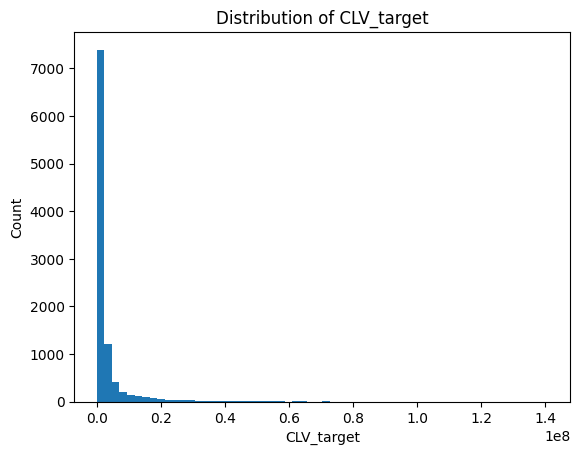

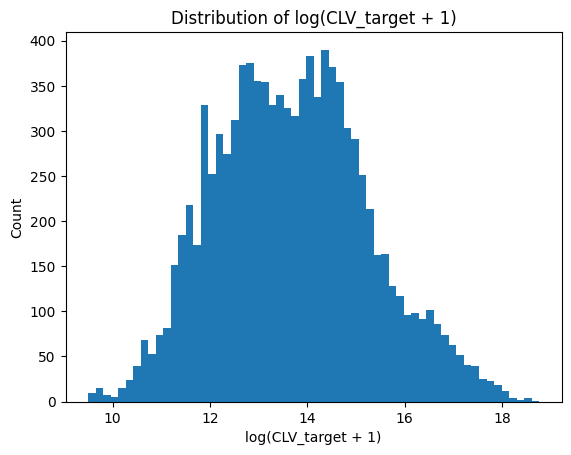

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["CLV_target"], bins=60)
plt.title("Distribution of CLV_target")
plt.xlabel("CLV_target")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist((df["CLV_target"]+1).apply(lambda x: __import__("math").log(x)), bins=60)
plt.title("Distribution of log(CLV_target + 1)")
plt.xlabel("log(CLV_target + 1)")
plt.ylabel("Count")
plt.show()


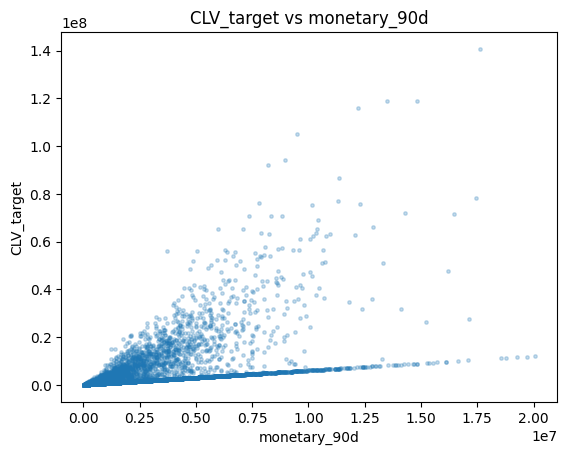

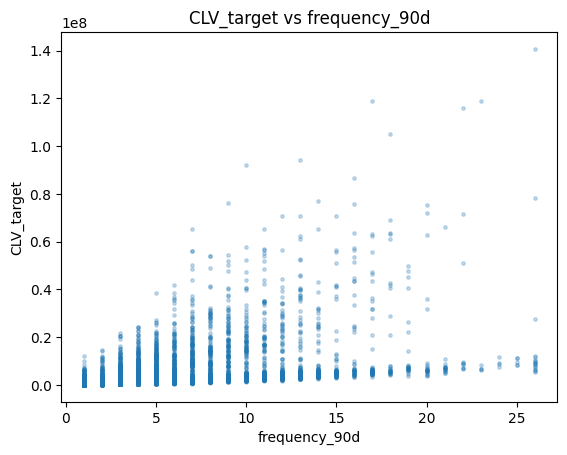

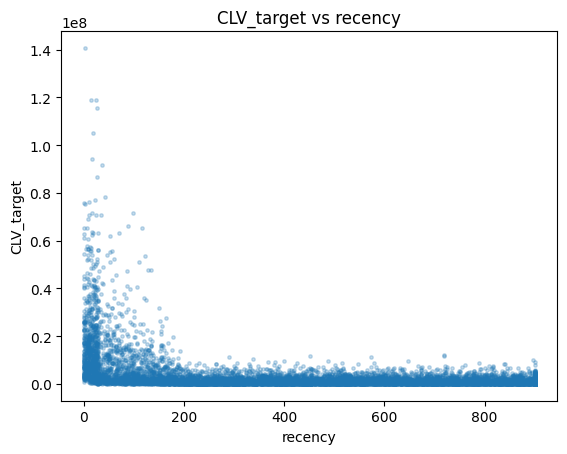

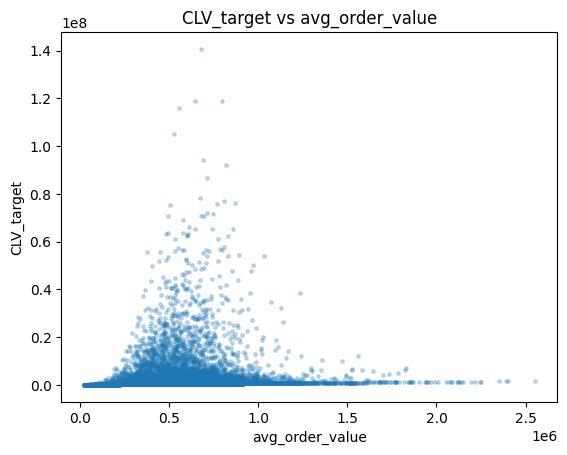

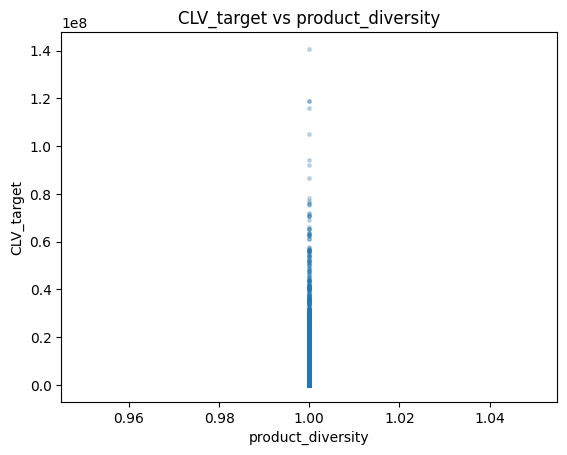

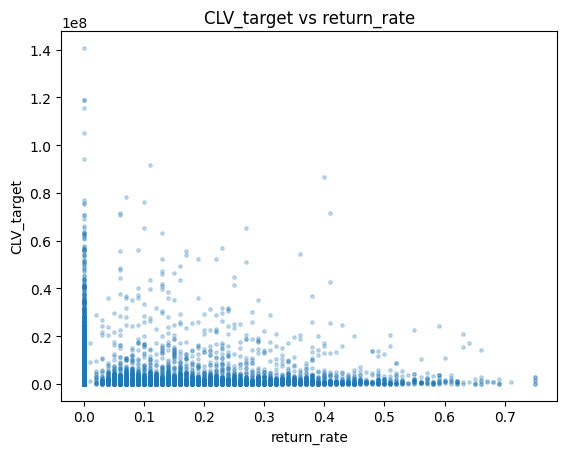

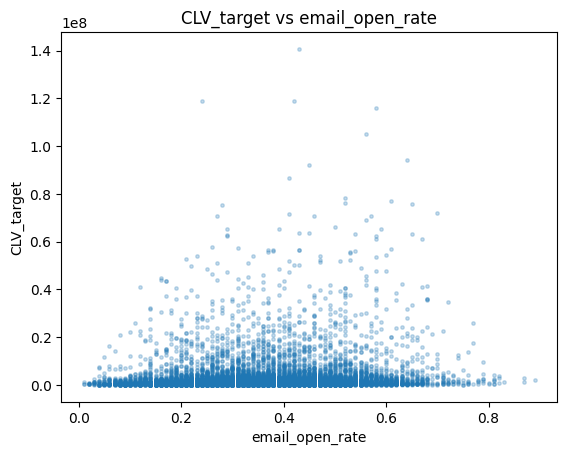

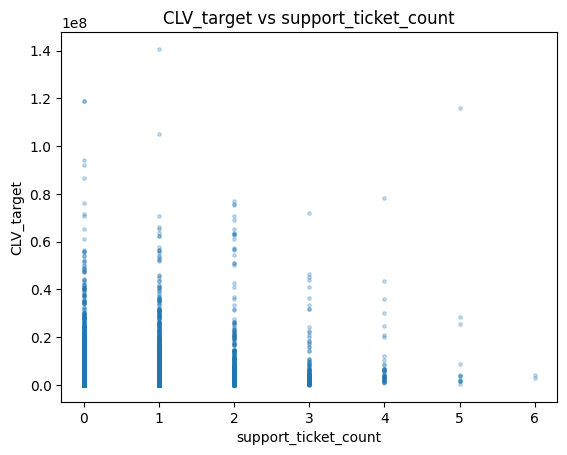

In [ ]:
import matplotlib.pyplot as plt

features = ["monetary_90d", "frequency_90d", "recency", "avg_order_value",
            "product_diversity", "return_rate", "email_open_rate", "support_ticket_count"]

for col in features:
    plt.figure()
    plt.scatter(df[col], df["CLV_target"], s=6, alpha=0.25)
    plt.title(f"CLV_target vs {col}")
    plt.xlabel(col)
    plt.ylabel("CLV_target")
    plt.show()


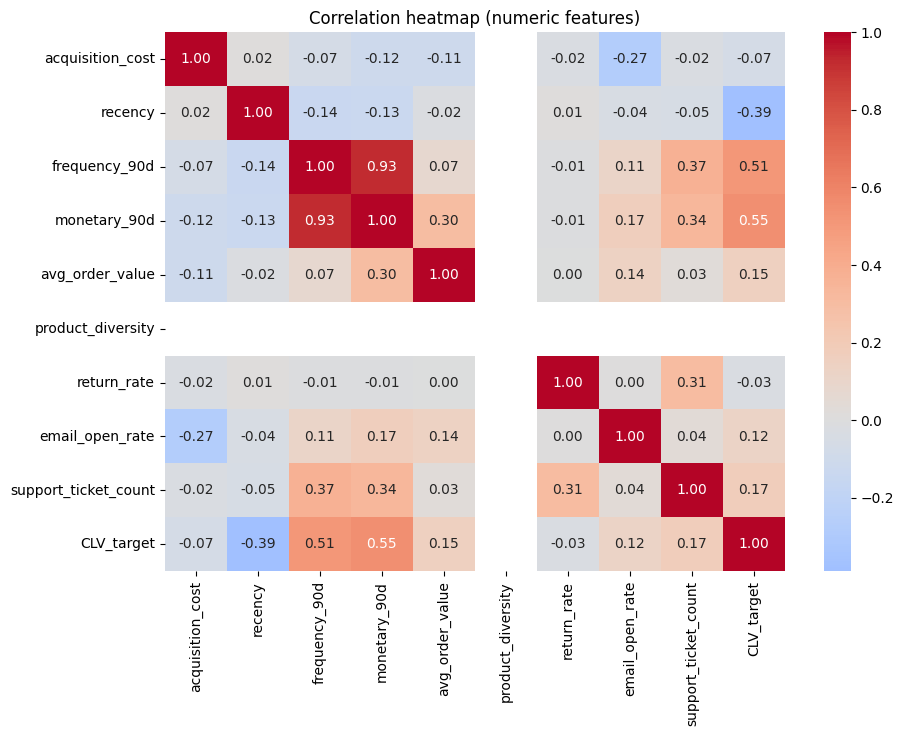

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    "acquisition_cost","recency","frequency_90d","monetary_90d","avg_order_value",
    "product_diversity","return_rate","email_open_rate","support_ticket_count","CLV_target"
]
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.show()


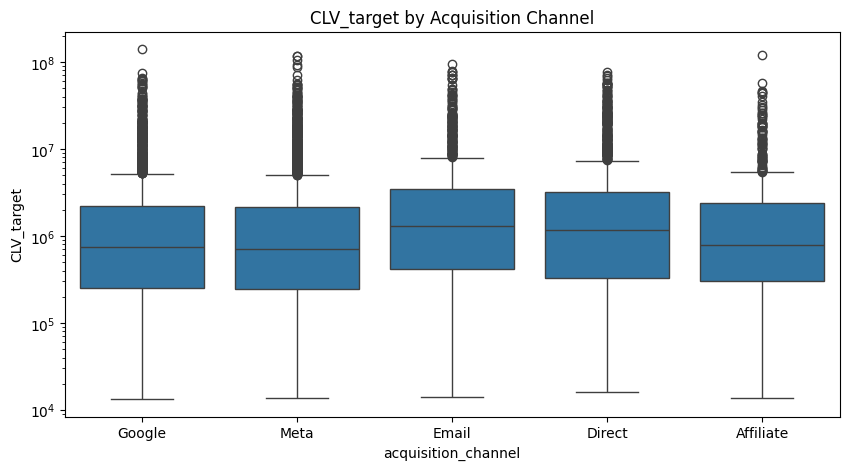

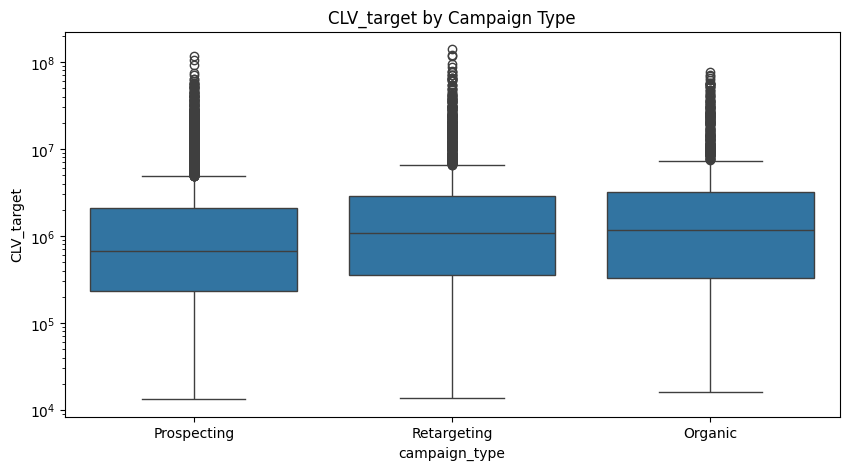

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="acquisition_channel", y="CLV_target")
plt.title("CLV_target by Acquisition Channel")
plt.yscale("log")  # vì CLV hay lệch phải
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="campaign_type", y="CLV_target")
plt.title("CLV_target by Campaign Type")
plt.yscale("log")
plt.show()


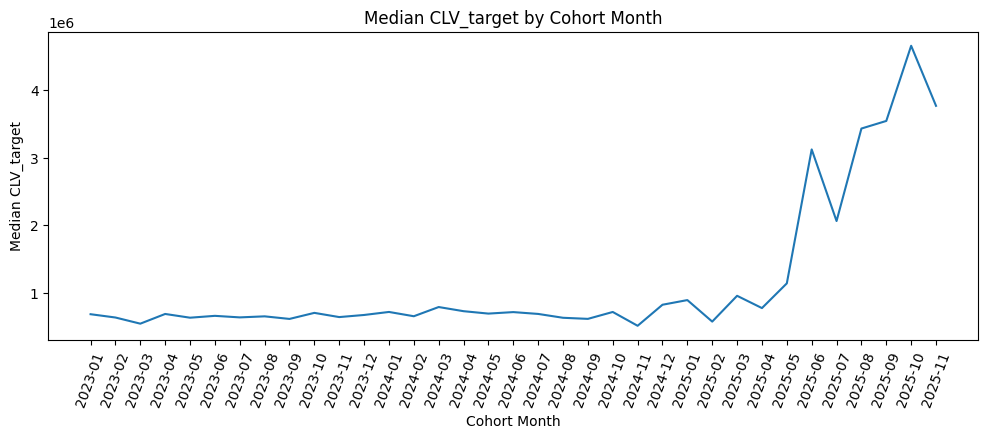

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df["first_purchase_date"] = pd.to_datetime(df["first_purchase_date"])
df["cohort_month"] = df["first_purchase_date"].dt.to_period("M").astype(str)

cohort = df.groupby("cohort_month")["CLV_target"].median().reset_index()

plt.figure(figsize=(12,4))
plt.plot(cohort["cohort_month"], cohort["CLV_target"])
plt.xticks(rotation=70)
plt.title("Median CLV_target by Cohort Month")
plt.xlabel("Cohort Month")
plt.ylabel("Median CLV_target")
plt.show()


In [ ]:
import pandas as pd
import numpy as np

cust = pd.read_csv("/content/ecommerce_clv_10k_product_based.csv")
orders = pd.read_csv("/content/orders_10k_customers.csv")
items = pd.read_csv("/content/order_items_10k_customers.csv")
prod = pd.read_csv("/content/product_data_base.csv")

# đảm bảo numeric
orders["order_value"] = pd.to_numeric(orders["order_value"], errors="coerce")
items["line_value"] = pd.to_numeric(items["line_value"], errors="coerce")
items["unit_price"] = pd.to_numeric(items["unit_price"], errors="coerce")
items["quantity"] = pd.to_numeric(items["quantity"], errors="coerce")


In [ ]:
calc = items.groupby("order_id", as_index=False)["line_value"].sum().rename(columns={"line_value":"calc_order_value"})
chk = orders.merge(calc, on="order_id", how="left")

chk["diff"] = (chk["order_value"] - chk["calc_order_value"]).abs()

print("Total orders:", len(chk))
print("Mismatched orders (diff > 0.01):", (chk["diff"] > 0.01).sum())

# show vài đơn lệch (nếu có)
chk.loc[chk["diff"] > 0.01, ["order_id","customer_id","order_value","calc_order_value","diff"]].head(20)


Total orders: 40104
Mismatched orders (diff > 0.01): 0


,order_id,customer_id,order_value,calc_order_value,diff


In [ ]:
# cố gắng tự nhận diện cột product_id trong catalog
if "product_id" in prod.columns:
    prod_ids = set(prod["product_id"].astype(str))
else:
    # fallback: dùng index như product_id
    prod_ids = set(prod.index.astype(str))

used_ids = set(items["product_id"].astype(str))

coverage = len(used_ids & prod_ids) / max(1, len(prod_ids))

print("Unique products in catalog:", len(prod_ids))
print("Unique products used in orders:", len(used_ids))
print("Used ∩ Catalog:", len(used_ids & prod_ids))
print("Coverage:", round(coverage*100, 2), "%")

# sản phẩm trong catalog nhưng chưa được mua lần nào
not_used = list(prod_ids - used_ids)
print("Not used products:", len(not_used))

not_used[:20]


Unique products in catalog: 198
Unique products used in orders: 198
Used ∩ Catalog: 198
Coverage: 100.0 %
Not used products: 0


[]

In [ ]:
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
cust["first_purchase_date"] = pd.to_datetime(cust["first_purchase_date"], errors="coerce")

# Join first_purchase_date vào orders để lọc 90 ngày đầu
o = orders.merge(cust[["customer_id","first_purchase_date"]], on="customer_id", how="left")
o["days_since_first"] = (o["order_date"] - o["first_purchase_date"]).dt.days

o90 = o[(o["days_since_first"] >= 0) & (o["days_since_first"] < 90)].copy()

agg = o90.groupby("customer_id").agg(
    frequency_90d_calc=("order_id","nunique"),
    monetary_90d_calc=("order_value","sum"),
    avg_order_value_calc=("order_value","mean")
).reset_index()

# merge với cust để so sánh
cmp = cust.merge(agg, on="customer_id", how="left")

# Fill NA (nếu khách không có order trong 90d vì data lỗi)
cmp[["frequency_90d_calc","monetary_90d_calc","avg_order_value_calc"]] = cmp[
    ["frequency_90d_calc","monetary_90d_calc","avg_order_value_calc"]
].fillna(0)

# Sai số
cmp["freq_diff"] = cmp["frequency_90d"] - cmp["frequency_90d_calc"]
cmp["monetary_diff_abs"] = (cmp["monetary_90d"] - cmp["monetary_90d_calc"]).abs()
cmp["aov_diff_abs"] = (cmp["avg_order_value"] - cmp["avg_order_value_calc"]).abs()

print("Customers:", len(cmp))
print("Freq mismatches:", (cmp["freq_diff"] != 0).sum())
print("Monetary mismatches (abs diff > 0.01):", (cmp["monetary_diff_abs"] > 0.01).sum())
print("AOV mismatches (abs diff > 0.01):", (cmp["aov_diff_abs"] > 0.01).sum())

# show các customer lệch nhiều nhất
cmp.sort_values("monetary_diff_abs", ascending=False)[
    ["customer_id","frequency_90d","frequency_90d_calc","monetary_90d","monetary_90d_calc","monetary_diff_abs",
     "avg_order_value","avg_order_value_calc","aov_diff_abs"]
].head(20)


Customers: 10000
Freq mismatches: 0
Monetary mismatches (abs diff > 0.01): 10000
AOV mismatches (abs diff > 0.01): 10000


,customer_id,frequency_90d,frequency_90d_calc,monetary_90d,monetary_90d_calc,monetary_diff_abs,avg_order_value,avg_order_value_calc,aov_diff_abs
7391,C07392,25,25,18557832.14,9545000.0,9012832.14,742313.29,381800.000000,360513.290000
6582,C06583,19,19,16181826.32,7442000.0,8739826.32,851675.07,391684.210526,459990.859474
229,C00230,13,13,13740957.48,5025000.0,8715957.48,1056996.73,386538.461538,670458.268462
4087,C04088,24,24,19251809.22,10772000.0,8479809.22,802158.72,448833.333333,353325.386667
5245,C05246,13,13,11842183.04,3448000.0,8394183.04,910937.16,265230.769231,645706.390769
1616,C01617,25,25,18799126.88,10787000.0,8012126.88,751965.08,431480.000000,320485.080000
34,C00035,19,19,13015714.64,5037000.0,7978714.64,685037.61,265105.263158,419932.346842
5069,C05070,26,26,20053919.75,12596000.0,7457919.75,771304.61,484461.538462,286843.071538
4622,C04623,26,26,19707505.91,12667000.0,7040505.91,757981.00,487192.307692,270788.692308
2909,C02910,25,25,16103178.88,9171000.0,6932178.88,644127.16,366840.000000,277287.160000


In [ ]:
# Top categories by revenue
cat_rev = items.groupby("category")["line_value"].sum().sort_values(ascending=False).head(20)
print(cat_rev)

# Top products by revenue
top_prod = items.groupby("product_id")["line_value"].sum().sort_values(ascending=False).head(20)
print(top_prod)


NameError: name 'items' is not defined

In [ ]:
!pip -q install xgboost shap

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

pd.options.display.float_format = '{:,.2f}'.format


In [ ]:
df = pd.read_csv("/content/ecommerce_clv_10k_train_clv_standardized_same_cols.csv")

df.head()


,customer_id,first_purchase_date,acquisition_channel,campaign_type,acquisition_cost,recency,frequency_90d,monetary_90d,avg_order_value,product_diversity,return_rate,email_open_rate,support_ticket_count,CLV_target,money_unit_note
0,C00001,2025-05-10,Google,Prospecting,21.49,83,2,1621862,810931,1,0.00,0.50,0,6012024,same unit as product_data_base.price_current
1,C00002,2025-11-10,Meta,Prospecting,13.73,36,1,934035,934035,1,0.00,0.25,1,1907991,same unit as product_data_base.price_current
2,C00003,2023-05-02,Meta,Prospecting,15.21,900,6,1319464,219911,1,0.00,0.24,0,791678,same unit as product_data_base.price_current
3,C00004,2024-04-11,Google,Prospecting,11.83,614,1,671726,671726,1,0.00,0.57,0,403036,same unit as product_data_base.price_current
4,C00005,2023-11-27,Email,Retargeting,2.32,663,6,1902859,317143,1,0.00,0.49,0,1141715,same unit as product_data_base.price_current


In [ ]:
target = "CLV_target"
date_col = "first_purchase_date"

# drop cột ghi chú
df = df.drop(columns=["money_unit_note"], errors="ignore")

# parse date
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df["first_purchase_year"] = df[date_col].dt.year
df["first_purchase_purchase_month"] = df[date_col].dt.month
df["first_purchase_dayofweek"] = df[date_col].dt.dayofweek


In [ ]:
money_cols = ["monetary_90d", "avg_order_value", "CLV_target"]

for c in money_cols:
    df[f"log_{c}"] = np.log1p(df[c])


In [ ]:
# Drop ID & raw date & target gốc
df_model = df.drop(columns=[
    "customer_id",
    date_col,
    target,
    "monetary_90d",
    "avg_order_value",
    "acquisition_cost"
])
X = df_model.drop(columns=["log_CLV_target"])
y = df_model["log_CLV_target"]


In [ ]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

cat_cols, num_cols


(['acquisition_channel', 'campaign_type'],
 ['recency',
  'frequency_90d',
  'product_diversity',
  'return_rate',
  'email_open_rate',
  'support_ticket_count',
  'log_monetary_90d',
  'log_avg_order_value'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Linear(Ridge)": Ridge(alpha=2.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        n_jobs=-1
    )
}


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_regression(y_true_log, y_pred_log, name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


In [ ]:
from sklearn.pipeline import Pipeline

results = []
trained = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred_log = pipe.predict(X_test)

    results.append(eval_regression(y_test, pred_log, name))
    trained[name] = pipe

res_df = pd.DataFrame(results).sort_values("RMSE")
res_df


,model,MAE,RMSE,R2
1,RandomForest,"672,733.18","2,775,097.54",0.87
2,XGBoost,"695,682.51","2,914,010.29",0.86
0,Linear(Ridge),"1,707,115.25","5,624,143.39",0.49


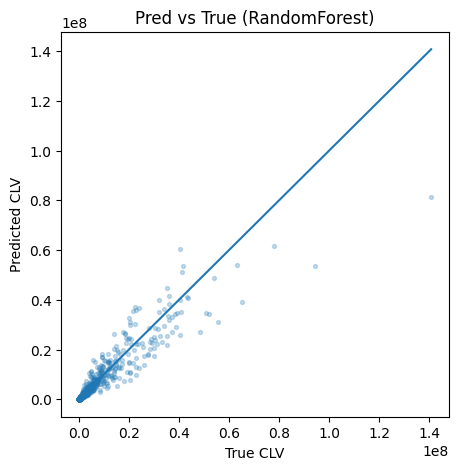

In [ ]:
best_name = res_df.iloc[0]["model"]
best_pipe = trained[best_name]

pred_log = best_pipe.predict(X_test)

plt.figure(figsize=(5,5))
plt.scatter(np.expm1(y_test), np.expm1(pred_log), s=8, alpha=0.25)
plt.plot(
    [np.expm1(y_test).min(), np.expm1(y_test).max()],
    [np.expm1(y_test).min(), np.expm1(y_test).max()]
)
plt.title(f"Pred vs True ({best_name})")
plt.xlabel("True CLV")
plt.ylabel("Predicted CLV")
plt.show()


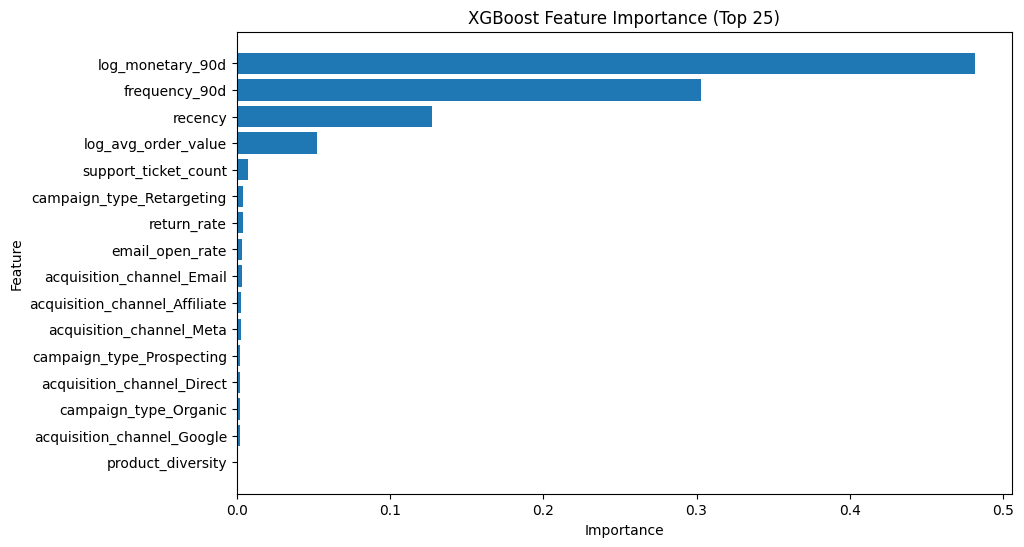

,feature,importance
6,log_monetary_90d,0.48
1,frequency_90d,0.30
0,recency,0.13
7,log_avg_order_value,0.05
5,support_ticket_count,0.01
15,campaign_type_Retargeting,0.00
3,return_rate,0.00
4,email_open_rate,0.00
10,acquisition_channel_Email,0.00
8,acquisition_channel_Affiliate,0.00


In [ ]:
xgb_pipe = trained["XGBoost"]
xgb_model = xgb_pipe.named_steps["model"]

ohe = xgb_pipe.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
feature_names = num_cols + cat_feature_names

importances = xgb_model.feature_importances_

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(25)

plt.figure(figsize=(10,6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1])
plt.title("XGBoost Feature Importance (Top 25)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

imp_df.head(10)


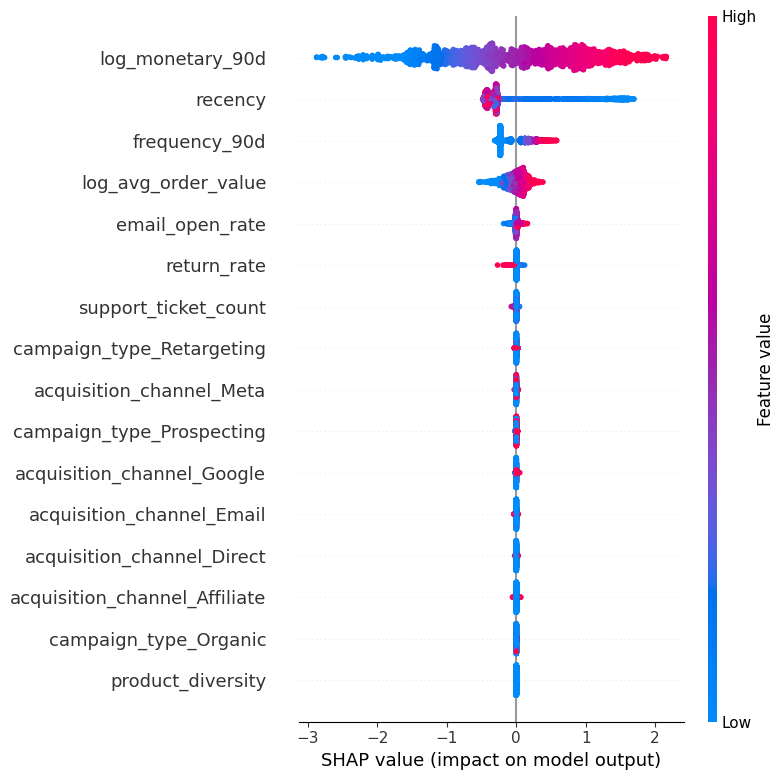

In [ ]:
X_test_trans = xgb_pipe.named_steps["prep"].transform(X_test)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_trans)

shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    show=False
)
plt.show()


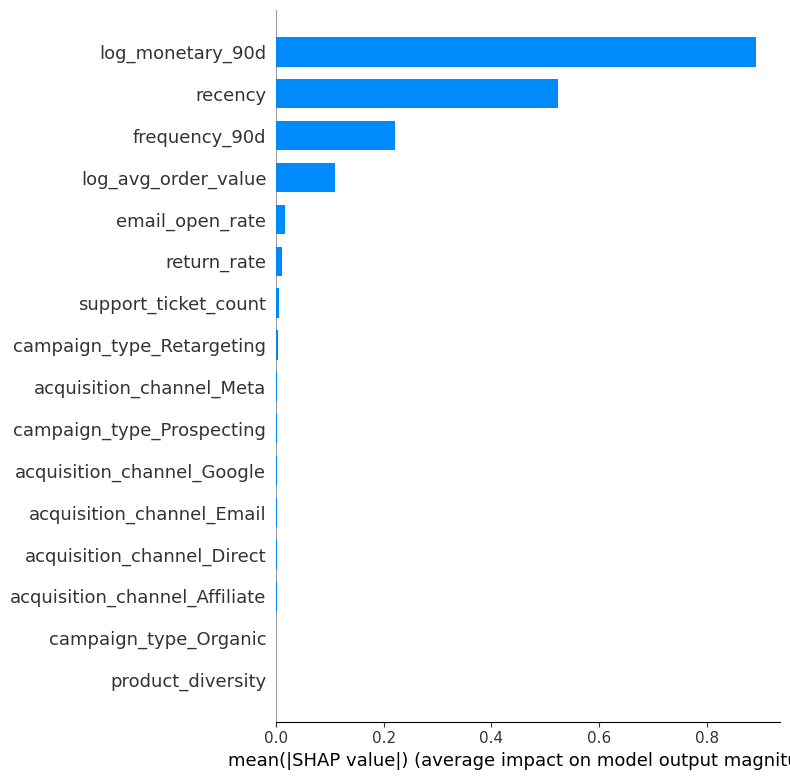

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_trans,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.show()


In [ ]:
# lấy danh sách cột pipeline đã fit
expected_cols = best_pipe.named_steps["prep"].feature_names_in_

# đảm bảo X_test có đủ và đúng thứ tự
X_test_fixed = X_test.reindex(columns=expected_cols)

y_pred_log = best_pipe.predict(X_test_fixed)

df_eval = pd.DataFrame({
    "y_true": np.expm1(y_test),
    "y_pred": np.expm1(y_pred_log)
})

k = int(0.2 * len(df_eval))
top_true = df_eval.sort_values("y_true", ascending=False).head(k)["y_true"].sum()
top_pred = df_eval.sort_values("y_pred", ascending=False).head(k)["y_true"].sum()

print("Top-20% CLV capture rate:", top_pred / top_true)


Top-20% CLV capture rate: 0.9953580376456832


In [ ]:
import joblib
import pandas as pd
import numpy as np

# best_name = res_df.iloc[0]["model"]
# best_pipe = trained[best_name]

bundle = {
    "model_name": best_name,
    "pipeline": best_pipe,
    "expected_cols": list(best_pipe.named_steps["prep"].feature_names_in_),  # schema lúc train
    "target_is_log": True
}

out_path = "/content/clv_model_bundle.joblib"
joblib.dump(bundle, out_path)

out_path


'/content/clv_model_bundle.joblib'

In [ ]:
from google.colab import files
files.download("/content/clv_model_bundle.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import pandas as pd
import numpy as np

bundle = joblib.load("/content/clv_model_bundle.joblib")  # hoặc đường dẫn local của bạn
pipe = bundle["pipeline"]
expected_cols = bundle["expected_cols"]
bundle["model_name"], len(expected_cols)


('RandomForest', 13)

In [ ]:
def predict_clv(cases: pd.DataFrame) -> pd.DataFrame:
    """
    cases: DataFrame chứa đúng các cột feature như lúc train (hoặc thiếu sẽ được fill NaN).
    Return: DataFrame gồm CLV_pred.
    """
    X_in = cases.copy()

    # đảm bảo có đủ columns và đúng thứ tự như khi train
    X_in = X_in.reindex(columns=expected_cols)

    # predict log
    pred_log = pipe.predict(X_in)

    # inverse log -> CLV
    pred = np.expm1(pred_log) if bundle.get("target_is_log", True) else pred_log

    out = cases.copy()
    out["CLV_pred"] = pred
    return out


In [ ]:
case1 = {
    "acquisition_channel": "Meta",
    "campaign_type": "Prospecting",
    "acquisition_cost": 15.5,
    "recency": 30,
    "frequency_90d": 3,
    "product_diversity": 2,
    "return_rate": 0.05,
    "email_open_rate": 0.35,
    "support_ticket_count": 0,
    "first_purchase_year": 2025,
    "first_purchase_purchase_month": 11,
    "first_purchase_dayofweek": 2,
    "log_monetary_90d": np.log1p(1200000),
    "log_avg_order_value": np.log1p(400000),
}

cases = pd.DataFrame([case1])
pred_df = predict_clv(cases)
pred_df[["CLV_pred"]]


,CLV_pred
0,"4,463,519.36"


In [ ]:
template = pd.DataFrame([{c: np.nan for c in expected_cols}])
template


,acquisition_channel,campaign_type,recency,frequency_90d,product_diversity,return_rate,email_open_rate,support_ticket_count,first_purchase_year,first_purchase_purchase_month,first_purchase_dayofweek,log_monetary_90d,log_avg_order_value
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
pred_df = predict_clv(cases)

# format cho dễ nhìn
pred_df["CLV_pred_fmt"] = pred_df["CLV_pred"].map(lambda x: f"{x:,.0f}")
pred_df[["CLV_pred", "CLV_pred_fmt"]]


,CLV_pred,CLV_pred_fmt
0,"4,463,519.36","4,463,519"


In [ ]:
import numpy as np
import pandas as pd

test_cases = [
    # 1) Very inactive / gần như mất (recency cao, chi thấp)
    {
        "case_id": "A_very_inactive_low_spend",
        "acquisition_channel": "Meta",
        "campaign_type": "Prospecting",
        "acquisition_cost": 0.0,
        "recency": 240,
        "frequency_90d": 0,
        "product_diversity": 1,
        "return_rate": 0.00,
        "email_open_rate": 0.05,
        "support_ticket_count": 0,
        "first_purchase_year": 2023,
        "first_purchase_purchase_month": 6,
        "first_purchase_dayofweek": 3,
        "log_monetary_90d": np.log1p(0),
        "log_avg_order_value": np.log1p(0),
    },

    # 2) Dormant nhưng vẫn có chút chi trong 90d (mua ít, recency vừa cao)
    {
        "case_id": "B_dormant_some_spend",
        "acquisition_channel": "Google",
        "campaign_type": "Prospecting",
        "acquisition_cost": 0.0,
        "recency": 120,
        "frequency_90d": 1,
        "product_diversity": 1,
        "return_rate": 0.00,
        "email_open_rate": 0.10,
        "support_ticket_count": 0,
        "first_purchase_year": 2024,
        "first_purchase_purchase_month": 2,
        "first_purchase_dayofweek": 5,
        "log_monetary_90d": np.log1p(250_000),
        "log_avg_order_value": np.log1p(250_000),
    },

    # 3) New customer - 1 đơn gần đây, AOV trung bình
    {
        "case_id": "C_new_single_order_recent",
        "acquisition_channel": "Meta",
        "campaign_type": "Prospecting",
        "acquisition_cost": 0.0,
        "recency": 10,
        "frequency_90d": 1,
        "product_diversity": 1,
        "return_rate": 0.00,
        "email_open_rate": 0.20,
        "support_ticket_count": 0,
        "first_purchase_year": 2025,
        "first_purchase_purchase_month": 11,
        "first_purchase_dayofweek": 2,
        "log_monetary_90d": np.log1p(350_000),
        "log_avg_order_value": np.log1p(350_000),
    },

    # 4) Active moderate - giống case bạn nhưng spend thấp hơn
    {
        "case_id": "D_active_moderate",
        "acquisition_channel": "Meta",
        "campaign_type": "Prospecting",
        "acquisition_cost": 0.0,
        "recency": 25,
        "frequency_90d": 3,
        "product_diversity": 2,
        "return_rate": 0.03,
        "email_open_rate": 0.30,
        "support_ticket_count": 0,
        "first_purchase_year": 2025,
        "first_purchase_purchase_month": 9,
        "first_purchase_dayofweek": 4,
        "log_monetary_90d": np.log1p(900_000),
        "log_avg_order_value": np.log1p(300_000),
    },

    # 5) Active strong - recency rất tốt, frequency cao, monetary cao
    {
        "case_id": "E_active_strong",
        "acquisition_channel": "Google",
        "campaign_type": "Retargeting",
        "acquisition_cost": 0.0,
        "recency": 7,
        "frequency_90d": 6,
        "product_diversity": 4,
        "return_rate": 0.02,
        "email_open_rate": 0.45,
        "support_ticket_count": 0,
        "first_purchase_year": 2024,
        "first_purchase_purchase_month": 12,
        "first_purchase_dayofweek": 6,
        "log_monetary_90d": np.log1p(3_000_000),
        "log_avg_order_value": np.log1p(500_000),
    },

    # 6) High-value loyal - monetary rất cao, frequency cao, recency thấp
    {
        "case_id": "F_high_value_loyal",
        "acquisition_channel": "Direct",
        "campaign_type": "Organic",
        "acquisition_cost": 0.0,
        "recency": 3,
        "frequency_90d": 10,
        "product_diversity": 6,
        "return_rate": 0.01,
        "email_open_rate": 0.55,
        "support_ticket_count": 0,
        "first_purchase_year": 2022,
        "first_purchase_purchase_month": 8,
        "first_purchase_dayofweek": 1,
        "log_monetary_90d": np.log1p(8_000_000),
        "log_avg_order_value": np.log1p(800_000),
    },

    # 7) “Unhappy” - active nhưng return cao, support tickets nhiều
    {
        "case_id": "G_active_unhappy_high_returns",
        "acquisition_channel": "Meta",
        "campaign_type": "Retargeting",
        "acquisition_cost": 0.0,
        "recency": 12,
        "frequency_90d": 5,
        "product_diversity": 3,
        "return_rate": 0.25,
        "email_open_rate": 0.25,
        "support_ticket_count": 4,
        "first_purchase_year": 2024,
        "first_purchase_purchase_month": 5,
        "first_purchase_dayofweek": 2,
        "log_monetary_90d": np.log1p(2_500_000),
        "log_avg_order_value": np.log1p(450_000),
    },

    # 8) Edge-case: monetary cao nhưng recency xấu (đã từng mua nhiều, giờ lâu không quay lại)
    {
        "case_id": "H_high_spend_but_old_recency",
        "acquisition_channel": "Google",
        "campaign_type": "Prospecting",
        "acquisition_cost": 0.0,
        "recency": 180,
        "frequency_90d": 1,
        "product_diversity": 2,
        "return_rate": 0.02,
        "email_open_rate": 0.10,
        "support_ticket_count": 1,
        "first_purchase_year": 2021,
        "first_purchase_purchase_month": 3,
        "first_purchase_dayofweek": 0,
        "log_monetary_90d": np.log1p(2_000_000),
        "log_avg_order_value": np.log1p(2_000_000),
    },

    # 9) Edge-case: frequency cao nhưng monetary thấp (nhiều đơn nhỏ)
    {
        "case_id": "I_many_small_orders",
        "acquisition_channel": "Email",
        "campaign_type": "Retargeting",
        "acquisition_cost": 0.0,
        "recency": 14,
        "frequency_90d": 9,
        "product_diversity": 5,
        "return_rate": 0.03,
        "email_open_rate": 0.60,
        "support_ticket_count": 0,
        "first_purchase_year": 2024,
        "first_purchase_purchase_month": 10,
        "first_purchase_dayofweek": 3,
        "log_monetary_90d": np.log1p(1_200_000),
        "log_avg_order_value": np.log1p(120_000),
    },

    # 10) Baseline giống case1 của bạn (để đối chiếu)
    {
        "case_id": "J_baseline_like_case1",
        "acquisition_channel": "Meta",
        "campaign_type": "Prospecting",
        "acquisition_cost": 0.0,
        "recency": 30,
        "frequency_90d": 3,
        "product_diversity": 2,
        "return_rate": 0.05,
        "email_open_rate": 0.35,
        "support_ticket_count": 0,
        "first_purchase_year": 2025,
        "first_purchase_purchase_month": 11,
        "first_purchase_dayofweek": 2,
        "log_monetary_90d": np.log1p(1_200_000),
        "log_avg_order_value": np.log1p(400_000),
    },
]

cases = pd.DataFrame(test_cases)

pred_df = predict_clv(cases)

# Xem nhanh theo case_id
pred_df[["case_id", "CLV_pred"]].sort_values("CLV_pred", ascending=False)


,case_id,CLV_pred
5,F_high_value_loyal,"60,368,423.30"
4,E_active_strong,"12,418,622.66"
6,G_active_unhappy_high_returns,"8,673,791.99"
8,I_many_small_orders,"5,321,825.39"
9,J_baseline_like_case1,"4,463,519.36"
3,D_active_moderate,"3,089,577.45"
7,H_high_spend_but_old_recency,"1,751,707.65"
2,C_new_single_order_recent,"988,261.79"
1,B_dormant_some_spend,"426,950.96"
0,A_very_inactive_low_spend,"13,815.82"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

def eval_regression(y_true_log, y_pred_log, name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def train_clv_for_horizon(csv_path: str, horizon_tag: str):
    # ============ LOAD ============
    df = pd.read_csv(csv_path)

    target = "CLV_target"
    date_col = "first_purchase_date"

    # drop note column (nếu có)
    df = df.drop(columns=["money_unit_note"], errors="ignore")

    # parse date + derive date parts (giống pipeline 12m)
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["first_purchase_year"] = df[date_col].dt.year
    df["first_purchase_purchase_month"] = df[date_col].dt.month
    df["first_purchase_dayofweek"] = df[date_col].dt.dayofweek

    # log money features + log target (giống bạn)
    money_cols = ["monetary_90d", "avg_order_value", "CLV_target"]
    for c in money_cols:
        if c in df.columns:
            df[f"log_{c}"] = np.log1p(df[c])

    # ============ BUILD X, y ============
    # Giữ nguyên đúng logic bạn đang dùng:
    df_model = df.drop(columns=[
        "customer_id",
        date_col,
        target,
        "monetary_90d",
        "avg_order_value",
        "acquisition_cost"
    ], errors="ignore")

    # X = tất cả trừ log target; y = log target
    if "log_CLV_target" not in df_model.columns:
        raise ValueError("Không thấy cột log_CLV_target. Hãy kiểm tra dữ liệu có CLV_target hay không.")

    X = df_model.drop(columns=["log_CLV_target"])
    y = df_model["log_CLV_target"]

    # columns
    cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
    num_cols = X.select_dtypes(include=["int64","float64","int32","float32"]).columns.tolist()

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # preprocess
    preprocess = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    )

    # models (giữ nguyên config của bạn)
    models = {
        "Linear(Ridge)": Ridge(alpha=2.0),
        "RandomForest": RandomForestRegressor(
            n_estimators=400,
            random_state=42,
            n_jobs=-1
        ),
        "XGBoost": XGBRegressor(
            n_estimators=800,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=42,
            n_jobs=-1
        )
    }

    # train + eval
    results = []
    trained = {}

    for name, model in models.items():
        pipe = Pipeline([
            ("prep", preprocess),
            ("model", model)
        ])
        pipe.fit(X_train, y_train)
        pred_log = pipe.predict(X_test)

        results.append(eval_regression(y_test, pred_log, name))
        trained[name] = pipe

    res_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

    best_name = res_df.iloc[0]["model"]
    best_pipe = trained[best_name]

    # bundle output (thêm horizon cho rõ)
    bundle = {
        "model_name": best_name,
        "pipeline": best_pipe,
        "expected_cols": list(best_pipe.named_steps["prep"].feature_names_in_),
        "target_is_log": True,
        "horizon": horizon_tag
    }

    out_path = f"/content/clv_model_bundle_{horizon_tag}.joblib"
    joblib.dump(bundle, out_path)

    return res_df, out_path


In [ ]:
res_1m, path_1m = train_clv_for_horizon("/content/ecommerce_clv_train_1m.csv", "1m")
res_3m, path_3m = train_clv_for_horizon("/content/ecommerce_clv_train_3m.csv", "3m")
res_6m, path_6m = train_clv_for_horizon("/content/ecommerce_clv_train_6m.csv", "6m")

print("1m bundle:", path_1m); display(res_1m)
print("3m bundle:", path_3m); display(res_3m)
print("6m bundle:", path_6m); display(res_6m)


1m bundle: /content/clv_model_bundle_1m.joblib


,model,MAE,RMSE,R2
0,RandomForest,"59,109.68","291,808.44",0.85
1,XGBoost,"59,997.72","308,200.28",0.84
2,Linear(Ridge),"113,423.64","551,534.01",0.48


3m bundle: /content/clv_model_bundle_3m.joblib


,model,MAE,RMSE,R2
0,RandomForest,"178,558.49","797,291.60",0.87
1,XGBoost,"177,160.09","799,388.21",0.87
2,Linear(Ridge),"343,997.73","1,586,206.56",0.50


6m bundle: /content/clv_model_bundle_6m.joblib


,model,MAE,RMSE,R2
0,RandomForest,"376,311.75","1,857,453.30",0.85
1,XGBoost,"375,257.20","1,894,149.22",0.85
2,Linear(Ridge),"758,994.23","3,420,451.28",0.50


In [ ]:
from google.colab import files
files.download(path_1m)
files.download(path_3m)
files.download(path_6m)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
import numpy as np
import pandas as pd

def load_bundle(path):
    b = joblib.load(path)
    return b, b["pipeline"], b["expected_cols"]

def predict_clv_with_bundle(cases: pd.DataFrame, bundle: dict) -> pd.DataFrame:
    pipe = bundle["pipeline"]
    expected_cols = bundle["expected_cols"]

    X_in = cases.copy().reindex(columns=expected_cols)
    pred_log = pipe.predict(X_in)
    pred = np.expm1(pred_log) if bundle.get("target_is_log", True) else pred_log

    out = cases.copy()
    out[f"CLV_pred_{bundle.get('horizon','')}".strip("_")] = pred
    return out


In [ ]:
case1 = {
    "acquisition_channel": "Meta",
    "campaign_type": "Prospecting",
    "acquisition_cost": 15.5,
    "recency": 30,
    "frequency_90d": 3,
    "product_diversity": 2,
    "return_rate": 0.05,
    "email_open_rate": 0.35,
    "support_ticket_count": 0,
    "first_purchase_year": 2025,
    "first_purchase_purchase_month": 11,
    "first_purchase_dayofweek": 2,
    "log_monetary_90d": np.log1p(1200000),
    "log_avg_order_value": np.log1p(400000),
}
cases = pd.DataFrame([case1])

b1 = joblib.load("/content/clv_model_bundle_1m.joblib")
b3 = joblib.load("/content/clv_model_bundle_3m.joblib")
b6 = joblib.load("/content/clv_model_bundle_6m.joblib")

out = predict_clv_with_bundle(cases, b1)
out = predict_clv_with_bundle(out, b3)
out = predict_clv_with_bundle(out, b6)

out[[c for c in out.columns if c.startswith("CLV_pred")]]


,CLV_pred_1m,CLV_pred_3m,CLV_pred_6m
0,"302,001.07","846,962.75","2,072,512.96"


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dữ liệu
orders = pd.read_csv('/content/orders_10k_customers.csv')
order_items = pd.read_csv('/content/order_items_10k_customers.csv')
products = pd.read_csv('/content/product_data_base_with_catalog.csv')

# Merge orders + order_items
df = orders.merge(order_items, on='order_id')
df = df.rename(columns={'customer_id_x': 'customer_id'})
df = df.merge(products, on='product_id', how='left')
df.columns
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/orders_10k_customers.csv'

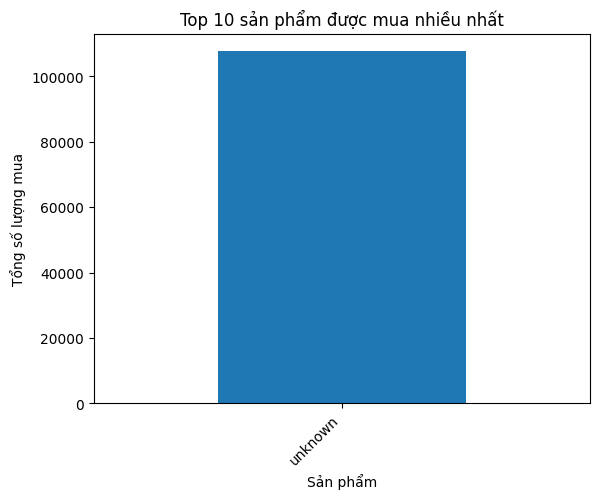

In [ ]:
product_counts = (
    df.groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
)
plt.figure()
product_counts.head(10).plot(kind='bar')
plt.title('Top 10 sản phẩm được mua nhiều nhất')
plt.xlabel('Sản phẩm')
plt.ylabel('Tổng số lượng mua')
plt.xticks(rotation=45, ha='right')
plt.show()


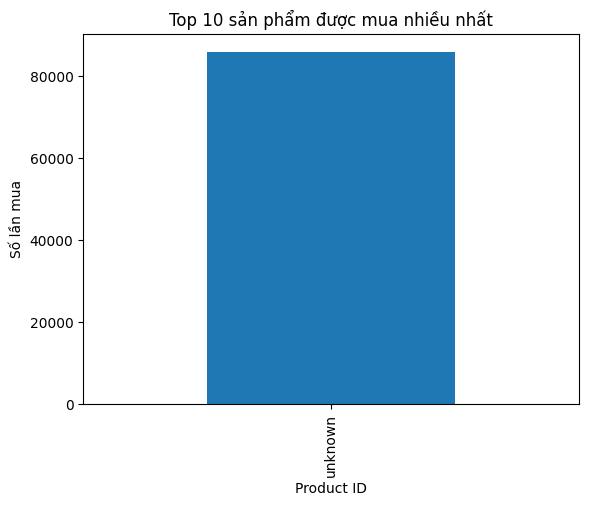

KeyError: 'customer_id'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dữ liệu
orders = pd.read_csv('/content/orders_10k_customers.csv')
order_items = pd.read_csv('/content/order_items_10k_customers.csv')

# Merge 2 bảng theo order_id
df = orders.merge(order_items, on='order_id')

# ---------------------------
# 1. Số lần mỗi sản phẩm được mua
# ---------------------------
product_counts = df['product_id'].value_counts()

plt.figure()
product_counts.head(10).plot(kind='bar')
plt.title('Top 10 sản phẩm được mua nhiều nhất')
plt.xlabel('Product ID')
plt.ylabel('Số lần mua')
plt.show()

# ---------------------------
# 2. Phân phối số lượng sản phẩm mỗi khách hàng mua
# ---------------------------
customer_quantity = df.groupby('customer_id')['quantity'].sum()

plt.figure()
customer_quantity.plot(kind='hist', bins=30)
plt.title('Phân phối số lượng sản phẩm khách hàng mua')
plt.xlabel('Tổng số lượng sản phẩm')
plt.ylabel('Số khách hàng')
plt.show()

# ---------------------------
# 3. Top khách hàng mua nhiều nhất
# ---------------------------
top_customer = customer_quantity.sort_values(ascending=False).head(10)

plt.figure()
top_customer.plot(kind='bar')
plt.title('Top 10 khách hàng mua nhiều nhất')
plt.xlabel('Customer ID')
plt.ylabel('Tổng số lượng mua')
plt.show()

top_customer


In [ ]:
df = (
    pd.read_csv('orders_10k_customers_FIXED.csv')
    .merge(
        pd.read_csv('order_items_10k_customers_FIXED.csv'),
        on='order_id'
    )
    .merge(
        pd.read_csv('product_data_base_with_catalog.csv'),
        on='product_id'
    )
)

df.head()


,order_id,customer_id_x,order_date,order_value,num_items,customer_id_y,product_id,product_name,category_x,unit_price,...,rating,reviews_count,monthly_sales,sell_progress,inventory_qty,status,status_updated_at,created_at,updated_at,catalog
0,O0000001,C00001,2025-05-27,1105000,4,C00001,5c442dc1-c667-4a22-b063-51f417fff385,unknown,Chưa rõ,99000,...,5,0,Chưa có,Chưa có,200,AVAILABLE,2025-12-08 04:40:56.949+00,2025-12-08 04:40:56.945+00,2025-12-08 04:40:56.945+00,Other
1,O0000001,C00001,2025-05-27,1105000,4,C00001,4a173292-8cfc-4783-840f-c07db06f39ae,unknown,Chưa rõ,625000,...,5,0,Chưa có,Chưa có,249,AVAILABLE,2025-12-08 04:40:56.974+00,2025-12-08 04:40:56.945+00,2025-12-08 04:40:56.945+00,Other
2,O0000001,C00001,2025-05-27,1105000,4,C00001,d05d6e4c-26c1-4d70-bd5e-c54c228d426d,unknown,Chưa rõ,132000,...,5,0,Chưa có,Chưa có,67,AVAILABLE,2025-12-08 04:40:56.972+00,2025-12-08 04:40:56.945+00,2025-12-08 04:40:56.945+00,Other
3,O0000001,C00001,2025-05-27,1105000,4,C00001,abb0c850-3fc1-4f03-acd3-ce8a38d26e69,unknown,Chưa rõ,249000,...,5,0,Chưa có,Chưa có,148,AVAILABLE,2025-12-08 04:40:56.968+00,2025-12-08 04:40:56.945+00,2025-12-08 04:40:56.945+00,Other
4,O0000002,C00001,2025-07-15,864000,2,C00001,fb1c1b39-78d0-4930-92a1-e65e72e6460f,unknown,Chưa rõ,129000,...,5,0,Chưa có,Chưa có,37,AVAILABLE,2025-12-08 04:40:56.967+00,2025-12-08 04:40:56.945+00,2025-12-08 04:40:56.945+00,Other


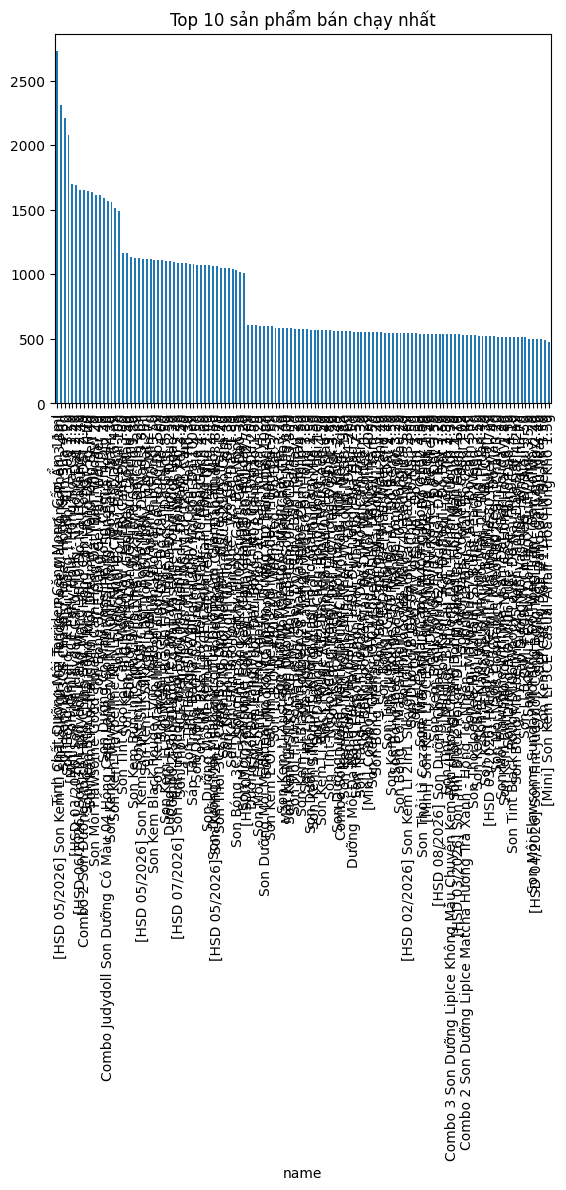

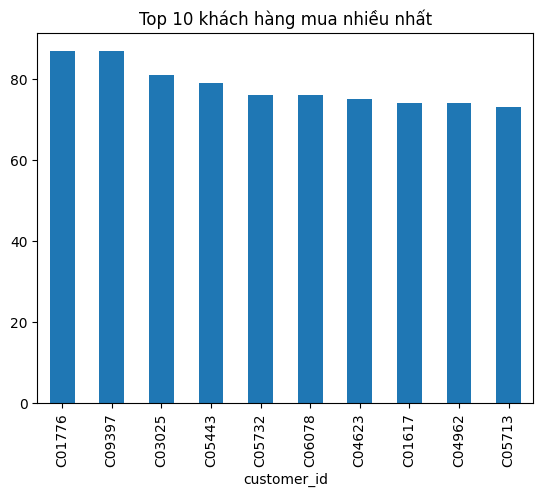

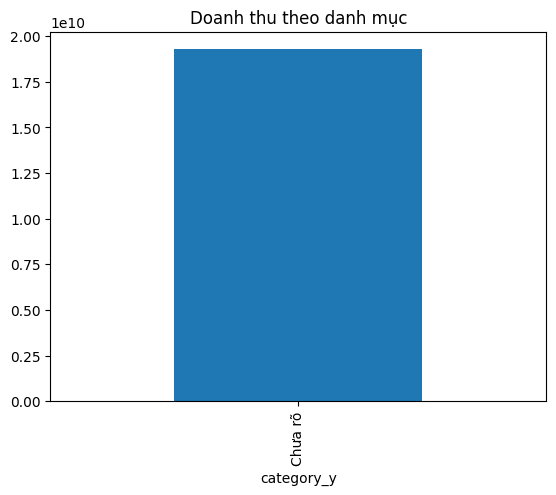

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv('orders_10k_customers_FIXED.csv')
order_items = pd.read_csv('order_items_10k_customers_FIXED.csv')
products = pd.read_csv('product_data_base_with_catalog.csv')

df = (
    orders
    .merge(order_items, on=['order_id', 'customer_id'])
    .merge(products, on='product_id', how='left')
)

# Top sản phẩm
df.groupby('name')['quantity'].sum().sort_values(ascending=False).head(200).plot(kind='bar')
plt.title('Top 10 sản phẩm bán chạy nhất')
plt.show()

# Top khách hàng
df.groupby('customer_id')['quantity'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 khách hàng mua nhiều nhất')
plt.show()

# Doanh thu theo danh mục
df.groupby('category_y')['line_value'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title('Doanh thu theo danh mục')
plt.show()
# ===============================
# Tổng số lượng bán theo sản phẩm
# ===============================
product_sales = (
    df.groupby('name')['quantity']
    .sum()
    .sort_values(ascending=False)
)

# Lấy 200 sản phẩm
top_200_products = product_sales.head(200)

# Xem dạng bảng
top_200_products.head(200)
top_200_products.reset_index().rename(
    columns={'name': 'product_name', 'quantity': 'total_quantity_sold'}
).to_csv('/content/top_200_products_sales.csv', index=False)


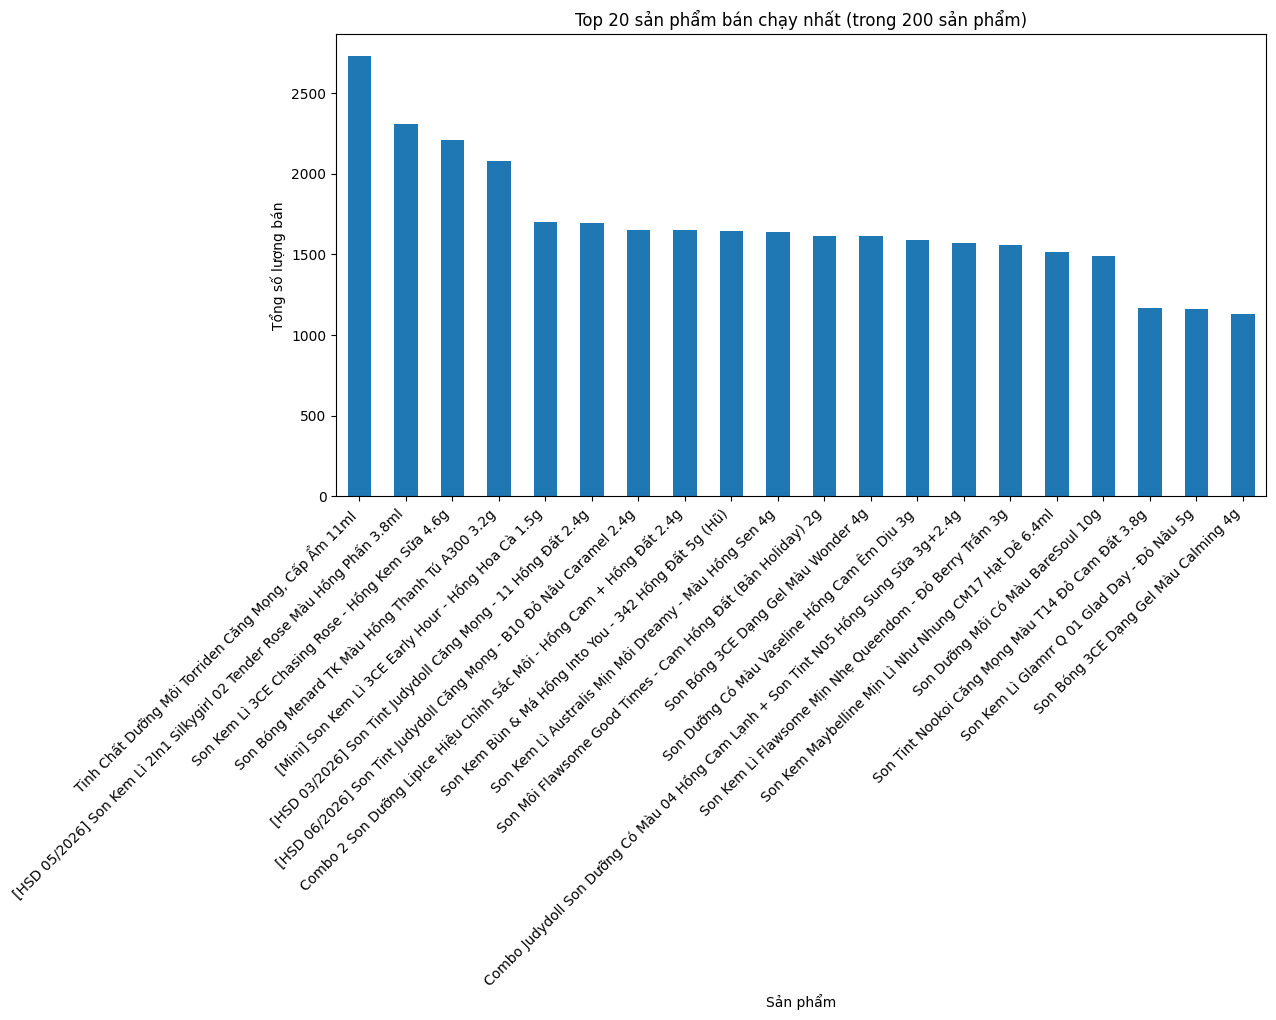

In [ ]:
plt.figure(figsize=(12,6))
top_200_products.head(20).plot(kind='bar')
plt.title('Top 20 sản phẩm bán chạy nhất (trong 200 sản phẩm)')
plt.xlabel('Sản phẩm')
plt.ylabel('Tổng số lượng bán')
plt.xticks(rotation=45, ha='right')
plt.show()


In [ ]:
plt.figure(figsize=(8,5))
top_200_products.plot(kind='hist', bins=30)
plt.title('Phân phối số lượng bán của 200 sản phẩm')
plt.xlabel('Tổng số lượng bán')
plt.ylabel('Số sản phẩm')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# Load dữ liệu
# =====================
orders = pd.read_csv('/content/orders_10k_customers.csv')
order_items = pd.read_csv('/content/order_items_10k_customers.csv')
products = pd.read_csv('/content/product_data_base_with_catalog.csv')
clv = pd.read_csv('/content/ecommerce_clv_10k_product_based.csv')

# =====================
# Merge orders + order_items
# =====================
df = orders.merge(order_items, on='order_id')

# Fix customer_id bị _x _y
df = df.rename(columns={'customer_id_x': 'customer_id'})

# =====================
# Merge thêm product catalog
# =====================
df = df.merge(products, on='product_id', how='left')

# =====================
# 🔥 MERGE THÊM CLV theo customer_id
# =====================
df = df.merge(clv, on='customer_id', how='left')

# =====================
# Kiểm tra kết quả
# =====================
df.columns
df.head()
# =====================
# Xuất file CSV sau khi merge
# =====================
output_path = '/content/ecommerce_merged_full_dataset.csv'
df.to_csv(output_path, index=False)

print(f"Đã xuất file: {output_path}")


Đã xuất file: /content/ecommerce_merged_full_dataset.csv


In [ ]:
!pip install -q numpy==1.26.4 joblib==1.4.2 scikit-learn==1.6.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

import joblib


In [ ]:
  from google.colab import files
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
print(df.shape)
df.head()

Saving churn_dataset_15k_noleak_60_40.csv to churn_dataset_15k_noleak_60_40 (1).csv
(15000, 35)


,customer_id,snapshot_date,skin_type,preferred_category,primary_purchase_channel,device_type,traffic_source,price_sensitivity_score,customer_tenure_days,promotion_period_flag,...,email_open_rate_30d,push_open_rate_30d,coupon_used_90d,returns_90d,refund_ratio_90d,complaints_90d,avg_rating_90d,engagement_score_30d,experience_risk_score,will_churn_90d
0,C01229,2025-07-12,sensitive,skincare,marketplace,desktop,email,0.169,963,0,...,0.536,0.301,1,0,0.0,0,4.3,10.27,0.0,0
1,C03921,2025-02-17,sensitive,fragrance,store,tablet,google_ads,0.225,778,0,...,0.591,0.337,0,0,0.0,0,3.5,11.26,0.0,0
2,C01529,2025-05-06,dry,haircare,social,desktop,organic,0.289,611,1,...,0.153,0.217,0,0,0.0,0,4.1,4.21,0.0,1
3,C00440,2025-03-31,combination,haircare,online,mobile,email,0.196,1100,0,...,0.301,0.334,0,0,0.0,0,4.6,8.97,0.0,1
4,C00029,2025-06-05,normal,skincare,online,desktop,organic,0.163,857,1,...,0.429,0.498,0,1,0.5,0,4.6,9.98,0.3,0


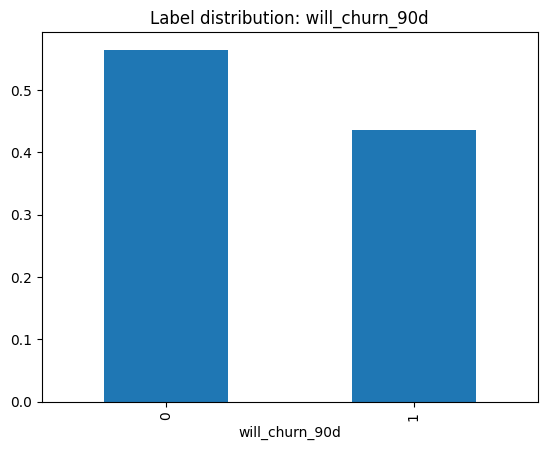

2025-01-01 00:00:00 → 2025-12-31 00:00:00


In [ ]:
# Label distribution
df["will_churn_90d"].value_counts(normalize=True).plot(kind="bar")
plt.title("Label distribution: will_churn_90d")
plt.show()

# Check time range
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
print(df["snapshot_date"].min(), "→", df["snapshot_date"].max())


In [ ]:
# Sort by time
df = df.sort_values("snapshot_date")

# 80% train (quá khứ), 20% test (tương lai)
split_date = df["snapshot_date"].quantile(0.8)

train_df = df[df["snapshot_date"] <= split_date]
test_df  = df[df["snapshot_date"] > split_date]

print("Train:", train_df.shape)
print("Test :", test_df.shape)


Train: (12028, 35)
Test : (2972, 35)


In [ ]:
TARGET = "will_churn_90d"
DROP_COLS = ["customer_id", "snapshot_date"]

X_train = train_df.drop(columns=[TARGET] + DROP_COLS)
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET] + DROP_COLS)
y_test = test_df[TARGET]

num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", len(num_features))
print("Categorical:", len(cat_features))


Numeric: 27
Categorical: 5


In [ ]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])


In [ ]:
logit_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

logit_model.fit(X_train, y_train)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['price_sensitivity_score',
                                                   'customer_tenure_days',
                                                   'promotion_period_flag',
                                                   'orders_30d', 'orders_90d',
                                                   'spend_30d', 'spend_90d',
                                                   'avg_order_value_90d',
                                                   'sessions_30d',
                                                   'product_views_30d',
                                                   'add_to_cart_30...
                                                   'complaints_90d',
                                                   'avg_rating_90d',
                                                   'engagement_score_30d',
                                                   'experience_risk_score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['skin_type',
                                                   'preferred_category',
                                                   'primary_purchase_channel',
                                                   'device_type',
                                                   'traffic_source'])])),
                ('clf', LogisticRegression(max_iter=2000))])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1) Define models (theo paper)
logit_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=3000))
])

knn_model = Pipeline([
    ("prep", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=25, weights="distance"))
])

rf_model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

gb_model = Pipeline([
    ("prep", preprocess),
    ("clf", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

# 2) Train all
trained_models = {
    "Logistic": logit_model,
    "KNN": knn_model,
    "RandomForest": rf_model,
    "GradientBoosting": gb_model
}

for name, model in trained_models.items():
    model.fit(X_train, y_train)
    print(f"✅ Trained: {name}")


✅ Trained: Logistic
✅ Trained: KNN
✅ Trained: RandomForest
✅ Trained: GradientBoosting



===== Logistic =====
AUC: 0.645
              precision    recall  f1-score   support

           0       0.63      0.75      0.68      1656
           1       0.58      0.44      0.50      1316

    accuracy                           0.61      2972
   macro avg       0.60      0.59      0.59      2972
weighted avg       0.61      0.61      0.60      2972



<Figure size 640x480 with 0 Axes>

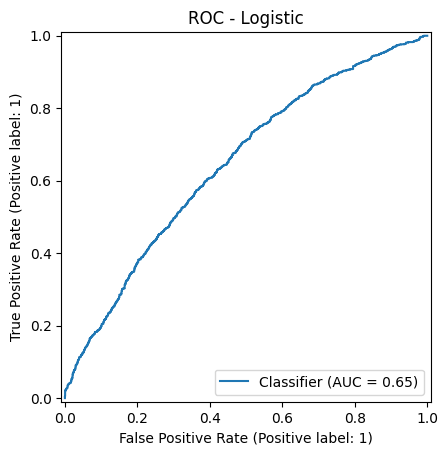


===== KNN =====
AUC: 0.615
              precision    recall  f1-score   support

           0       0.61      0.72      0.66      1656
           1       0.55      0.43      0.48      1316

    accuracy                           0.59      2972
   macro avg       0.58      0.57      0.57      2972
weighted avg       0.58      0.59      0.58      2972



<Figure size 640x480 with 0 Axes>

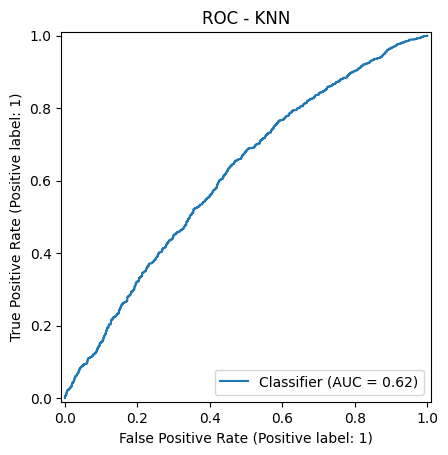


===== RandomForest =====
AUC: 0.653
              precision    recall  f1-score   support

           0       0.63      0.75      0.69      1656
           1       0.59      0.44      0.51      1316

    accuracy                           0.62      2972
   macro avg       0.61      0.60      0.60      2972
weighted avg       0.61      0.62      0.61      2972



<Figure size 640x480 with 0 Axes>

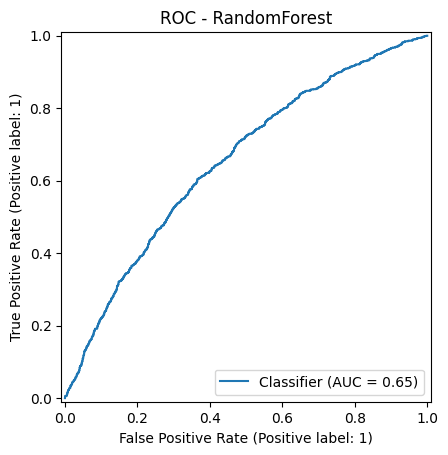


===== GradientBoosting =====
AUC: 0.653
              precision    recall  f1-score   support

           0       0.64      0.74      0.68      1656
           1       0.59      0.47      0.52      1316

    accuracy                           0.62      2972
   macro avg       0.61      0.60      0.60      2972
weighted avg       0.61      0.62      0.61      2972



<Figure size 640x480 with 0 Axes>

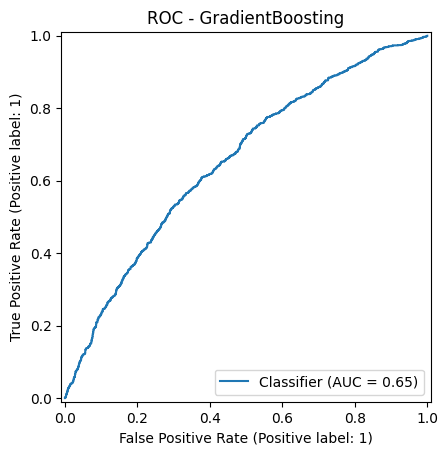

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay

for name, model in trained_models.items():

    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)

    print(f"\n===== {name} =====")
    print("AUC:", round(roc_auc_score(y_test, proba), 3))
    print(classification_report(y_test, pred))

    plt.figure()
    RocCurveDisplay.from_predictions(y_test, proba)
    plt.title(f"ROC - {name}")
    plt.show()


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier

best_model = Pipeline([
    ("prep", preprocess),
    ("clf", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)
print("✅ Best model trained: GradientBoosting")


✅ Best model trained: GradientBoosting


In [ ]:
import joblib
from google.colab import files
MODEL_PATH = "churn_model.pkl"
joblib.dump(best_model, MODEL_PATH)
# kiểm tra load lại ok
loaded_model = joblib.load(MODEL_PATH)
print("✅ Model loaded OK")
# tải về máy
files.download(MODEL_PATH)

✅ Model loaded OK


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#  Tổng quan hồ sơ khách hàng này
# Đây là khách có rủi ro churn khá cao:
# Mua 1 đơn trong 90 ngày
# Không mua 30 ngày gần nhất
# Engagement thấp
# Phụ thuộc khuyến mãi
# Model nhìn vào đây để dự đoán xác suất rời bỏ trong 90 ngày tới.
# 2️⃣ Hành vi mua hàng (RFM)
# orders_30d = 0
# 30 ngày gần nhất không mua
# Dấu hiệu giảm tương tác thương mại
# orders_90d = 1
# 90 ngày gần đây chỉ mua 1 lần
# Frequency thấp → churn risk ↑
# spend_30d = 0
# Không chi tiêu gần đây
# Củng cố tín hiệu churn
# spend_90d = 180000
# Tổng chi 90 ngày = 180.000đ
# Mức chi thấp (mỹ phẩm thường >300k)
# avg_order_value_90d = 180000
# AOV thấp
# Khách mua nhỏ lẻ, không gắn bó
# 📌 Ý nghĩa CRM:
# Khách low-value + không quay lại → win-back nhẹ, không voucher lớn.
# 3️⃣ Recency & xu hướng
# days_since_last_purchase = 78
# Lần mua cuối cách đây 78 ngày
# Gần chạm ngưỡng churn (90 ngày)
# orders_30d_vs_prev30d = -0.8
# Số đơn giảm 80% so với 30 ngày trước đó
# Dấu hiệu “rụng dần”
# spend_30d_vs_prev30d = -0.9
# Chi tiêu giảm 90%
# Rất mạnh → churn signal rõ
#  4️⃣ Hành vi trên funnel
# sessions_30d = 2
# Chỉ vào web/app 2 lần / tháng
# Engagement thấp
# product_views_30d = 8
# Xem ít sản phẩm
# Không khám phá thêm
# add_to_cart_30d = 1
# Có ý định mua (1 lần)
# checkout_start_30d = 0
# Không vào checkout
# Bỏ giỏ hàng
# cart_to_checkout_rate = 0.0
# 0% chuyển từ giỏ → checkout
# Do dự / chờ sale
# checkout_to_purchase_rate = 0.0
# Không có mua → hiển nhiên = 0
#  Ý nghĩa CRM:
# Khách còn xem → nên nhắc mua, không nên bỏ.
# 5️⃣ Marketing & khuyến mãi
# discount_dependency = 0.7
# Phụ thuộc sale khá cao
# Không mua nếu không giảm giá
# promotion_period_flag = 1
# Đang trong kỳ khuyến mãi
# Nhưng vẫn không mua
# coupon_used_90d = 1
# Đã dùng coupon trước đây
# Học hành vi “chờ coupon”
# email_open_rate_30d = 0.05
# Chỉ mở 5% email
# Gần như bỏ qua email marketing
# push_open_rate_30d = 0.02
# Gần như không đọc push
#  Ý nghĩa CRM:
# Email/push không hiệu quả → thử SMS / remarketing ads.
#  6️⃣ Trải nghiệm & rủi ro
# returns_90d = 0
# Không hoàn hàng
# refund_ratio_90d = 0.0
# Không có vấn đề về tiền
# complaints_90d = 0
# Không khiếu nại
# avg_rating_90d = 4.5
# Đánh giá khá tốt
# experience_risk_score = 0.1
# Rủi ro trải nghiệm thấp
# 📌 Quan trọng:
# Khách này KHÔNG churn vì trải nghiệm
# → churn vì giảm nhu cầu / không còn hứng thú
sample_cases = pd.DataFrame([
    {
        "orders_30d": 1,
        "orders_90d": 2,
        "spend_30d": 0,
        "spend_90d": 180000,
        "avg_order_value_90d": 180000,
        "sessions_30d": 2,
        "product_views_30d": 8,
        "add_to_cart_30d": 1,
        "checkout_start_30d": 0,
        "days_since_last_purchase": 78,
        "orders_30d_vs_prev30d": -0.8,
        "spend_30d_vs_prev30d": -0.9,
        "cart_to_checkout_rate": 0.0,
        "checkout_to_purchase_rate": 0.0,
        "discount_dependency": 0.7,
        "email_open_rate_30d": 0.05,
        "push_open_rate_30d": 0.02,
        "coupon_used_90d": 1,
        "returns_90d": 0,
        "refund_ratio_90d": 0.0,
        "complaints_90d": 0,
        "avg_rating_90d": 4.5,
        "engagement_score_30d": 1.2,
        "experience_risk_score": 0.1,
        "price_sensitivity_score": 0.8,
        "customer_tenure_days": 240,
        "promotion_period_flag": 1,
        "skin_type": "oily",
        "preferred_category": "skincare",
        "primary_purchase_channel": "online",
        "device_type": "mobile",
        "traffic_source": "facebook"
    }
])

# 1️⃣ Predict churn probability
churn_prob = loaded_model.predict_proba(sample_cases)[:, 1]
# 2️⃣ Define threshold (do business quyết)
THRESHOLD = 0.45   # ví dụ: ưu tiên bắt churn sớm
churn_label = (churn_prob >= THRESHOLD).astype(int)
# 3️⃣ Define risk group (khuyên dùng thay vì nhị phân)
import pandas as pd
risk_group = pd.cut(
    churn_prob,
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Healthy", "At-risk", "High-risk"]
)

# 4️⃣ Print kết quả rõ ràng
result = sample_cases.copy()
result["churn_probability"] = churn_prob
result["churn_label"] = churn_label
result["risk_group"] = risk_group

result[["churn_probability", "churn_label", "risk_group"]]


,churn_probability,churn_label,risk_group
0,0.898757,1,High-risk


In [ ]:
improved_case = pd.DataFrame([
    {
        # 🔄 Purchase behavior (cải thiện nhẹ)
        "orders_30d": 1,
        "orders_90d": 2,
        "spend_30d": 250000,
        "spend_90d": 430000,
        "avg_order_value_90d": 215000,

        # 🔄 Engagement tăng
        "sessions_30d": 6,
        "product_views_30d": 35,
        "add_to_cart_30d": 3,
        "checkout_start_30d": 1,

        # 🔄 Recency cải thiện mạnh
        "days_since_last_purchase": 18,

        # 🔄 Trend đảo chiều
        "orders_30d_vs_prev30d": 0.2,
        "spend_30d_vs_prev30d": 0.3,

        # 🔄 Funnel cải thiện
        "cart_to_checkout_rate": 0.33,
        "checkout_to_purchase_rate": 1.0,

        # 🔄 Marketing
        "discount_dependency": 0.5,
        "email_open_rate_30d": 0.25,
        "push_open_rate_30d": 0.18,
        "coupon_used_90d": 1,

        # 🟢 Experience vẫn tốt
        "returns_90d": 0,
        "refund_ratio_90d": 0.0,
        "complaints_90d": 0,
        "avg_rating_90d": 4.6,
        "experience_risk_score": 0.05,

        # 🔄 Engagement score tăng
        "engagement_score_30d": 6.5,

        # 🔒 Không đổi (structural)
        "price_sensitivity_score": 0.8,
        "customer_tenure_days": 240,
        "promotion_period_flag": 1,
        "skin_type": "oily",
        "preferred_category": "skincare",
        "primary_purchase_channel": "online",
        "device_type": "mobile",
        "traffic_source": "facebook"
    }
])
# 1️⃣ Predict churn probability
churn_prob = loaded_model.predict_proba(improved_case)[:, 1]
# 2️⃣ Define threshold (do business quyết)
THRESHOLD = 0.45   # ví dụ: ưu tiên bắt churn sớm
churn_label = (churn_prob >= THRESHOLD).astype(int)
# 3️⃣ Define risk group (khuyên dùng thay vì nhị phân)
import pandas as pd
risk_group = pd.cut(
    churn_prob,
    bins=[0, 0.4, 0.7, 1.0],
    labels=["Healthy", "At-risk", "High-risk"]
)

# 4️⃣ Print kết quả rõ ràng
result = sample_cases.copy()
result["churn_probability"] = churn_prob
result["churn_label"] = churn_label
result["risk_group"] = risk_group

result[["churn_probability", "churn_label", "risk_group"]]


,churn_probability,churn_label,risk_group
0,0.371756,0,Healthy


In [ ]:
import numpy, sklearn, joblib
print("OK ENV numpy:", numpy.__version__)
print("OK ENV sklearn:", sklearn.__version__)
print("OK ENV joblib:", joblib.__version__)


OK ENV numpy: 1.26.4
OK ENV sklearn: 1.6.1
OK ENV joblib: 1.4.2


In [ ]:
# Case gốc
original_prob = loaded_model.predict_proba(sample_cases)[:, 1]

# Case đã cải thiện
improved_prob = loaded_model.predict_proba(improved_case)[:, 1]

comparison = pd.DataFrame({
    "case": ["Original", "Improved"],
    "churn_probability": [original_prob[0], improved_prob[0]]
})

comparison

,case,churn_probability
0,Original,0.898757
1,Improved,0.371756


In [ ]:
# Lấy đúng schema cột từ X_train để test case không thiếu cột
schema_cols = X_train.columns.tolist()

def make_case(name, **kwargs):
    row = {c: np.nan for c in schema_cols}   # thiếu cột -> NaN (pipeline sẽ impute)
    row.update(kwargs)
    row["_case_name"] = name
    return row

test_cases = pd.DataFrame([
    # 1) Hard churn risk: gần như chắc chắn churn
    make_case(
        "Hard-risk: no orders, high recency, low engagement",
        orders_30d=0, orders_90d=0,
        spend_30d=0, spend_90d=0, avg_order_value_90d=0,
        sessions_30d=0, product_views_30d=1,
        add_to_cart_30d=0, checkout_start_30d=0,
        days_since_last_purchase=160,
        orders_30d_vs_prev30d=-1.0, spend_30d_vs_prev30d=-1.0,
        email_open_rate_30d=0.02, push_open_rate_30d=0.01,
        discount_dependency=0.8, coupon_used_90d=0,
        refund_ratio_90d=0.0, complaints_90d=0, avg_rating_90d=4.2,
        engagement_score_30d=0.1, experience_risk_score=0.0,
        price_sensitivity_score=0.9, customer_tenure_days=120,
        promotion_period_flag=1,
        skin_type="oily", preferred_category="skincare",
        primary_purchase_channel="online", device_type="mobile", traffic_source="facebook"
    ),

    # 2) At-risk: vẫn xem nhiều nhưng không checkout (do dự / chờ sale)
    make_case(
        "At-risk: browsing a lot, cart but no checkout (waiting promo)",
        orders_30d=0, orders_90d=1,
        spend_30d=0, spend_90d=220000, avg_order_value_90d=220000,
        sessions_30d=6, product_views_30d=55,
        add_to_cart_30d=7, checkout_start_30d=0,
        days_since_last_purchase=85,
        orders_30d_vs_prev30d=-0.6, spend_30d_vs_prev30d=-0.7,
        cart_to_checkout_rate=0.0, checkout_to_purchase_rate=0.0,
        email_open_rate_30d=0.08, push_open_rate_30d=0.05,
        discount_dependency=0.85, coupon_used_90d=1,
        refund_ratio_90d=0.0, complaints_90d=0, avg_rating_90d=4.6,
        engagement_score_30d=6.5, experience_risk_score=0.0,
        price_sensitivity_score=0.8, customer_tenure_days=480,
        promotion_period_flag=1,
        skin_type="combination", preferred_category="makeup",
        primary_purchase_channel="online", device_type="mobile", traffic_source="tiktok"
    ),

    # 3) Active healthy: mua đều, engagement tốt
    make_case(
        "Healthy: frequent buyer, high engagement",
        orders_30d=2, orders_90d=5,
        spend_30d=900000, spend_90d=2400000, avg_order_value_90d=480000,
        sessions_30d=16, product_views_30d=80,
        add_to_cart_30d=10, checkout_start_30d=6,
        days_since_last_purchase=12,
        orders_30d_vs_prev30d=0.2, spend_30d_vs_prev30d=0.1,
        cart_to_checkout_rate=0.6, checkout_to_purchase_rate=0.7,
        email_open_rate_30d=0.55, push_open_rate_30d=0.40,
        discount_dependency=0.25, coupon_used_90d=1,
        refund_ratio_90d=0.0, complaints_90d=0, avg_rating_90d=4.8,
        engagement_score_30d=18.0, experience_risk_score=0.0,
        price_sensitivity_score=0.2, customer_tenure_days=980,
        promotion_period_flag=0,
        skin_type="normal", preferred_category="skincare",
        primary_purchase_channel="store", device_type="desktop", traffic_source="organic"
    ),

    # 4) Experience-driven risk: hoàn/complaint cao → churn vì trải nghiệm
    make_case(
        "At-risk: bad experience (returns/complaints)",
        orders_30d=1, orders_90d=3,
        spend_30d=350000, spend_90d=1050000, avg_order_value_90d=350000,
        sessions_30d=8, product_views_30d=30,
        add_to_cart_30d=4, checkout_start_30d=2,
        days_since_last_purchase=40,
        orders_30d_vs_prev30d=-0.2, spend_30d_vs_prev30d=-0.25,
        email_open_rate_30d=0.20, push_open_rate_30d=0.12,
        discount_dependency=0.35, coupon_used_90d=0,
        returns_90d=1, refund_ratio_90d=0.33, complaints_90d=1, avg_rating_90d=2.7,
        engagement_score_30d=9.0, experience_risk_score=0.75,
        price_sensitivity_score=0.35, customer_tenure_days=620,
        promotion_period_flag=0,
        skin_type="sensitive", preferred_category="skincare",
        primary_purchase_channel="online", device_type="mobile", traffic_source="google_ads"
    ),

    # 5) New customer: tenure thấp, 1 đơn thử rồi im
    make_case(
        "New: one-time buyer, cooling off",
        orders_30d=0, orders_90d=1,
        spend_30d=0, spend_90d=280000, avg_order_value_90d=280000,
        sessions_30d=3, product_views_30d=14,
        add_to_cart_30d=1, checkout_start_30d=0,
        days_since_last_purchase=65,
        orders_30d_vs_prev30d=-0.5, spend_30d_vs_prev30d=-0.6,
        email_open_rate_30d=0.06, push_open_rate_30d=0.03,
        discount_dependency=0.6, coupon_used_90d=0,
        refund_ratio_90d=0.0, complaints_90d=0, avg_rating_90d=4.3,
        engagement_score_30d=4.0, experience_risk_score=0.0,
        price_sensitivity_score=0.7, customer_tenure_days=60,
        promotion_period_flag=1,
        skin_type="dry", preferred_category="bodycare",
        primary_purchase_channel="marketplace", device_type="mobile", traffic_source="facebook"
    ),

    # 6) Win-back candidate: lâu chưa mua nhưng engagement vẫn còn
    make_case(
        "Win-back: high recency but still engaged",
        orders_30d=0, orders_90d=1,
        spend_30d=0, spend_90d=450000, avg_order_value_90d=450000,
        sessions_30d=10, product_views_30d=60,
        add_to_cart_30d=5, checkout_start_30d=1,
        days_since_last_purchase=95,
        orders_30d_vs_prev30d=-0.7, spend_30d_vs_prev30d=-0.8,
        email_open_rate_30d=0.35, push_open_rate_30d=0.22,
        discount_dependency=0.5, coupon_used_90d=1,
        refund_ratio_90d=0.0, complaints_90d=0, avg_rating_90d=4.6,
        engagement_score_30d=12.0, experience_risk_score=0.0,
        price_sensitivity_score=0.55, customer_tenure_days=820,
        promotion_period_flag=1,
        skin_type="combination", preferred_category="fragrance",
        primary_purchase_channel="online", device_type="desktop", traffic_source="email"
    ),
])

# Dự đoán
case_names = test_cases["_case_name"].copy()
X_cases = test_cases.drop(columns=["_case_name"])

proba = loaded_model.predict_proba(X_cases)[:, 1]
pred = loaded_model.predict(X_cases)

result = pd.DataFrame({
    "case": case_names,
    "pred_label": pred,
    "pred_churn_prob": np.round(proba, 4)
}).sort_values("pred_churn_prob", ascending=False)

result


,case,pred_label,pred_churn_prob
0,"Hard-risk: no orders, high recency, low engage...",1,0.8584
1,"At-risk: browsing a lot, cart but no checkout ...",1,0.8431
4,"New: one-time buyer, cooling off",1,0.6788
5,Win-back: high recency but still engaged,1,0.5626
3,At-risk: bad experience (returns/complaints),0,0.4963
2,"Healthy: frequent buyer, high engagement",0,0.1972


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, MiniBatchKMeans, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [ ]:
df = pd.read_csv('customer_segmentation_clean_v3.csv')
df.head()
X = df.drop(columns=['customer_id'])


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/customer_segmentation_level3_cosmetics_v2.csv')
df.head()
# GIỮ LẠI FEATURE ĐÚNG
df_clean = df[[
    'customer_id',
    'Recency',
    'Frequency',
    'Monetary',
    'Discount_Sensitivity',
    'Category_Breadth'
]].copy()

# Scale lại cho chắc (optional)
scaler = MinMaxScaler()
cols = df_clean.columns.drop('customer_id')
df_clean[cols] = scaler.fit_transform(df_clean[cols])

df_clean.to_csv('customer_segmentation_clean_v3.csv', index=False)


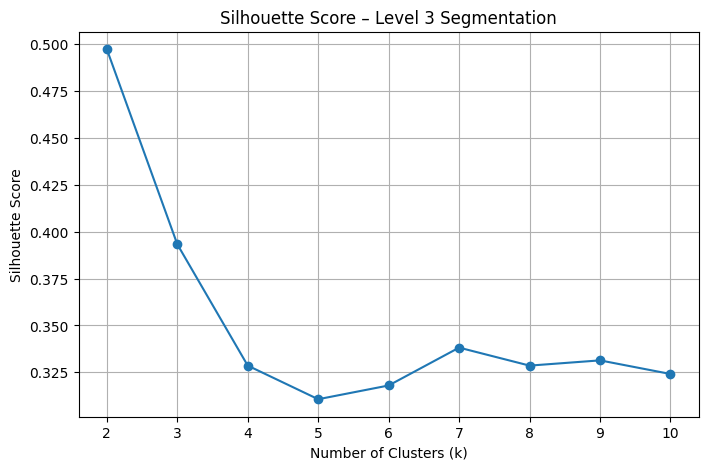

In [ ]:
scores = []
K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.figure(figsize=(8,5))
plt.plot(K, scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score – Level 3 Segmentation")
plt.grid(True)
plt.show()


In [ ]:
k_opt = 3

kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X)


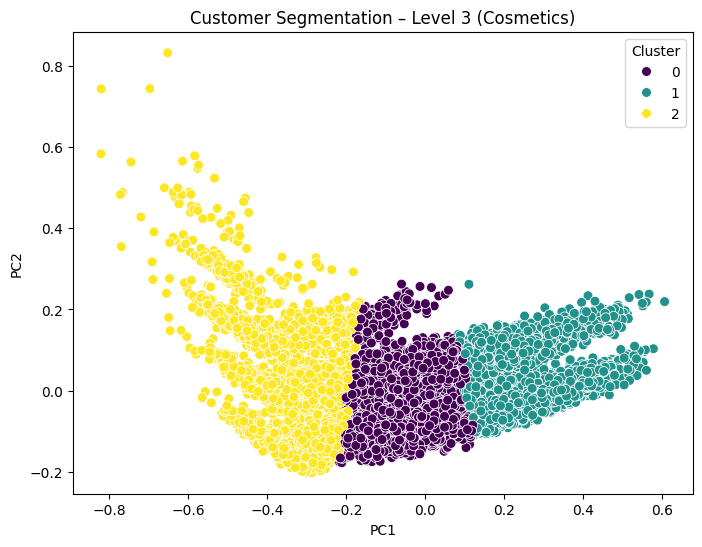

In [ ]:
pca = PCA(n_components=2)
components = pca.fit_transform(X)

df['PC1'] = components[:,0]
df['PC2'] = components[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x='PC1', y='PC2',
    hue='Cluster', palette='viridis', s=50
)
plt.title("Customer Segmentation – Level 3 (Cosmetics)")
plt.show()


In [ ]:
cluster_table = df.groupby('Cluster').agg(
    Number_of_Customers=('customer_id', 'count'),
    Recency=('Recency', 'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary=('Monetary', 'mean'),
).reset_index()

cluster_table


,Cluster,Number_of_Customers,Recency,Frequency,Monetary
0,0,5421,0.315750,0.078684,0.044412
1,1,5991,0.583466,0.012612,0.006989
2,2,3588,0.048099,0.229156,0.142637


In [ ]:
results = {
    "K-means": silhouette_score(
        X, KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit_predict(X)
    ),
    "MiniBatch K-means": silhouette_score(
        X, MiniBatchKMeans(n_clusters=k_opt, random_state=42).fit_predict(X)
    ),
    "Spectral Clustering": silhouette_score(
        X, SpectralClustering(n_clusters=k_opt, affinity='nearest_neighbors', random_state=42).fit_predict(X)
    )
}

pd.DataFrame.from_dict(results, orient='index', columns=['Silhouette Score'])


,Silhouette Score
K-means,0.393296
MiniBatch K-means,0.385078
Spectral Clustering,0.215613


In [ ]:
final_model = KMeans(
    n_clusters=k_opt,
    random_state=42,
    n_init=10
)

df['Cluster'] = final_model.fit_predict(X)


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Silhouette:", silhouette_score(X, df['Cluster']))
print("Davies-Bouldin:", davies_bouldin_score(X, df['Cluster']))
print("Calinski-Harabasz:", calinski_harabasz_score(X, df['Cluster']))


Silhouette: 0.3932955180075416
Davies-Bouldin: 0.876336005439052
Calinski-Harabasz: 18775.95727781268


In [ ]:
cluster_names = {
    0: "Inactive Customers",
    1: "High-Value Loyal Customers",
    2: "Price-Sensitive Explorers"
}

df['Segment'] = df['Cluster'].map(cluster_names)


In [ ]:
import joblib
joblib.dump(scaler, 'seg_preprocess.joblib')
joblib.dump(final_model, 'kmeans_customer_segmentation.joblib')
df.to_csv('customers_with_segments.csv', index=False)


In [ ]:
kmeans = joblib.load('/content/kmeans_customer_segmentation.joblib')
scaler = joblib.load('/content/seg_preprocess.joblib')

feature_cols = [
    'Recency',
    'Frequency',
    'Monetary',
    'Discount_Sensitivity',
    'Category_Breadth'
]


In [ ]:
train_df = pd.read_csv('/content/customer_segmentation_clean_v3.csv')  # đổi tên nếu bạn dùng file khác
feature_cols = [c for c in train_df.columns if c not in ['customer_id','Cluster','Segment','PC1','PC2']]
print("Feature columns:", feature_cols)


Feature columns: ['Recency', 'Frequency', 'Monetary', 'Discount_Sensitivity', 'Category_Breadth']


In [ ]:
def predict_cluster(kmeans, scaler, new_df, feature_cols):
    missing = set(feature_cols) - set(new_df.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    X_new = new_df[feature_cols].copy()

    # ép numeric cho chắc (tránh string)
    X_new = X_new.apply(pd.to_numeric, errors="coerce")

    # KMeans không nhận NaN
    if X_new.isna().any().any():
        bad_cols = X_new.columns[X_new.isna().any()].tolist()
        raise ValueError(f"Input contains NaN after to_numeric. Bad cols: {bad_cols}")

    # ✅ transform cùng scaler đã fit lúc train
    X_scaled = scaler.transform(X_new)

    labels = kmeans.predict(X_scaled)
    return labels


In [ ]:
case_high_value = pd.DataFrame([{
    "Recency": 10,
    "Frequency": 12,
    "Monetary": 8200000,
    "Discount_Sensitivity": 0.2,
    "Category_Breadth": 3
}])


label = predict_cluster(
    kmeans,
    scaler,
    case_high_value,
    feature_cols
)[0]

print("Predicted cluster:", label)

Predicted cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
case_inactive = pd.DataFrame([{
    'Recency': 0.95,
    'Frequency': 0.00,
    'Monetary': 0.00,
    'Discount_Sensitivity': 0.10,
    'Category_Breadth': 0.10
}])

label = predict_cluster(
    kmeans,
    scaler,
    case_high_value,
    feature_cols
)[0]
print("Predicted cluster:", label)


Predicted cluster: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [ ]:
case_price_sensitive = pd.DataFrame([{
    'Recency': 0.25,
    'Frequency': 0.30,
    'Monetary': 0.20,
    'Discount_Sensitivity': 0.90,
    'Category_Breadth': 0.85
}])

label = predict_cluster(model, case_price_sensitive, feature_cols)[0]
print("Predicted cluster:", label)


Predicted cluster: 2


In [ ]:
test_cases = pd.DataFrame([
    # inactive
    {'Recency':0.98,'Frequency':0.00,'Monetary':0.00,'Discount_Sensitivity':0.05,'Category_Breadth':0.05},
    # medium
    {'Recency':0.40,'Frequency':0.35,'Monetary':0.35,'Discount_Sensitivity':0.40,'Category_Breadth':0.50},
    # high value
    {'Recency':0.05,'Frequency':0.80,'Monetary':0.85,'Discount_Sensitivity':0.10,'Category_Breadth':0.25},
    # price sensitive explorer
    {'Recency':0.20,'Frequency':0.25,'Monetary':0.20,'Discount_Sensitivity':0.95,'Category_Breadth':0.90},
])

labels = predict_cluster(kmeans,scaler, case_price_sensitive, feature_cols)
test_cases['PredictedCluster'] = labels
test_cases


NameError: name 'case_price_sensitive' is not defined

In [ ]:
sample = train_df.sample(10, random_state=42).copy()
X_sample = sample[feature_cols]
pred = model.predict(X_sample)

out = sample[['customer_id']].copy()
out['PredictedCluster'] = pred
out.head(10)


,customer_id,PredictedCluster
11499,C00414,1
6475,C00314,0
13167,C03626,1
862,C00736,1
5970,C02119,0
6706,C01019,0
3017,C02900,2
3781,C00067,1
3898,C00156,1
2250,C02018,1


In [ ]:
cluster_labels = {
    0: "Inactive Customers",
    1: "High-Value Loyal Customers",
    2: "Price-Sensitive Explorers"
}

df['Segment'] = df['Cluster'].map(cluster_labels)
df[['customer_id','Cluster','Segment']].head(10)


,customer_id,Cluster,Segment
0,C01229,2,Price-Sensitive Explorers
1,C03921,2,Price-Sensitive Explorers
2,C01529,0,Inactive Customers
3,C00440,1,High-Value Loyal Customers
4,C00029,2,Price-Sensitive Explorers
5,C00597,1,High-Value Loyal Customers
6,C00028,1,High-Value Loyal Customers
7,C00798,1,High-Value Loyal Customers
8,C01424,0,Inactive Customers
9,C00680,1,High-Value Loyal Customers


orders: (100000, 5)
items : (240780, 9)


,order_id,customer_id,order_date,order_value,num_items
0,O0000001,C06479,2019-01-01,1035168.94,2
1,O0000002,C02331,2019-01-01,854575.59,4
2,O0000003,C03771,2019-01-01,846525.31,3
3,O0000004,C01296,2019-01-01,1196147.47,3
4,O0000005,C09468,2019-01-01,1058863.93,2


,order_id,customer_id,order_date,product_id,product_name,category,unit_price,quantity,line_value
0,O0000001,C06479,2019-01-01,hasaki_001383,Combo Cetaphil Sữa Tắm Gội & Sữa Chống Nắng SP...,Chống Nắng Da Mặt,598251.88,1,603037.89
1,O0000001,C06479,2019-01-01,hasaki_001644,[HSD 07/2026] Nước Tẩy Trang Evoluderm Cho Da ...,Tẩy Trang Mặt,428701.44,1,432131.05
2,O0000002,C02331,2019-01-01,hasaki_000193,Son Tint Joocyee Màu 740 Red Kerria 5.2g,Trang Điểm Môi,195158.90,1,196720.17
3,O0000002,C02331,2019-01-01,hasaki_001635,Nước Tẩy Trang Avander Chiết Xuất Từ Cám Gạo 1...,Chống Nắng Da Mặt,280770.24,1,283016.40
4,O0000002,C02331,2019-01-01,hasaki_001209,"Kem Chống Nắng La Roche-Posay Phổ Rộng, Nâng T...",Chống Nắng Da Mặt,280206.63,1,282448.29



== Missing rate (orders) ==
order_id       0.0
customer_id    0.0
order_date     0.0
order_value    0.0
num_items      0.0
dtype: float64

== Missing rate (items) ==
order_id        0.0
customer_id     0.0
order_date      0.0
product_id      0.0
product_name    0.0
category        0.0
unit_price      0.0
quantity        0.0
line_value      0.0
dtype: float64

Duplicate order_id in orders: 0
Duplicate (order_id, product_id) in items: 0

Date range: 2019-01-01 -> 2025-12-31
Order value describe:
 count    1.000000e+05
mean     1.055024e+06
std      7.785129e+05
min      3.859707e+04
25%      4.778521e+05
50%      8.684395e+05
75%      1.425638e+06
max      8.674148e+06
Name: order_value, dtype: float64

== Order value vs sum(line_value) ==
Mean abs diff: 2.913380740210414e-11
Max abs diff : 9.313225746154785e-10


,order_value,items_sum,diff
order_id,,,
O0000001,1035168.94,1035168.94,0.000000e+00
O0000002,854575.59,854575.59,-1.164153e-10
O0000003,846525.31,846525.31,1.164153e-10
O0000004,1196147.47,1196147.47,0.000000e+00
O0000005,1058863.93,1058863.93,0.000000e+00


Daily shape: (2557, 3)


,daily_revenue_order,daily_revenue_line,diff_order_minus_line
order_date,,,
2019-01-01,17255409.22,17255409.22,0.000000e+00
2019-01-02,12031428.36,12031428.36,0.000000e+00
2019-01-03,16368670.67,16368670.67,0.000000e+00
2019-01-04,15753964.33,15753964.33,0.000000e+00
2019-01-05,9337988.87,9337988.87,-1.862645e-09


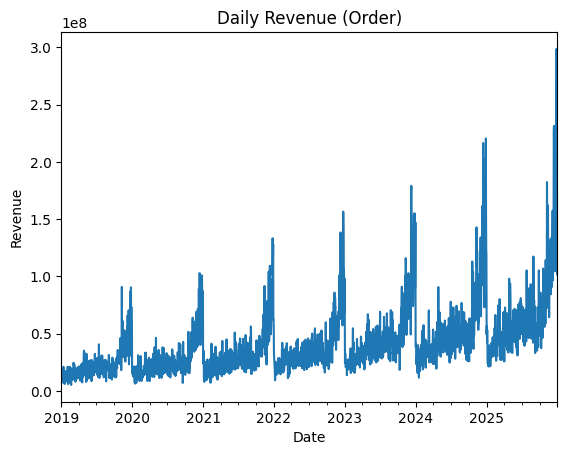

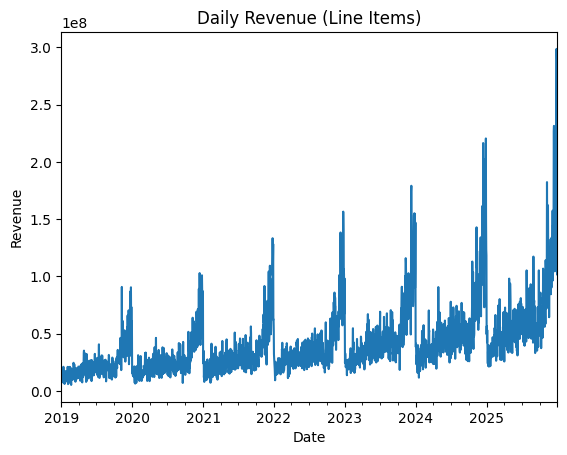

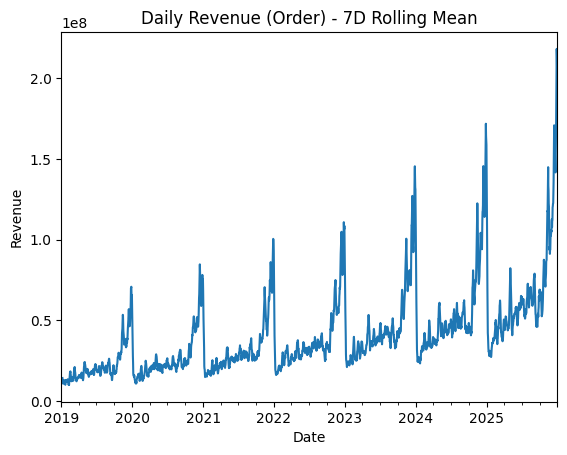

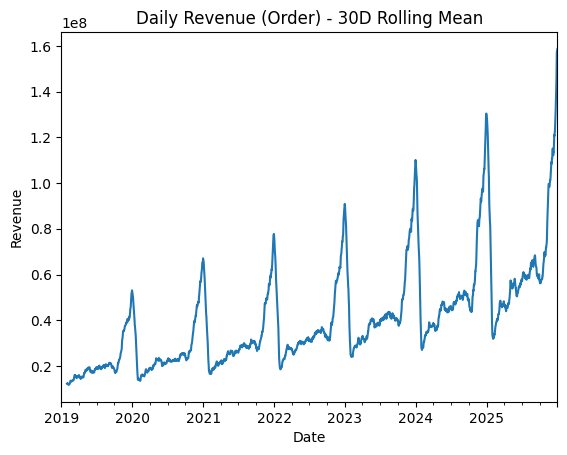

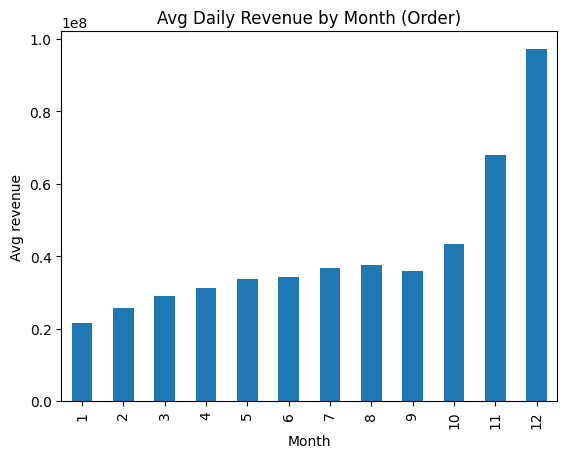

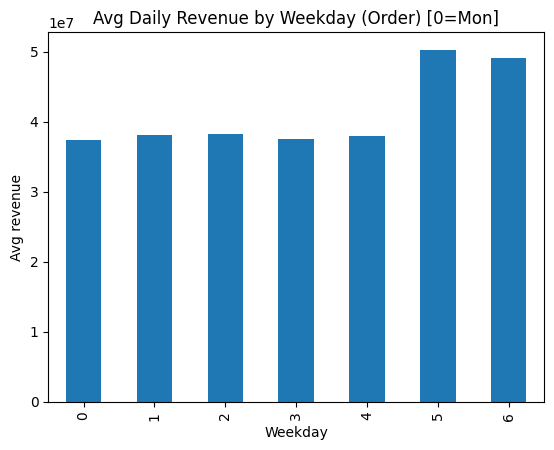

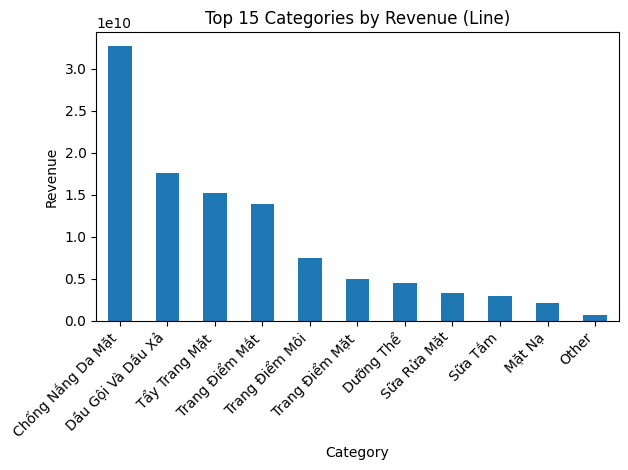

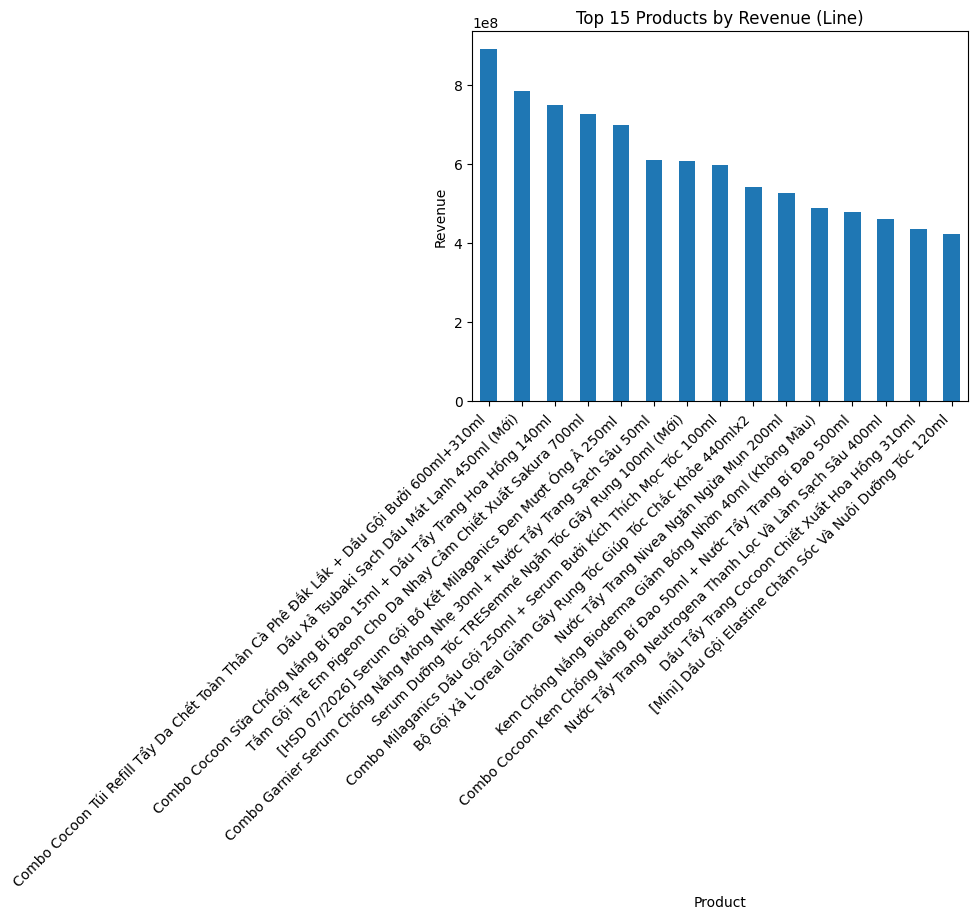

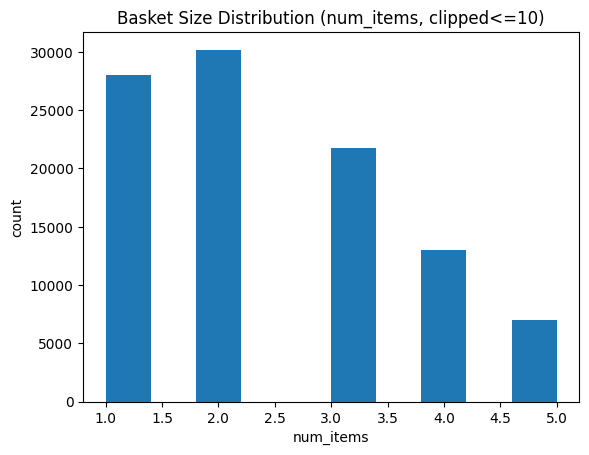

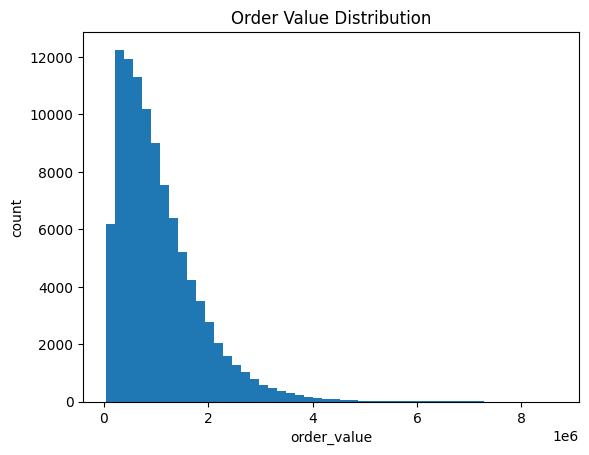

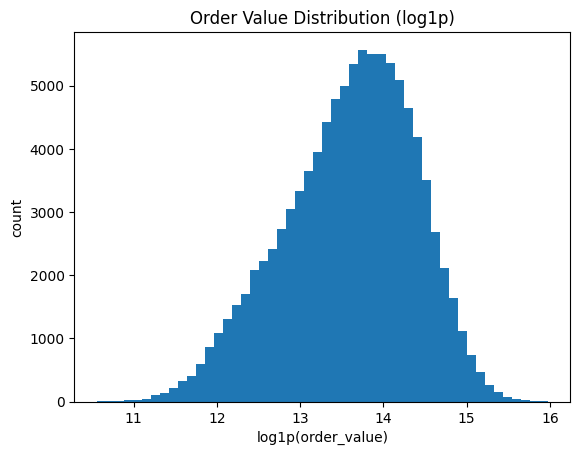

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) LOAD
# =========================
ORDERS_PATH = "/content/orders_2019_2025_dense_rebalanced.csv"
ITEMS_PATH  = "/content/order_items_2019_2025_dense_rebalanced.csv"

orders = pd.read_csv(ORDERS_PATH, encoding="utf-8-sig")
items = pd.read_csv(ITEMS_PATH, encoding="utf-8-sig")

# parse datetime + numeric
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders["order_value"] = pd.to_numeric(orders["order_value"], errors="coerce")
orders["num_items"] = pd.to_numeric(orders["num_items"], errors="coerce")

items["unit_price"] = pd.to_numeric(items["unit_price"], errors="coerce")
items["quantity"] = pd.to_numeric(items["quantity"], errors="coerce")
items["line_value"] = pd.to_numeric(items["line_value"], errors="coerce")

print("orders:", orders.shape)
print("items :", items.shape)
display(orders.head())
display(items.head())

# =========================
# 2) BASIC QUALITY CHECK
# =========================
print("\n== Missing rate (orders) ==")
print(orders.isna().mean().sort_values(ascending=False).head(10))

print("\n== Missing rate (items) ==")
print(items.isna().mean().sort_values(ascending=False).head(10))

# duplicates
print("\nDuplicate order_id in orders:", orders["order_id"].duplicated().sum())
print("Duplicate (order_id, product_id) in items:", items.duplicated(subset=["order_id","product_id"]).sum())

# range checks
print("\nDate range:", orders["order_date"].min().date(), "->", orders["order_date"].max().date())
print("Order value describe:\n", orders["order_value"].describe())

# =========================
# 3) JOIN CHECK (consistency)
# =========================
# (A) items sum by order should match orders.order_value (within rounding tolerance)
items_sum = items.groupby("order_id")["line_value"].sum()
check = orders.set_index("order_id")["order_value"].to_frame().join(items_sum.rename("items_sum"), how="left")

check["diff"] = check["order_value"] - check["items_sum"]
print("\n== Order value vs sum(line_value) ==")
print("Mean abs diff:", check["diff"].abs().mean())
print("Max abs diff :", check["diff"].abs().max())
display(check.head())

# =========================
# 4) CREATE DAILY TIME SERIES (FIX)
# =========================

# đảm bảo orders có order_date
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

# tạo mapping order_id -> order_date
order_date_map = orders.set_index("order_id")["order_date"]

# gán order_date vào items (không merge để tránh suffix)
items2 = items.copy()
items2["order_date"] = items2["order_id"].map(order_date_map)
items2["order_date"] = pd.to_datetime(items2["order_date"], errors="coerce")

daily_orders = (
    orders.dropna(subset=["order_date"])
          .set_index("order_date")
          .sort_index()
          .resample("D")["order_value"]
          .sum()
          .rename("daily_revenue_order")
)

daily_lines = (
    items2.dropna(subset=["order_date"])
          .set_index("order_date")
          .sort_index()
          .resample("D")["line_value"]
          .sum()
          .rename("daily_revenue_line")
)

daily = pd.concat([daily_orders, daily_lines], axis=1).fillna(0)
daily["diff_order_minus_line"] = daily["daily_revenue_order"] - daily["daily_revenue_line"]

print("Daily shape:", daily.shape)
display(daily.head())
# =========================
# 5) PLOTS: Daily revenue + rolling
# =========================
plt.figure()
daily["daily_revenue_order"].plot()
plt.title("Daily Revenue (Order)")
plt.xlabel("Date"); plt.ylabel("Revenue")
plt.show()

plt.figure()
daily["daily_revenue_line"].plot()
plt.title("Daily Revenue (Line Items)")
plt.xlabel("Date"); plt.ylabel("Revenue")
plt.show()

plt.figure()
daily["daily_revenue_order"].rolling(7).mean().plot()
plt.title("Daily Revenue (Order) - 7D Rolling Mean")
plt.xlabel("Date"); plt.ylabel("Revenue")
plt.show()

plt.figure()
daily["daily_revenue_order"].rolling(30).mean().plot()
plt.title("Daily Revenue (Order) - 30D Rolling Mean")
plt.xlabel("Date"); plt.ylabel("Revenue")
plt.show()

# =========================
# 6) SEASONALITY CHECKS
# =========================
tmp = daily.copy()
tmp["month"] = tmp.index.month
tmp["weekday"] = tmp.index.weekday

monthly = tmp.groupby("month")["daily_revenue_order"].mean()
weekday = tmp.groupby("weekday")["daily_revenue_order"].mean()

plt.figure()
monthly.plot(kind="bar")
plt.title("Avg Daily Revenue by Month (Order)")
plt.xlabel("Month"); plt.ylabel("Avg revenue")
plt.show()

plt.figure()
weekday.plot(kind="bar")
plt.title("Avg Daily Revenue by Weekday (Order) [0=Mon]")
plt.xlabel("Weekday"); plt.ylabel("Avg revenue")
plt.show()

# =========================
# 7) PRODUCT / CATEGORY EDA
# =========================
# Top categories by revenue
cat_rev = items.groupby("category")["line_value"].sum().sort_values(ascending=False).head(15)
plt.figure()
cat_rev.plot(kind="bar")
plt.title("Top 15 Categories by Revenue (Line)")
plt.xlabel("Category"); plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Top products by revenue
prod_rev = items.groupby("product_name")["line_value"].sum().sort_values(ascending=False).head(15)
plt.figure()
prod_rev.plot(kind="bar")
plt.title("Top 15 Products by Revenue (Line)")
plt.xlabel("Product"); plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Basket size distribution
plt.figure()
orders["num_items"].clip(upper=10).plot(kind="hist", bins=10)
plt.title("Basket Size Distribution (num_items, clipped<=10)")
plt.xlabel("num_items"); plt.ylabel("count")
plt.show()

# Order value distribution (log helps)
plt.figure()
orders["order_value"].plot(kind="hist", bins=50)
plt.title("Order Value Distribution")
plt.xlabel("order_value"); plt.ylabel("count")
plt.show()

plt.figure()
np.log1p(orders["order_value"]).plot(kind="hist", bins=50)
plt.title("Order Value Distribution (log1p)")
plt.xlabel("log1p(order_value)"); plt.ylabel("count")
plt.show()

In [ ]:
y = daily["daily_revenue_order"]
print("Zero days:", (y==0).mean())
print("Min non-zero:", y[y>0].min())


Zero days: 0.0
Min non-zero: 5134845.5


📊 EDA & FEATURE INSPECTION

🔹 BASIC INFO
Date range : 2019-01-01 -> 2025-12-31
Total days : 2557
Columns    : 3


,daily_revenue_order,daily_revenue_line,diff_order_minus_line
order_date,,,
2019-01-01,17255409.22,17255409.22,0.000000e+00
2019-01-02,12031428.36,12031428.36,0.000000e+00
2019-01-03,16368670.67,16368670.67,0.000000e+00
2019-01-04,15753964.33,15753964.33,0.000000e+00
2019-01-05,9337988.87,9337988.87,-1.862645e-09


,daily_revenue_order,daily_revenue_line,diff_order_minus_line
order_date,,,
2025-12-27,2.986655e+08,2.986655e+08,0.000000e+00
2025-12-28,2.882293e+08,2.882293e+08,5.960464e-08
2025-12-29,1.289184e+08,1.289184e+08,0.000000e+00
2025-12-30,1.014833e+08,1.014833e+08,0.000000e+00
2025-12-31,1.257778e+08,1.257778e+08,0.000000e+00



🔹 FEATURE LIST

Target variables (2):
 - daily_revenue_order
 - daily_revenue_line

Calendar (5):
 - weekday
 - month
 - year
 - is_weekend
 - is_holiday_window

Season dummies (0):

Lag / rolling (0):

👉 TOTAL FEATURES: 7

🔹 DATA QUALITY CHECK

Missing rate (top):


,0
daily_revenue_order,0.0
daily_revenue_line,0.0
diff_order_minus_line,0.0



Zero rate (top):


,0
diff_order_minus_line,0.92061
daily_revenue_order,0.00000
daily_revenue_line,0.00000



🔹 TARGET DISTRIBUTION


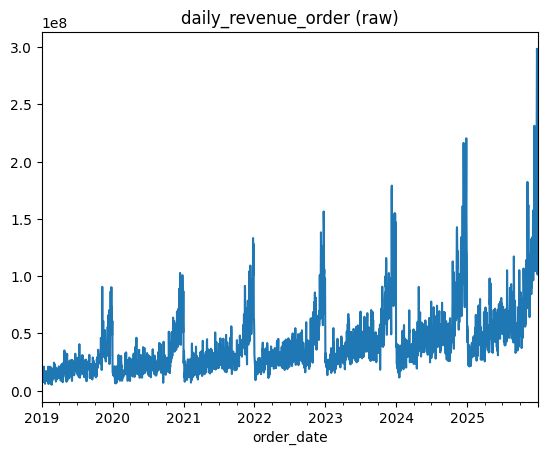

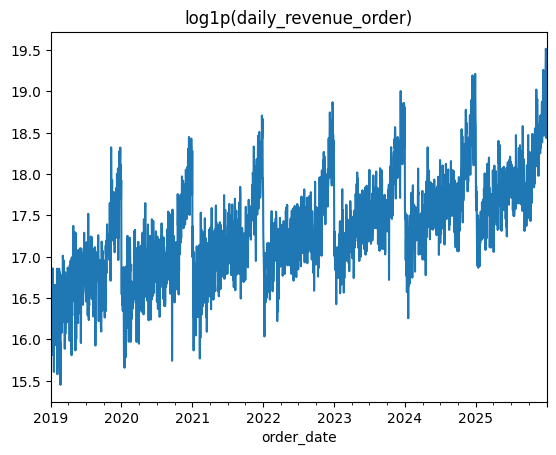

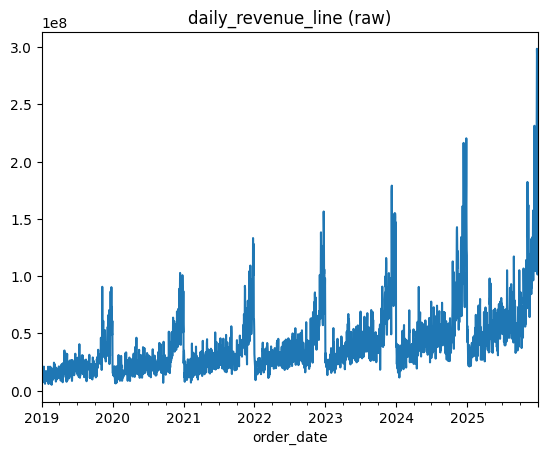

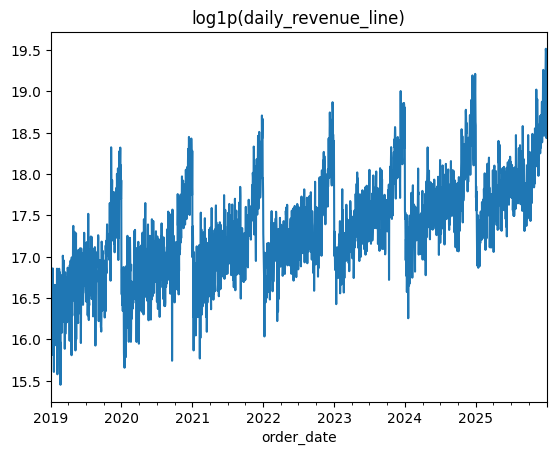


🔹 SEASONALITY


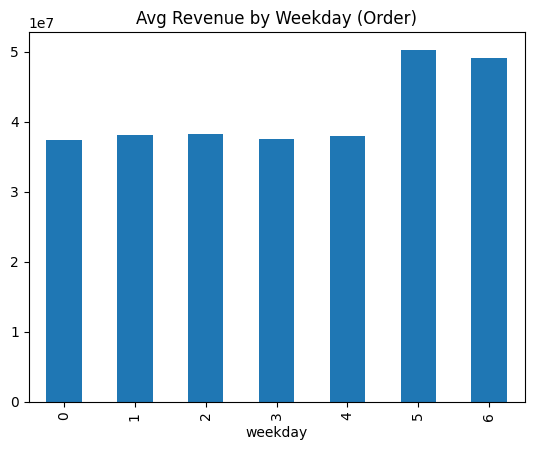

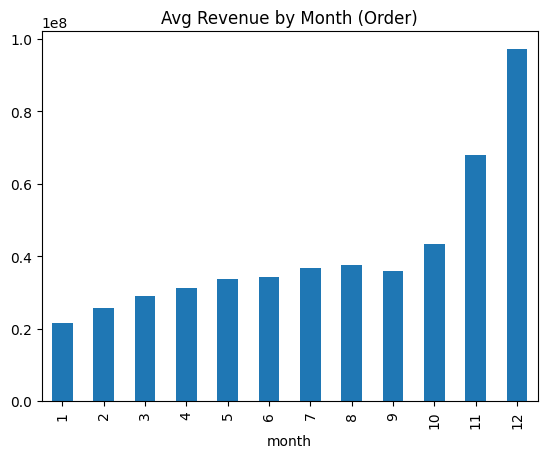


🔹 CORRELATION (Top with target)


,daily_revenue_order
daily_revenue_order,1.000000
daily_revenue_line,1.000000
diff_order_minus_line,0.036429



🔹 ROLLING STABILITY


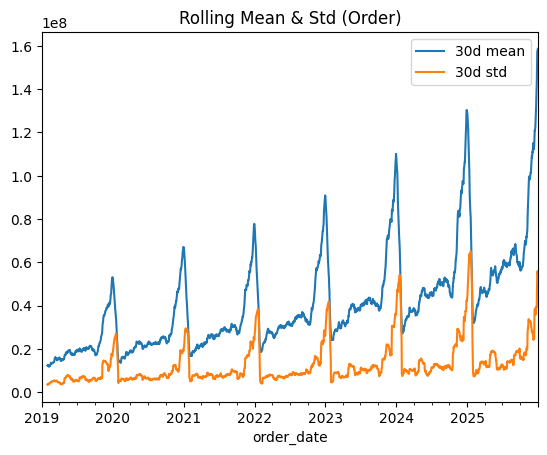


✅ EDA DONE — dataset is ready for training

🧹 PREPROCESSING
✅ Outliers clipped at [1%, 99%]
✅ Index OK (sorted & unique)
✅ Ready for TRAIN + EVAL
✅ daily: (2557, 11) 2019-01-01 -> 2025-12-31


,daily_revenue_order,daily_revenue_line,weekday,month,year,is_weekend,is_holiday_window,season_autumn,season_spring,season_summer,season_winter
date,,,,,,,,,,,
2019-01-01,17255409.22,17255409.22,1,1,2019,0,1,False,False,False,True
2019-01-02,12031428.36,12031428.36,2,1,2019,0,1,False,False,False,True
2019-01-03,16368670.67,16368670.67,3,1,2019,0,1,False,False,False,True
2019-01-04,15753964.33,15753964.33,4,1,2019,0,1,False,False,False,True
2019-01-05,9337988.87,9337988.87,5,1,2019,1,0,False,False,False,True



TARGET: daily_revenue_order
SARIMAX: {'rmse': 36911014.84771565, 'mae': 22973573.383071817, 'mape': 29.973884723196903}


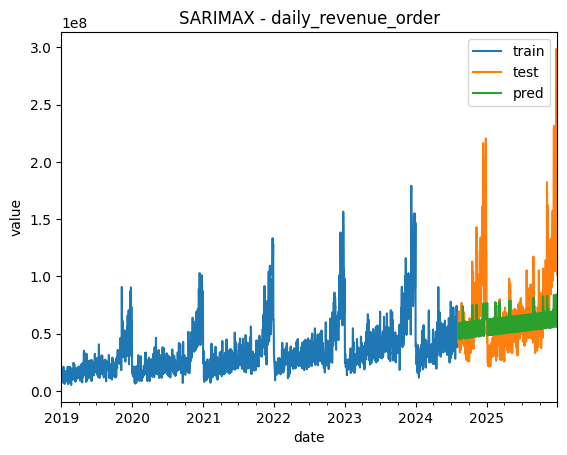

XGBoost: {'rmse': 23890466.76906099, 'mae': 14994078.594356434, 'mape': 19.443981434673006}


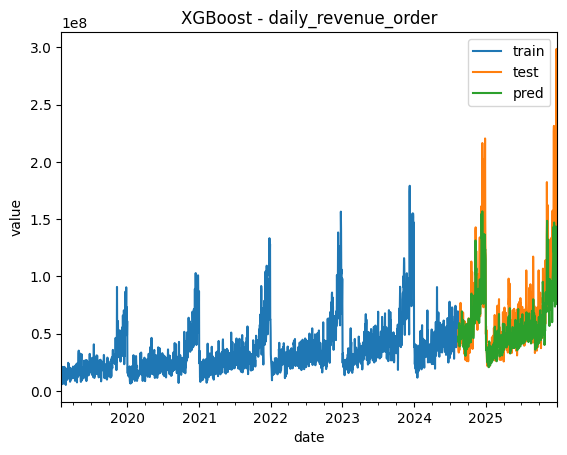

LSTM: {'rmse': 23154260.690731656, 'mae': 15358046.129510762, 'mape': 22.449632556597628}


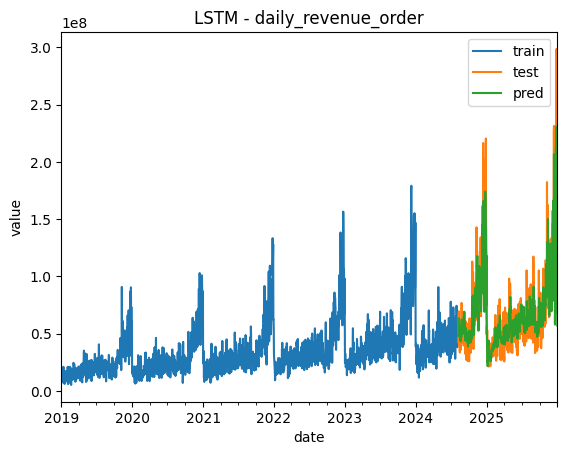


TARGET: daily_revenue_line
SARIMAX: {'rmse': 36911039.30335049, 'mae': 22973581.790059015, 'mape': 29.973866116893177}


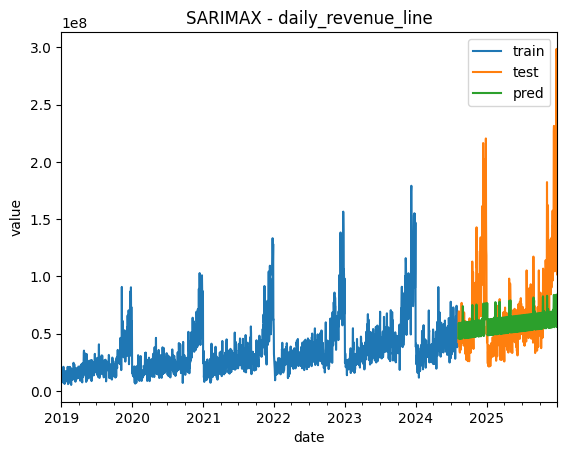

XGBoost: {'rmse': 23890466.76906099, 'mae': 14994078.594356434, 'mape': 19.443981434673006}


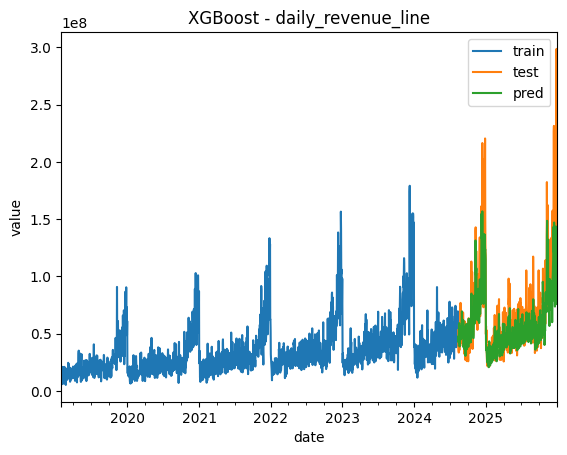

LSTM: {'rmse': 21487309.98349058, 'mae': 14846478.521878669, 'mape': 22.01707862911667}


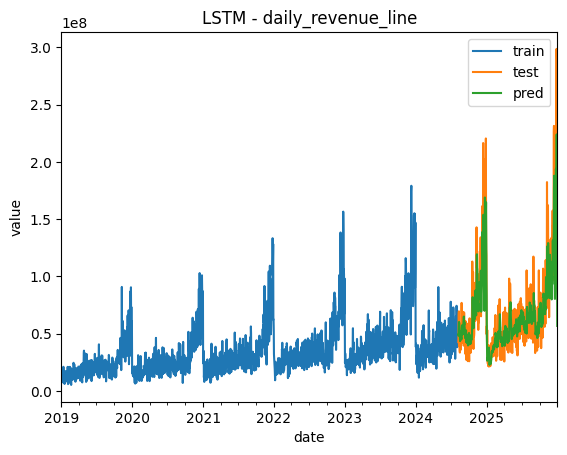


===== SUMMARY (sorted by RMSE) =====


,target,model,rmse,mae,mape
5,daily_revenue_line,LSTM,2.148731e+07,1.484648e+07,22.017079
4,daily_revenue_line,XGBoost,2.389047e+07,1.499408e+07,19.443981
3,daily_revenue_line,SARIMAX,3.691104e+07,2.297358e+07,29.973866
2,daily_revenue_order,LSTM,2.315426e+07,1.535805e+07,22.449633
1,daily_revenue_order,XGBoost,2.389047e+07,1.499408e+07,19.443981
0,daily_revenue_order,SARIMAX,3.691101e+07,2.297357e+07,29.973885



✅ Saved files:
 - model_outputs/model_metrics_summary.csv
 - model_outputs/daily_dataset_for_forecasting.csv
 - model_outputs/feature_config.joblib
 - sarimax_daily_revenue_order: model_outputs/sarimax_daily_revenue_order.pkl
 - xgb_daily_revenue_order: model_outputs/xgb_daily_revenue_order.joblib
 - lstm_daily_revenue_order: model_outputs/lstm_daily_revenue_order.keras
 - sarimax_daily_revenue_line: model_outputs/sarimax_daily_revenue_line.pkl
 - xgb_daily_revenue_line: model_outputs/xgb_daily_revenue_line.joblib
 - lstm_daily_revenue_line: model_outputs/lstm_daily_revenue_line.keras


In [ ]:
# ============================================================
# TRAIN + EVALUATE + SAVE MODELS (SARIMAX + XGBoost + LSTM)
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, callbacks

import joblib
import warnings
warnings.filterwarnings("ignore")

# =========================
# 0) CONFIG
# =========================
ORDERS_PATH = "/content/orders_2019_2025_dense_rebalanced.csv"
ITEMS_PATH  = "/content/order_items_2019_2025_dense_rebalanced.csv"

FREQ = "D"
TEST_RATIO = 0.2
LOOKBACK = 30
EXPORT_DIR = "model_outputs"
os.makedirs(EXPORT_DIR, exist_ok=True)

HOLIDAY_MMDD = [
    (1,1), (2,14), (3,8), (4,30), (5,1),
    (9,2), (10,20), (11,11), (12,12), (12,24), (12,25)
]
HOLIDAY_WINDOW_DAYS = 3

# =========================
# 1) METRICS + PLOT
# =========================
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.where(y_true == 0, np.nan, y_true)
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100)

def time_train_test_split(series: pd.Series, test_ratio=0.2):
    series = series.dropna()
    n = len(series)
    n_test = max(1, int(n * test_ratio))
    train = series.iloc[:-n_test]
    test  = series.iloc[-n_test:]
    return train, test

def plot_pred(y_train, y_test, y_pred, title):
    plt.figure()
    y_train.plot(label="train")
    y_test.plot(label="test")
    y_pred.plot(label="pred")
    plt.title(title)
    plt.xlabel("date"); plt.ylabel("value")
    plt.legend()
    plt.show()
# ============================================================
# EDA + FEATURE INSPECTION
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("===================================")
print("📊 EDA & FEATURE INSPECTION")
print("===================================")

# -------------------------
# 1) BASIC INFO
# -------------------------
print("\n🔹 BASIC INFO")
print("Date range :", daily.index.min().date(), "->", daily.index.max().date())
print("Total days :", len(daily))
print("Columns    :", len(daily.columns))

display(daily.head())
display(daily.tail())

# -------------------------
# 2) FEATURE LISTING
# -------------------------
print("\n🔹 FEATURE LIST")
feature_groups = {
    "Target variables": [c for c in daily.columns if c.startswith("daily_revenue")],
    "Calendar": ["weekday","month","year","is_weekend","is_holiday_window"],
    "Season dummies": [c for c in daily.columns if c.startswith("season_")],
    "Lag / rolling": [c for c in daily.columns if "lag_" in c or "roll_" in c]
}

for k,v in feature_groups.items():
    print(f"\n{k} ({len(v)}):")
    for c in v:
        print(" -", c)

print("\n👉 TOTAL FEATURES:", sum(len(v) for v in feature_groups.values()))

# -------------------------
# 3) MISSING / ZERO CHECK
# -------------------------
print("\n🔹 DATA QUALITY CHECK")

missing_rate = daily.isna().mean().sort_values(ascending=False)
print("\nMissing rate (top):")
display(missing_rate.head(10))

zero_rate = (daily == 0).mean().sort_values(ascending=False)
print("\nZero rate (top):")
display(zero_rate.head(10))

# -------------------------
# 4) TARGET DISTRIBUTION
# -------------------------
print("\n🔹 TARGET DISTRIBUTION")

for col in ["daily_revenue_order","daily_revenue_line"]:
    plt.figure()
    daily[col].plot(title=f"{col} (raw)")
    plt.show()

    plt.figure()
    np.log1p(daily[col]).plot(title=f"log1p({col})")
    plt.show()

# -------------------------
# 5) SEASONALITY CHECK
# -------------------------
print("\n🔹 SEASONALITY")

tmp = daily.copy()
tmp["weekday"] = tmp.index.weekday
tmp["month"] = tmp.index.month

plt.figure()
tmp.groupby("weekday")["daily_revenue_order"].mean().plot(kind="bar")
plt.title("Avg Revenue by Weekday (Order)")
plt.show()

plt.figure()
tmp.groupby("month")["daily_revenue_order"].mean().plot(kind="bar")
plt.title("Avg Revenue by Month (Order)")
plt.show()

# -------------------------
# 6) CORRELATION (NUMERIC ONLY)
# -------------------------
print("\n🔹 CORRELATION (Top with target)")

num_cols = daily.select_dtypes(include=np.number).columns
corr = daily[num_cols].corr()

display(
    corr["daily_revenue_order"]
    .sort_values(ascending=False)
    .head(15)
)

# -------------------------
# 7) STABILITY CHECK (ROLLING)
# -------------------------
print("\n🔹 ROLLING STABILITY")

plt.figure()
daily["daily_revenue_order"].rolling(30).mean().plot(label="30d mean")
daily["daily_revenue_order"].rolling(30).std().plot(label="30d std")
plt.legend()
plt.title("Rolling Mean & Std (Order)")
plt.show()

print("\n✅ EDA DONE — dataset is ready for training")
# ============================================================
# PREPROCESSING BEFORE TRAIN
# ============================================================

print("\n===================================")
print("🧹 PREPROCESSING")
print("===================================")

# 1) Ensure numeric
num_cols = daily.select_dtypes(include=np.number).columns
daily[num_cols] = daily[num_cols].astype(float)

# 2) Clip extreme outliers (robust, optional)
for col in ["daily_revenue_order","daily_revenue_line"]:
    q_low  = daily[col].quantile(0.01)
    q_high = daily[col].quantile(0.99)
    daily[col] = daily[col].clip(q_low, q_high)

print("✅ Outliers clipped at [1%, 99%]")

# 3) Final sanity check
assert daily.index.is_monotonic_increasing
assert daily.index.is_unique

print("✅ Index OK (sorted & unique)")
print("✅ Ready for TRAIN + EVAL")

# =========================
# 2) BUILD DAILY
# =========================
def season_from_month(m):
    if m in [12,1,2]: return "winter"
    if m in [3,4,5]:  return "spring"
    if m in [6,7,8]:  return "summer"
    return "autumn"

def build_holiday_flags(date_index: pd.DatetimeIndex):
    years = sorted(set(date_index.year.tolist()))
    holiday_dates = []
    for y in years:
        for mm, dd in HOLIDAY_MMDD:
            holiday_dates.append(pd.Timestamp(year=y, month=mm, day=dd))
    holiday_dates = pd.to_datetime(holiday_dates)

    flags = []
    for d in date_index:
        near = any(abs((d - h).days) <= HOLIDAY_WINDOW_DAYS for h in holiday_dates)
        flags.append(int(near))
    return pd.Series(flags, index=date_index, name="is_holiday_window")

def load_and_make_daily(freq="D"):
    orders = pd.read_csv(ORDERS_PATH)
    items  = pd.read_csv(ITEMS_PATH)

    orders["order_date"]  = pd.to_datetime(orders.get("order_date"), errors="coerce")
    orders["order_value"] = pd.to_numeric(orders.get("order_value"), errors="coerce")
    orders["num_items"]   = pd.to_numeric(orders.get("num_items"), errors="coerce")

    # ✅ safe: nếu thiếu unit_price/quantity thì không crash
    if "unit_price" in items.columns:
        items["unit_price"] = pd.to_numeric(items.get("unit_price"), errors="coerce")
    if "quantity" in items.columns:
        items["quantity"]   = pd.to_numeric(items.get("quantity"), errors="coerce")
    items["line_value"] = pd.to_numeric(items.get("line_value"), errors="coerce")

    orders = orders.dropna(subset=["order_id","order_date","order_value"]).copy()
    items  = items.dropna(subset=["order_id","line_value"]).copy()

    # ensure items has order_date (NO merge suffix bug)
    if "order_date" in items.columns:
        items["order_date"] = pd.to_datetime(items["order_date"], errors="coerce")
    else:
        order_date_map = orders.set_index("order_id")["order_date"]
        items["order_date"] = items["order_id"].map(order_date_map)
        items["order_date"] = pd.to_datetime(items["order_date"], errors="coerce")

    items = items.dropna(subset=["order_date"]).copy()

    daily_order = (orders.set_index("order_date")
                        .sort_index()
                        .resample(freq)["order_value"]
                        .sum()
                        .rename("daily_revenue_order"))

    daily_line  = (items.set_index("order_date")
                        .sort_index()
                        .resample(freq)["line_value"]
                        .sum()
                        .rename("daily_revenue_line"))

    idx = daily_order.index.union(daily_line.index).sort_values()
    full_idx = pd.date_range(idx.min(), idx.max(), freq=freq)

    daily = pd.concat([daily_order, daily_line], axis=1).reindex(full_idx).fillna(0)
    daily.index.name = "date"

    daily["weekday"] = daily.index.weekday
    daily["month"] = daily.index.month
    daily["year"] = daily.index.year
    daily["is_weekend"] = (daily["weekday"] >= 5).astype(int)
    daily["is_holiday_window"] = build_holiday_flags(daily.index)

    season = daily["month"].map(season_from_month)
    season_dum = pd.get_dummies(season, prefix="season")
    daily = pd.concat([daily, season_dum], axis=1)

    for c in ["season_spring","season_summer","season_autumn","season_winter"]:
        if c not in daily.columns:
            daily[c] = 0

    return daily

daily = load_and_make_daily(freq=FREQ)
print("✅ daily:", daily.shape, daily.index.min().date(), "->", daily.index.max().date())
display(daily.head())

# =========================
# 3) SARIMAX
# =========================
def fit_eval_sarimax(y: pd.Series, exog: pd.DataFrame, test_ratio=0.2,
                     order=(1,1,1), seasonal_order=(0,1,1,7)):
    y = y.astype(float)
    train_y, test_y = time_train_test_split(y, test_ratio)
    train_exog = exog.loc[train_y.index]
    test_exog  = exog.loc[test_y.index]

    model = SARIMAX(
        train_y, exog=train_exog,
        order=order, seasonal_order=seasonal_order,
        enforce_stationarity=False, enforce_invertibility=False
    )
    fit = model.fit(disp=False)
    pred = fit.forecast(steps=len(test_y), exog=test_exog)
    pred = pd.Series(pred.values, index=test_y.index)

    metrics = {
        "rmse": rmse(test_y, pred),
        "mae": float(mean_absolute_error(test_y, pred)),
        "mape": mape(test_y, pred),
    }
    return train_y, test_y, pred, metrics, fit

# =========================
# 4) XGBoost
# =========================
def make_supervised_features(df: pd.DataFrame, target_col: str):
    d = df.copy()
    for lag in [1, 7, 14]:
        d[f"lag_{lag}"] = d[target_col].shift(lag)
    for w in [7, 28]:
        d[f"roll_mean_{w}"] = d[target_col].shift(1).rolling(w).mean()
    return d.dropna().copy()

def fit_eval_xgb(df: pd.DataFrame, target_col: str, test_ratio=0.2):
    d = make_supervised_features(df, target_col)

    n = len(d)
    n_test = max(1, int(n * test_ratio))
    train_df = d.iloc[:-n_test].copy()
    test_df  = d.iloc[-n_test:].copy()

    feature_cols = [c for c in d.columns if c != target_col]
    X_train, y_train = train_df[feature_cols], train_df[target_col]
    X_test,  y_test  = test_df[feature_cols],  test_df[target_col]

    reg = XGBRegressor(
        n_estimators=800, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9, random_state=42
    )
    reg.fit(X_train, y_train)

    pred = pd.Series(reg.predict(X_test), index=test_df.index)

    metrics = {
        "rmse": rmse(y_test, pred),
        "mae": float(mean_absolute_error(y_test, pred)),
        "mape": mape(y_test, pred)
    }
    return train_df[target_col], test_df[target_col], pred, metrics, reg, feature_cols

# =========================
# 5) LSTM
# =========================
def make_lstm_xy(series_1d: np.ndarray, lookback=30):
    X, y = [], []
    for i in range(lookback, len(series_1d)):
        X.append(series_1d[i-lookback:i])
        y.append(series_1d[i])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y).reshape(-1, 1)
    return X, y

def fit_eval_lstm(y: pd.Series, test_ratio=0.2, lookback=30, epochs=60, batch_size=32):
    y = y.astype(float)
    train_y, test_y = time_train_test_split(y, test_ratio)

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_y.values.reshape(-1, 1)).flatten()

    full = pd.concat([train_y.tail(lookback), test_y])
    full_scaled = scaler.transform(full.values.reshape(-1, 1)).flatten()

    X_train, y_train = make_lstm_xy(train_scaled, lookback)
    X_test,  y_test  = make_lstm_xy(full_scaled, lookback)

    model = tf.keras.Sequential([
        layers.Input(shape=(lookback, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")

    es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(X_train, y_train, validation_split=0.2, epochs=epochs, batch_size=batch_size,
              callbacks=[es], verbose=0)

    pred_scaled = model.predict(X_test, verbose=0)
    pred = scaler.inverse_transform(pred_scaled).flatten()
    true = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    pred_index = full.index[lookback:]
    pred_s = pd.Series(pred, index=pred_index)
    true_s = pd.Series(true, index=pred_index)

    metrics = {
        "rmse": rmse(true_s, pred_s),
        "mae": float(mean_absolute_error(true_s, pred_s)),
        "mape": mape(true_s, pred_s)
    }
    return train_y, true_s, pred_s, metrics, model, scaler

# =========================
# 6) RUN + SAVE
# =========================
sarimax_exog_cols = ["is_holiday_window", "is_weekend"]
sarimax_exog = daily[sarimax_exog_cols].copy()

xgb_feature_cols_base = ["weekday","month","year","is_weekend","is_holiday_window"] + \
                        [c for c in daily.columns if c.startswith("season_")]
xgb_base = daily[xgb_feature_cols_base + ["daily_revenue_order","daily_revenue_line"]].copy()

results = []
saved_models = {}

for target in ["daily_revenue_order", "daily_revenue_line"]:
    print("\n==============================")
    print("TARGET:", target)
    print("==============================")

    y = daily[target]

    # ---- SARIMAX
    seasonal = (0,1,1,7) if FREQ == "D" else (0,1,1,1)
    tr, te, pred, met, sar_fit = fit_eval_sarimax(
        y=y, exog=sarimax_exog, test_ratio=TEST_RATIO,
        order=(1,1,1), seasonal_order=seasonal
    )
    print("SARIMAX:", met)
    plot_pred(tr, te, pred, f"SARIMAX - {target}")
    results.append({"target": target, "model": "SARIMAX", **met})

    sar_path = f"{EXPORT_DIR}/sarimax_{target}.pkl"
    sar_fit.save(sar_path)
    saved_models[f"sarimax_{target}"] = sar_path

    # ---- XGBoost
    df_for_xgb = xgb_base.drop(columns=[c for c in ["daily_revenue_order","daily_revenue_line"] if c != target]).copy()
    tr, te, pred, met, xgb_model, feature_cols = fit_eval_xgb(
        df=df_for_xgb, target_col=target, test_ratio=TEST_RATIO
    )
    print("XGBoost:", met)
    plot_pred(tr, te, pred, f"XGBoost - {target}")
    results.append({"target": target, "model": "XGBoost", **met})

    xgb_path = f"{EXPORT_DIR}/xgb_{target}.joblib"
    joblib.dump(xgb_model, xgb_path)
    saved_models[f"xgb_{target}"] = xgb_path

    # ---- LSTM
    lookback = LOOKBACK if FREQ == "D" else 12
    tr, te, pred, met, lstm_model, lstm_scaler = fit_eval_lstm(
        y=y, test_ratio=TEST_RATIO, lookback=lookback, epochs=60, batch_size=32
    )
    print("LSTM:", met)
    plot_pred(tr, te, pred, f"LSTM - {target}")
    results.append({"target": target, "model": "LSTM", **met})

    lstm_path = f"{EXPORT_DIR}/lstm_{target}.keras"
    lstm_model.save(lstm_path)
    joblib.dump(lstm_scaler, f"{EXPORT_DIR}/lstm_scaler_{target}.joblib")
    saved_models[f"lstm_{target}"] = lstm_path

# ---- summary + exports
summary = pd.DataFrame(results).sort_values(["target","rmse"])
print("\n===== SUMMARY (sorted by RMSE) =====")
display(summary)

summary.to_csv(f"{EXPORT_DIR}/model_metrics_summary.csv", index=False, encoding="utf-8-sig")
daily.reset_index().to_csv(f"{EXPORT_DIR}/daily_dataset_for_forecasting.csv", index=False, encoding="utf-8-sig")

# save feature config for forecasting XGB
joblib.dump(
    {
        "freq": FREQ,
        "holiday_mmdd": HOLIDAY_MMDD,
        "holiday_window_days": HOLIDAY_WINDOW_DAYS,
        "xgb_feature_cols_base": xgb_feature_cols_base
    },
    f"{EXPORT_DIR}/feature_config.joblib"
)

print("\n✅ Saved files:")
print(f" - {EXPORT_DIR}/model_metrics_summary.csv")
print(f" - {EXPORT_DIR}/daily_dataset_for_forecasting.csv")
print(f" - {EXPORT_DIR}/feature_config.joblib")
for k,v in saved_models.items():
    print(f" - {k}: {v}")


✅ Data range: 2019-01-01 -> 2025-12-31
✅ Start forecast: 2025-07-01 | horizon: 90


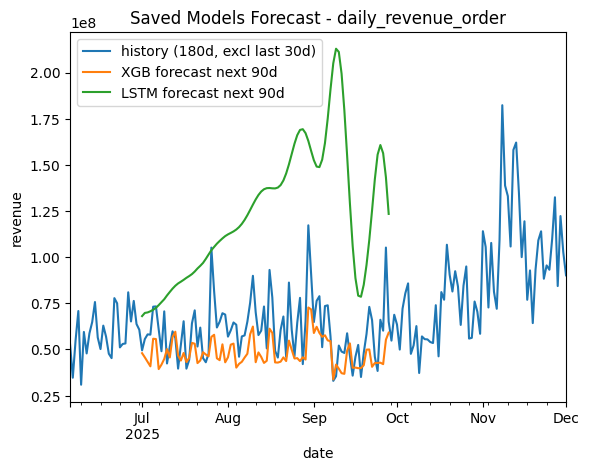

,daily_revenue_order_xgb_forecast,daily_revenue_order_lstm_forecast
2025-07-01,47980400.0,6.806583e+07
2025-07-02,45699456.0,6.978761e+07
2025-07-03,43281124.0,7.005418e+07
2025-07-04,40859028.0,7.068084e+07
2025-07-05,55802344.0,7.149881e+07
2025-07-06,55632164.0,7.251704e+07
2025-07-07,39370788.0,7.400983e+07
2025-07-08,41768588.0,7.561410e+07
2025-07-09,44868376.0,7.720154e+07
2025-07-10,50170216.0,7.925976e+07


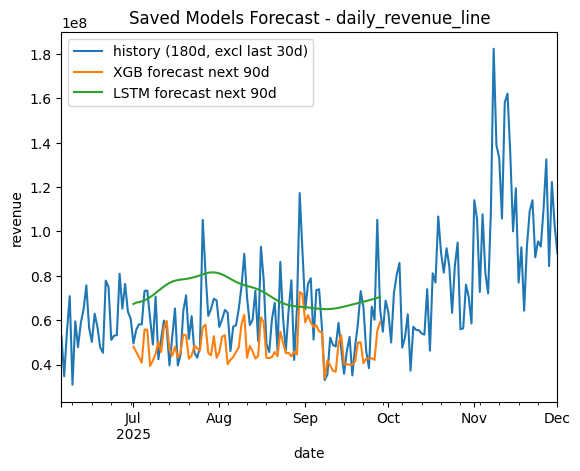

,daily_revenue_line_xgb_forecast,daily_revenue_line_lstm_forecast
2025-07-01,47980400.0,6.727517e+07
2025-07-02,45699456.0,6.791076e+07
2025-07-03,43281124.0,6.808384e+07
2025-07-04,40859028.0,6.846807e+07
2025-07-05,55802344.0,6.894823e+07
2025-07-06,55632164.0,6.959402e+07
2025-07-07,39370788.0,7.033636e+07
2025-07-08,41768588.0,7.123111e+07
2025-07-09,44868376.0,7.223474e+07
2025-07-10,50170216.0,7.320020e+07


In [ ]:
# ============================================================
# LOAD XGB + LSTM MODELS + FORECAST (NO RETRAIN)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

EXPORT_DIR = "model_outputs"

# --------- Forecast config (set cứng)
HORIZON_DAYS = 90
TARGETS = ["daily_revenue_order", "daily_revenue_line"]
START_FORECAST_DATE = pd.Timestamp("2025-07-01")
HISTORY_DAYS = 180
EXCLUDE_LAST_DAYS = 30

# --------- load daily dataset + feature config
daily_csv = f"{EXPORT_DIR}/daily_dataset_for_forecasting.csv"
cfg = joblib.load(f"{EXPORT_DIR}/feature_config.joblib")

daily = pd.read_csv(daily_csv)
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
daily = daily.dropna(subset=["date"]).set_index("date").sort_index()

HOLIDAY_MMDD = cfg["holiday_mmdd"]
HOLIDAY_WINDOW_DAYS = cfg["holiday_window_days"]

# -------------------------
# Helpers for XGB features
# -------------------------
def build_holiday_flags(date_index: pd.DatetimeIndex):
    years = sorted(set(date_index.year.tolist()))
    holiday_dates = []
    for y in years:
        for mm, dd in HOLIDAY_MMDD:
            holiday_dates.append(pd.Timestamp(year=y, month=mm, day=dd))
    holiday_dates = pd.to_datetime(holiday_dates)

    flags = []
    for d in date_index:
        flags.append(int(any(abs((d - h).days) <= HOLIDAY_WINDOW_DAYS for h in holiday_dates)))
    return pd.Series(flags, index=date_index, name="is_holiday_window")

def season_from_month(m):
    if m in [12,1,2]: return "winter"
    if m in [3,4,5]:  return "spring"
    if m in [6,7,8]:  return "summer"
    return "autumn"

def add_time_features(df, date_col="date"):
    d = df.copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d["weekday"] = d[date_col].dt.weekday
    d["month"] = d[date_col].dt.month
    d["year"] = d[date_col].dt.year
    d["is_weekend"] = (d["weekday"] >= 5).astype(int)

    season = d[date_col].dt.month.map(season_from_month)
    season_dum = pd.get_dummies(season, prefix="season")
    d = pd.concat([d, season_dum], axis=1)

    for c in ["season_spring","season_summer","season_autumn","season_winter"]:
        if c not in d.columns:
            d[c] = 0
    return d

FEATURE_COLS = [
    "weekday","month","year","is_weekend","is_holiday_window",
    "season_autumn","season_spring","season_summer","season_winter",
    "lag_1","lag_7","lag_14","roll_mean_7","roll_mean_28"
]

def make_feature_row(hist_series: pd.Series, future_date: pd.Timestamp):
    df = pd.DataFrame({"date": [future_date]})
    df = add_time_features(df, "date").set_index("date")
    df["is_holiday_window"] = build_holiday_flags(df.index).values

    df["lag_1"]  = hist_series.iloc[-1]
    df["lag_7"]  = hist_series.iloc[-7]  if len(hist_series) >= 7  else hist_series.iloc[0]
    df["lag_14"] = hist_series.iloc[-14] if len(hist_series) >= 14 else hist_series.iloc[0]

    df["roll_mean_7"]  = hist_series.iloc[-7:].mean()  if len(hist_series) >= 7  else hist_series.mean()
    df["roll_mean_28"] = hist_series.iloc[-28:].mean() if len(hist_series) >= 28 else hist_series.mean()

    return df[FEATURE_COLS]

# -------------------------
# XGB forecast (saved)
# -------------------------
def recursive_forecast_with_saved_xgb(daily_df: pd.DataFrame, target: str, start_date, horizon: int):
    model_path = f"{EXPORT_DIR}/xgb_{target}.joblib"
    model = joblib.load(model_path)

    start_date = pd.to_datetime(start_date)

    hist_df = daily_df[daily_df.index < start_date].copy()
    if len(hist_df) < 30:
        raise ValueError("History trước start_date quá ngắn (cần >= ~30 ngày).")

    hist = hist_df[target].astype(float).copy().sort_index()
    future_dates = pd.date_range(start_date, periods=horizon, freq="D")

    preds = []
    hist_ext = hist.copy()

    for d in future_dates:
        x = make_feature_row(hist_ext, d)
        yhat = float(model.predict(x)[0])
        preds.append(yhat)
        hist_ext.loc[d] = yhat

    return pd.Series(preds, index=future_dates, name=f"{target}_xgb_forecast")

# -------------------------
# LSTM forecast (saved)
# -------------------------
def recursive_forecast_with_saved_lstm(daily_df: pd.DataFrame, target: str, start_date, horizon: int, lookback: int = 30):
    model_path = f"{EXPORT_DIR}/lstm_{target}.keras"
    scaler_path = f"{EXPORT_DIR}/lstm_scaler_{target}.joblib"

    model = tf.keras.models.load_model(model_path)
    scaler = joblib.load(scaler_path)

    start_date = pd.to_datetime(start_date)

    hist_df = daily_df[daily_df.index < start_date].copy()
    if len(hist_df) < lookback + 1:
        raise ValueError(f"History trước start_date quá ngắn (cần >= {lookback+1} ngày).")

    hist = hist_df[target].astype(float).copy().sort_index()
    future_dates = pd.date_range(start_date, periods=horizon, freq="D")

    # scale history
    hist_scaled = scaler.transform(hist.values.reshape(-1, 1)).flatten().tolist()

    preds = []
    for _ in range(horizon):
        x_win = np.array(hist_scaled[-lookback:]).reshape(1, lookback, 1)
        yhat_scaled = float(model.predict(x_win, verbose=0)[0, 0])
        hist_scaled.append(yhat_scaled)

        yhat = float(scaler.inverse_transform([[yhat_scaled]])[0, 0])
        preds.append(yhat)

    return pd.Series(preds, index=future_dates, name=f"{target}_lstm_forecast")

# -------------------------
# RUN
# -------------------------
print("✅ Data range:", daily.index.min().date(), "->", daily.index.max().date())
print("✅ Start forecast:", START_FORECAST_DATE.date(), "| horizon:", HORIZON_DAYS)

for target in TARGETS:
    # forecasts
    fc_xgb  = recursive_forecast_with_saved_xgb(daily, target, START_FORECAST_DATE, HORIZON_DAYS)
    fc_lstm = recursive_forecast_with_saved_lstm(daily, target, START_FORECAST_DATE, HORIZON_DAYS, lookback=30)

    # plot history slice
    plt.figure()
    n = len(daily)
    end = max(0, n - EXCLUDE_LAST_DAYS)
    start = max(0, end - HISTORY_DAYS)
    hist_to_plot = daily[target].iloc[start:end]

    hist_to_plot.plot(label=f"history ({len(hist_to_plot)}d, excl last {EXCLUDE_LAST_DAYS}d)")
    fc_xgb.plot(label=f"XGB forecast next {HORIZON_DAYS}d")
    fc_lstm.plot(label=f"LSTM forecast next {HORIZON_DAYS}d")

    plt.title(f"Saved Models Forecast - {target}")
    plt.xlabel("date"); plt.ylabel("revenue")
    plt.legend()
    plt.show()

    display(pd.concat([fc_xgb.head(10), fc_lstm.head(10)], axis=1))


✅ Model expects: ['weekday', 'month', 'year', 'is_weekend', 'is_holiday_window', 'season_autumn', 'season_spring', 'season_summer', 'season_winter', 'lag_1', 'lag_7', 'lag_14', 'roll_mean_7', 'roll_mean_28']


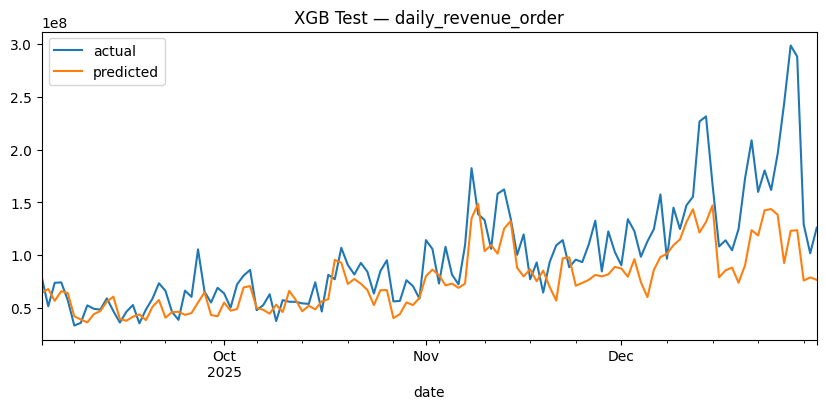

,prediction
date,
2019-01-29,10273956.0
2019-01-30,11339963.0
2019-01-31,12825778.0
2019-02-01,15117302.0
2019-02-02,14899403.0


In [ ]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

MODEL_DIR = "model_outputs"
TARGET = "daily_revenue_order"   # hoặc "daily_revenue_line"
DAILY_TEST_PATH = "/content/daily_dataset_enhanced_features.csv"
# --- load data
daily = pd.read_csv(DAILY_TEST_PATH)
daily["date"] = pd.to_datetime(daily["date"], errors="coerce")
daily = daily.dropna(subset=["date"]).sort_values("date").set_index("date")
daily.index.name = "date"
# --- load model
xgb_model = joblib.load(f"{MODEL_DIR}/xgb_{TARGET}.joblib")
# --- lấy đúng feature names mà model đã train
expected = xgb_model.get_booster().feature_names
print("✅ Model expects:", expected)
# --- tạo lag/roll ĐÚNG TÊN (lag_1, lag_7...) từ TARGET
df = daily.copy()
s = pd.to_numeric(df[TARGET], errors="coerce").astype(float)

df["lag_1"] = s.shift(1)
df["lag_7"] = s.shift(7)
df["lag_14"] = s.shift(14)
df["roll_mean_7"] = s.shift(1).rolling(7).mean()
df["roll_mean_28"] = s.shift(1).rolling(28).mean()

# --- đảm bảo đủ cột, thiếu thì tạo 0
for c in expected:
    if c not in df.columns:
        df[c] = 0

# --- chỉ lấy đúng các cột model cần, đúng thứ tự
test_df = df[expected + [TARGET]].dropna()
X_test = test_df[expected]
y_test = test_df[TARGET]

# --- predict
y_pred = xgb_model.predict(X_test)
pred = pd.Series(y_pred, index=X_test.index, name="prediction")

# --- plot 120 ngày cuối
plt.figure(figsize=(10,4))
y_test.tail(120).plot(label="actual")
pred.tail(120).plot(label="predicted")
plt.legend()
plt.title(f"XGB Test — {TARGET}")
plt.show()

display(pred.head())


In [ ]:
from google.colab import files

files.download("model_outputs/xgb_daily_revenue_order.joblib")
files.download("model_outputs/xgb_daily_revenue_line.joblib")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CELL 1: LOAD + BUILD DAILY DATASET (orders + items)
# ============================================================
import os
import numpy as np
import pandas as pd

ORDERS_PATH = "/content/orders_2019_2025_dense_rebalanced.csv"
ITEMS_PATH  = "/content/order_items_2019_2025_dense_rebalanced.csv"

FREQ = "D"
EXPORT_DIR = "model_outputs"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Holiday list (mm, dd) - bạn có thể chỉnh
HOLIDAY_MMDD = [
    (1,1), (2,14), (3,8), (4,30), (5,1),
    (9,2), (10,20), (11,11), (12,12), (12,24), (12,25)
]
HOLIDAY_WINDOW_DAYS = 3

def build_holiday_flags(date_index: pd.DatetimeIndex, holiday_mmdd, window_days: int):
    years = sorted(set(date_index.year.tolist()))
    holiday_dates = []
    for y in years:
        for mm, dd in holiday_mmdd:
            try:
                holiday_dates.append(pd.Timestamp(year=y, month=mm, day=dd))
            except Exception:
                pass
    holiday_dates = pd.to_datetime(holiday_dates)

    flags = []
    for d in date_index:
        near = any(abs((d - h).days) <= window_days for h in holiday_dates)
        flags.append(int(near))
    return pd.Series(flags, index=date_index, name="is_holiday_window")

def season_from_month(m):
    if m in [12,1,2]: return "winter"
    if m in [3,4,5]:  return "spring"
    if m in [6,7,8]:  return "summer"
    return "autumn"

def load_and_make_daily(freq="D"):
    orders = pd.read_csv(ORDERS_PATH, encoding="utf-8-sig")
    items  = pd.read_csv(ITEMS_PATH,  encoding="utf-8-sig")

    # parse
    orders["order_date"]  = pd.to_datetime(orders.get("order_date"), errors="coerce")
    orders["order_value"] = pd.to_numeric(orders.get("order_value"), errors="coerce")
    orders["num_items"]   = pd.to_numeric(orders.get("num_items"), errors="coerce")

    items["line_value"] = pd.to_numeric(items.get("line_value"), errors="coerce")
    if "quantity" in items.columns:
        items["quantity"] = pd.to_numeric(items.get("quantity"), errors="coerce")
    if "unit_price" in items.columns:
        items["unit_price"] = pd.to_numeric(items.get("unit_price"), errors="coerce")

    # clean
    orders = orders.dropna(subset=["order_id","order_date","order_value"]).copy()
    items  = items.dropna(subset=["order_id","line_value"]).copy()

    # ensure items has order_date (no suffix bug)
    if "order_date" in items.columns:
        items["order_date"] = pd.to_datetime(items["order_date"], errors="coerce")
    else:
        order_date_map = orders.set_index("order_id")["order_date"]
        items["order_date"] = items["order_id"].map(order_date_map)
        items["order_date"] = pd.to_datetime(items["order_date"], errors="coerce")
    items = items.dropna(subset=["order_date"]).copy()

    daily_order = (orders.set_index("order_date")
                        .sort_index()
                        .resample(freq)["order_value"]
                        .sum()
                        .rename("daily_revenue_order"))

    daily_line  = (items.set_index("order_date")
                        .sort_index()
                        .resample(freq)["line_value"]
                        .sum()
                        .rename("daily_revenue_line"))

    # full daily index
    idx = daily_order.index.union(daily_line.index).sort_values()
    full_idx = pd.date_range(idx.min(), idx.max(), freq=freq)

    daily = pd.concat([daily_order, daily_line], axis=1).reindex(full_idx).fillna(0)
    daily.index.name = "date"

    # calendar base
    daily["weekday"] = daily.index.weekday
    daily["month"] = daily.index.month
    daily["year"] = daily.index.year
    daily["is_weekend"] = (daily["weekday"] >= 5).astype(int)

    # holiday window
    daily["is_holiday_window"] = build_holiday_flags(daily.index, HOLIDAY_MMDD, HOLIDAY_WINDOW_DAYS).astype(int)

    # season one-hot
    season = daily["month"].map(season_from_month)
    season_dum = pd.get_dummies(season, prefix="season")
    daily = pd.concat([daily, season_dum], axis=1)

    for c in ["season_spring","season_summer","season_autumn","season_winter"]:
        if c not in daily.columns:
            daily[c] = 0
        daily[c] = daily[c].astype(int)

    return daily

daily = load_and_make_daily(freq=FREQ)
print("✅ daily:", daily.shape, daily.index.min().date(), "->", daily.index.max().date())
daily.head()


✅ daily: (2557, 11) 2019-01-01 -> 2025-12-31


,daily_revenue_order,daily_revenue_line,weekday,month,year,is_weekend,is_holiday_window,season_autumn,season_spring,season_summer,season_winter
date,,,,,,,,,,,
2019-01-01,17255409.22,17255409.22,1,1,2019,0,1,0,0,0,1
2019-01-02,12031428.36,12031428.36,2,1,2019,0,1,0,0,0,1
2019-01-03,16368670.67,16368670.67,3,1,2019,0,1,0,0,0,1
2019-01-04,15753964.33,15753964.33,4,1,2019,0,1,0,0,0,1
2019-01-05,9337988.87,9337988.87,5,1,2019,1,0,0,0,0,1


In [ ]:
# ============================================================
# CELL 2: FEATURE ENGINEERING + TRAIN XGB (log1p target)
# ============================================================
import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

TEST_RATIO = 0.2
SEED = 42

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true)) + 1e-9
    return float(np.sum(np.abs(y_true - y_pred)) / denom)

def time_split(df: pd.DataFrame, test_ratio=0.2):
    n = len(df)
    n_test = max(1, int(n * test_ratio))
    train = df.iloc[:-n_test].copy()
    test  = df.iloc[-n_test:].copy()
    return train, test

def add_cyclic_time_features(df: pd.DataFrame):
    d = df.copy()
    # weekday cycle
    d["dow_sin"] = np.sin(2 * np.pi * d["weekday"] / 7.0)
    d["dow_cos"] = np.cos(2 * np.pi * d["weekday"] / 7.0)
    # month cycle
    d["mon_sin"] = np.sin(2 * np.pi * d["month"] / 12.0)
    d["mon_cos"] = np.cos(2 * np.pi * d["month"] / 12.0)
    return d

def make_supervised_features(df: pd.DataFrame, target_col: str):
    d = df.copy()

    # Interaction features to capture spike
    d["weekend_x_holiday"] = (d["is_weekend"] * d["is_holiday_window"]).astype(int)

    # Cyclic encodings
    d = add_cyclic_time_features(d)

    # Lags
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        d[f"lag_{lag}"] = d[target_col].shift(lag)

    # Rolling means (shift(1) => only past)
    for w in [7, 14, 28]:
        d[f"roll_mean_{w}"] = d[target_col].shift(1).rolling(w).mean()
        d[f"roll_std_{w}"]  = d[target_col].shift(1).rolling(w).std()

    # Rolling median (robust vs outlier)
    for w in [7, 28]:
        d[f"roll_median_{w}"] = d[target_col].shift(1).rolling(w).median()

    # Growth / momentum features
    d["mom_7"]  = d[target_col].shift(1) - d[target_col].shift(8)
    d["mom_28"] = d[target_col].shift(1) - d[target_col].shift(29)

    # Optional: clip negatives from numeric features later if needed
    d = d.dropna().copy()
    return d

def train_xgb_for_target(daily: pd.DataFrame, target_col: str):
    df = daily.copy()
    df[target_col] = pd.to_numeric(df[target_col], errors="coerce").fillna(0.0).astype(float)

    # supervised table
    sup = make_supervised_features(df, target_col)

    # feature set
    feature_cols = [c for c in sup.columns if c != target_col]
    # ensure numeric
    sup[feature_cols] = sup[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    train_df, test_df = time_split(sup, TEST_RATIO)

    X_train = train_df[feature_cols]
    X_test  = test_df[feature_cols]

    # log1p target for stability
    y_train = np.log1p(train_df[target_col].values.astype(float))
    y_test_raw = test_df[target_col].values.astype(float)

    # XGB with early stopping
    model = XGBRegressor(
        n_estimators=4000,
        learning_rate=0.03,
        max_depth=6,
        min_child_weight=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=SEED,
        tree_method="hist"
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, np.log1p(y_test_raw))],
        verbose=False
    )

    # predict + inverse
    pred_log = model.predict(X_test)
    pred = np.expm1(pred_log)
    pred = np.maximum(pred, 0.0)

    metrics = {
        "target": target_col,
        "rmse": rmse(y_test_raw, pred),
        "mae": float(mean_absolute_error(y_test_raw, pred)),
        "wape": wape(y_test_raw, pred),
        "n_train": int(len(train_df)),
        "n_test": int(len(test_df)),
        "feature_count": int(len(feature_cols))
    }

    return model, feature_cols, metrics, test_df.index, y_test_raw, pred

# Train both targets
results = []
models = {}

for target in ["daily_revenue_order", "daily_revenue_line"]:
    print("\n==============================")
    print("TRAIN TARGET:", target)

    model, feature_cols, metrics, test_idx, y_true, y_pred = train_xgb_for_target(daily, target)
    results.append(metrics)

    # Save in the exact names your Streamlit expects
    out_name = "xgb_daily_revenue_order.joblib" if target == "daily_revenue_order" else "xgb_daily_revenue_line.joblib"
    joblib.dump(model, f"{EXPORT_DIR}/{out_name}")

    models[target] = {
        "model": model,
        "feature_cols": feature_cols,
        "test_idx": test_idx,
        "y_true": y_true,
        "y_pred": y_pred
    }

    print("METRICS:", metrics)

summary = pd.DataFrame(results).sort_values("rmse")
summary



TRAIN TARGET: daily_revenue_order
METRICS: {'target': 'daily_revenue_order', 'rmse': 21852052.132328518, 'mae': 14762899.569168318, 'wape': 0.21082223248815896, 'n_train': 2023, 'n_test': 505, 'feature_count': 32}

TRAIN TARGET: daily_revenue_line
METRICS: {'target': 'daily_revenue_line', 'rmse': 2.300018877576804e-06, 'mae': 2.300018877576804e-06, 'wape': 1161509.533176286, 'n_train': 2023, 'n_test': 505, 'feature_count': 32}


,target,rmse,mae,wape,n_train,n_test,feature_count
1,daily_revenue_line,2.300019e-06,2.300019e-06,1.161510e+06,2023,505,32
0,daily_revenue_order,2.185205e+07,1.476290e+07,2.108222e-01,2023,505,32


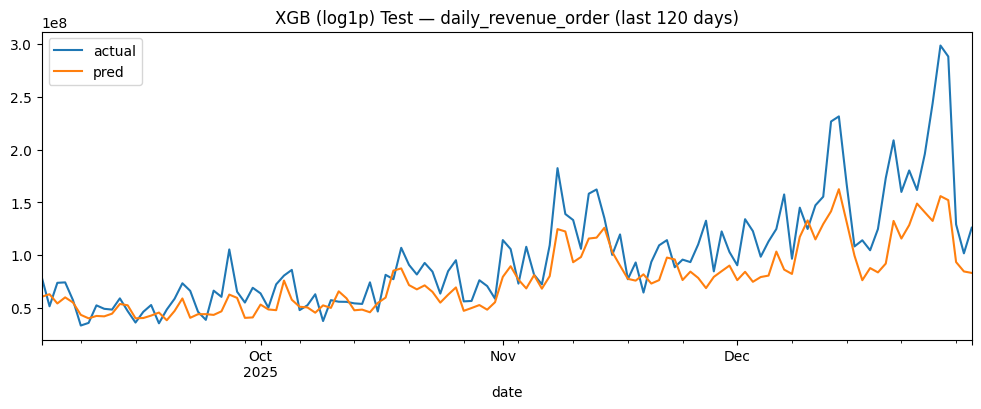

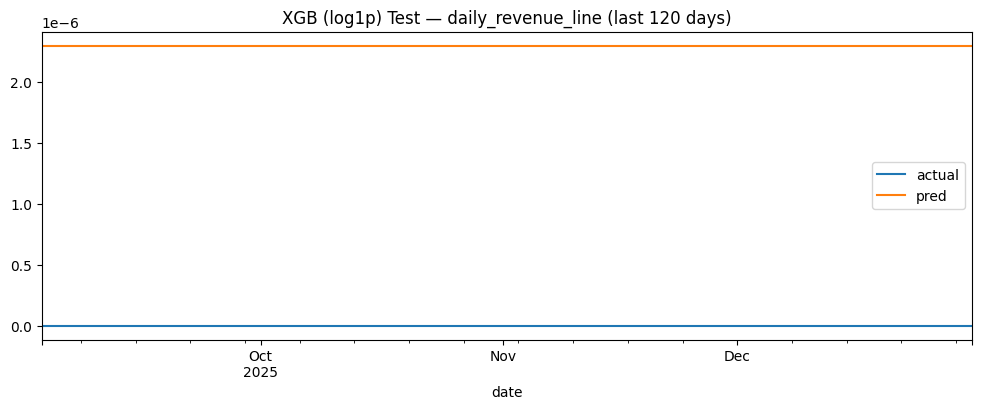

✅ Saved:
- model_outputs/xgb_daily_revenue_order.joblib
- model_outputs/xgb_daily_revenue_line.joblib
- model_outputs/daily_dataset_for_forecasting.csv
- model_outputs/feature_config.joblib


In [ ]:
# ============================================================
# CELL 3: PLOTS + EXPORT DAILY DATASET + FEATURE CONFIG
# ============================================================
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import numpy as np

# Plot last part of test for each target
for target in ["daily_revenue_order", "daily_revenue_line"]:
    pack = models[target]
    test_dates = pack["test_idx"]
    y_true = pd.Series(pack["y_true"], index=test_dates)
    y_pred = pd.Series(pack["y_pred"], index=test_dates)

    plt.figure(figsize=(12,4))
    y_true.tail(120).plot(label="actual")
    y_pred.tail(120).plot(label="pred")
    plt.title(f"XGB (log1p) Test — {target} (last 120 days)")
    plt.legend()
    plt.show()

# Export daily dataset for forecasting (reset index => date column)
daily_export = daily.reset_index()
daily_export.to_csv(f"{EXPORT_DIR}/daily_dataset_for_forecasting.csv", index=False, encoding="utf-8-sig")

# feature config (for inference / debugging)
feature_config = {
    "freq": FREQ,
    "holiday_mmdd": HOLIDAY_MMDD,
    "holiday_window_days": HOLIDAY_WINDOW_DAYS,
    "xgb_features_order": models["daily_revenue_order"]["feature_cols"],
    "xgb_features_line": models["daily_revenue_line"]["feature_cols"],
    "target_transform": "log1p -> expm1",
    "notes": [
        "Includes weekend_x_holiday interaction",
        "Includes cyclic time features (dow_sin/cos, mon_sin/cos)",
        "Includes multiple lags + rolling mean/std/median + momentum",
    ]
}
joblib.dump(feature_config, f"{EXPORT_DIR}/feature_config.joblib")

print("✅ Saved:")
print(f"- {EXPORT_DIR}/xgb_daily_revenue_order.joblib")
print(f"- {EXPORT_DIR}/xgb_daily_revenue_line.joblib")
print(f"- {EXPORT_DIR}/daily_dataset_for_forecasting.csv")
print(f"- {EXPORT_DIR}/feature_config.joblib")


In [ ]:
# ============================================================
# CELL 4: INFERENCE HELPERS (recursive forecast) - NO RETRAIN
# ============================================================
import numpy as np
import pandas as pd
import joblib

EXPORT_DIR = "model_outputs"

def _get_expected_features(model):
    try:
        booster = model.get_booster()
        if booster.feature_names:
            return list(booster.feature_names)
    except Exception:
        pass
    cols = getattr(model, "feature_names_in_", None)
    return list(cols) if cols is not None else None

def _season_onehot(month: int):
    return {
        "season_spring": int(month in (3,4,5)),
        "season_summer": int(month in (6,7,8)),
        "season_autumn": int(month in (9,10,11)),
        "season_winter": int(month in (12,1,2)),
    }

def _cyclic_feats(weekday: int, month: int):
    return {
        "dow_sin": float(np.sin(2*np.pi*weekday/7.0)),
        "dow_cos": float(np.cos(2*np.pi*weekday/7.0)),
        "mon_sin": float(np.sin(2*np.pi*month/12.0)),
        "mon_cos": float(np.cos(2*np.pi*month/12.0)),
    }

def _build_holiday_flag(d: pd.Timestamp, holiday_mmdd, window_days: int) -> int:
    year = d.year
    holiday_dates = []
    for mm, dd in holiday_mmdd:
        try:
            holiday_dates.append(pd.Timestamp(year=year, month=mm, day=dd))
        except Exception:
            pass
    for h in holiday_dates:
        if abs((d - h).days) <= window_days:
            return 1
    return 0

def make_feature_row(hist: pd.Series, future_date: pd.Timestamp, holiday_mmdd, holiday_window_days: int):
    # base calendar
    wd = int(future_date.dayofweek)
    mo = int(future_date.month)
    yr = int(future_date.year)
    is_weekend = int(wd >= 5)
    is_holiday_window = int(_build_holiday_flag(future_date, holiday_mmdd, holiday_window_days))
    weekend_x_holiday = int(is_weekend * is_holiday_window)

    row = {
        "weekday": wd,
        "month": mo,
        "year": yr,
        "is_weekend": is_weekend,
        "is_holiday_window": is_holiday_window,
        "weekend_x_holiday": weekend_x_holiday,
        **_season_onehot(mo),
        **_cyclic_feats(wd, mo),
    }

    # lags
    for lag in [1,2,3,7,14,21,28]:
        key = f"lag_{lag}"
        if len(hist) >= lag:
            row[key] = float(hist.iloc[-lag])
        else:
            row[key] = float(hist.iloc[0])

    # rolling mean/std/median (use past only)
    for w in [7,14,28]:
        s = hist.tail(w) if len(hist) >= w else hist
        row[f"roll_mean_{w}"] = float(s.mean())
        row[f"roll_std_{w}"]  = float(s.std(ddof=0))  # ddof=0 stable
    for w in [7,28]:
        s = hist.tail(w) if len(hist) >= w else hist
        row[f"roll_median_{w}"] = float(s.median())

    # momentum
    row["mom_7"]  = float(hist.iloc[-1] - (hist.iloc[-8] if len(hist) >= 8 else hist.iloc[0]))
    row["mom_28"] = float(hist.iloc[-1] - (hist.iloc[-29] if len(hist) >= 29 else hist.iloc[0]))

    return row

def forecast_recursive_xgb(
    daily_df: pd.DataFrame,
    model,
    target_col: str,
    horizon_days: int,
    start_date: pd.Timestamp | None,
    holiday_mmdd,
    holiday_window_days: int,
    hist_days: int = 365,
):
    df = daily_df.copy()
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).sort_values("date").set_index("date")
    else:
        df.index = pd.to_datetime(df.index)

    s = pd.to_numeric(df[target_col], errors="coerce").fillna(0.0).astype(float).sort_index()
    last_date = s.index.max()
    start_date = pd.to_datetime(start_date) if start_date is not None else (last_date + pd.Timedelta(days=1))

    hist = s[s.index < start_date].tail(hist_days).copy()
    if len(hist) < 35:
        raise ValueError("History quá ngắn. Cần >= 35 ngày để dùng lag/rolling ổn định.")

    expected = _get_expected_features(model)
    if not expected:
        raise ValueError("Không lấy được feature names từ model.")

    future_dates = pd.date_range(start_date, periods=horizon_days, freq="D")
    preds = []
    hist_ext = hist.copy()

    for d in future_dates:
        feat = make_feature_row(hist_ext, d, holiday_mmdd, holiday_window_days)
        X = pd.DataFrame([{c: feat.get(c, 0) for c in expected}], columns=expected)

        # model predicts log1p(target) => inverse expm1
        pred_log = float(model.predict(X)[0])
        pred = float(np.expm1(pred_log))
        pred = max(pred, 0.0)

        preds.append({"date": d, "prediction": pred, "prediction_log": pred_log})
        hist_ext.loc[d] = pred

    return pd.DataFrame(preds)

# Example run
cfg = joblib.load(f"{EXPORT_DIR}/feature_config.joblib")
daily_csv = pd.read_csv(f"{EXPORT_DIR}/daily_dataset_for_forecasting.csv")
daily_csv["date"] = pd.to_datetime(daily_csv["date"], errors="coerce")

m_order = joblib.load(f"{EXPORT_DIR}/xgb_daily_revenue_order.joblib")
out = forecast_recursive_xgb(
    daily_df=daily_csv,
    model=m_order,
    target_col="daily_revenue_order",
    horizon_days=30,
    start_date=None,
    holiday_mmdd=cfg["holiday_mmdd"],
    holiday_window_days=int(cfg["holiday_window_days"]),
    hist_days=365
)
out.head()


,date,prediction,prediction_log
0,2026-01-01,4.192758e+07,17.551455
1,2026-01-02,3.258467e+07,17.299353
2,2026-01-03,4.002712e+07,17.505068
3,2026-01-04,3.890543e+07,17.476645
4,2026-01-05,3.105452e+07,17.251255
